In [83]:
#!/usr/bin/env python

# Humans intro 

In [85]:
import numpy as np 
import pandas as pd
import random 
import os
from typing import Tuple, List
import time

# https://discuss.pytorch.org/t/how-to-enable-torch-use-cuda-dsa/202824/5
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"
# https://discuss.pytorch.org/t/keep-getting-cuda-oom-error-with-pytorch-failing-to-allocate-all-free-memory/133896/10
# https://dev.to/shittu_olumide_/how-can-i-set-maxsplitsizemb-to-avoid-fragmentation-in-pytorch-37h9
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64 "

from tqdm import tqdm
import torch
import copy
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, validation_curve, learning_curve, GridSearchCV, ShuffleSplit, StratifiedKFold 
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
import torch_geometric
from torch_geometric.data import Data, HeteroData
from torch_geometric.loader import NeighborLoader, ImbalancedSampler
import torch_geometric.transforms as T
import torch_geometric.utils as U
from torch_geometric.utils import coalesce
from torch_geometric.nn import summary, HeteroConv, GATv2Conv, SAGEConv, Linear
import pyg_lib

from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, f1_score, auc, precision_recall_fscore_support, matthews_corrcoef 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import tempfile
# edit the line below to specify specify tmp_directory
# tempfile.tempdir = ''

torch.multiprocessing.set_sharing_strategy('file_system')
# https://stackoverflow.com/questions/71642653/how-to-resolve-the-error-runtimeerror-received-0-items-of-ancdata
import resource
rlimit = resource.getrlimit(resource.RLIMIT_NOFILE)
resource.setrlimit(resource.RLIMIT_NOFILE, (4096, rlimit[1]))

print(f"numpy.__version__ = {np.__version__}")
print(f"pandas.__version__ = {pd.__version__}")
print(f"torch.__version__ = {torch.__version__}")
print(f"torch_geometric.__version__ = {torch_geometric.__version__}")
print(f"pyg_lib.__version__ = {pyg_lib.__version__}")

### hyperparameters

In [86]:
hyperparameters = {
    'node_mode' : 'degree', #'id' or 'degree' for abcm nodes_types
    'edge_features' : False, # True = those are the true edge_weights from my network
    'Heads' : 1, #2
    # 'conv_number' : 2, 
    # 'conv_type': 'SAGE',
    'sage_aggr': 'sum', # 'sum', 'var'
    'sage_norm': True, # False
    'sage_project': False,
    'heteroconv_aggr' : 'sum', # 'cat', 'max'
    'heteroconv_aggr_1' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_2' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_3' : 'sum', # 'cat', 'max'
    # 'activation': 'relu', # 'tanh'
    'hc_2_q' : 1, # hc_2 = int(i/hc_2_q)
    'hc_3_q': 1, # hc_3_q = int(i/hc_3_q)
    # 'size_of_batch': 128,
    'neighbors': 30,
    'disjoint_loader' : True, 
    'zero_out_batch_features': True,
    'epochs_to_train' : 500, # maximum number of epochs to train 
    'min_epochs_to_train': 3,
    'patience': 10,
    'min_delta': 0.005,
    'auto_loop': False,
    # 'nodes_pairs_features': 'zeros', # for p2p or n2p only
    # 'remove_forbidden_value': True, # for p2p or n2p only
    # 'ana_edges': 'common', # 'all
    'type_to_return': 'torch', # 'numpy'
    'final_type': 'torch', # 'numpy'
    'shuffle_train': True,
    'string_threshold': 700, # confidence = {'low': 150, 'medium': 400, 'high': 700, 'highest': 900} from STRING doc
    'setting': 'nodes_to_nodes',
    'target_to_use': 'essential',
    'features_to_use': 'basic' # features in ['basic', 'strict', 'large']
}

dict_j = {1:'01', 2:'02', 3:'03', 4:'04', 5:'05', 6:'06', 7:'07', 8:'08', 9:'09', 10:'10'}

In [87]:
sage_aggr = hyperparameters['sage_aggr'] # 'sum'
sage_norm = hyperparameters['sage_norm'] # 'sum'
heteroconv_aggr = hyperparameters['heteroconv_aggr'] #'sum', 'cat'
heteroconv_aggr_1 = hyperparameters['heteroconv_aggr_1'] #'sum', 'cat'
heteroconv_aggr_2 = hyperparameters['heteroconv_aggr_2'] #'sum', 'cat'
heteroconv_aggr_3 = hyperparameters['heteroconv_aggr_3'] #'sum', 'cat'
node_mode = hyperparameters['node_mode'] # 'id' or 'degree'
sage_norm = hyperparameters['sage_norm']
Heads = hyperparameters['Heads']
# ana_edges = hyperparameters['ana_edges']
# conv_number = hyperparameters['conv_number']
string_threshold = hyperparameters['string_threshold']

setting = hyperparameters['setting']
conv_type = hyperparameters['conv_type']
heads = hyperparameters['Heads']
neighbors = hyperparameters['neighbors']
patience = hyperparameters['patience']
min_delta = hyperparameters['min_delta']
zero_out_batch_features = hyperparameters['zero_out_batch_features']
epochs_to_train = hyperparameters['epochs_to_train']
size_of_batch = hyperparameters['size_of_batch']
target_of_script = hyperparameters['target_to_use']
features = 'basic' # 4 features, data['GENE'].x.shape will be (19330,4)

In [ ]:
old_path = os.getcwd()
new_path = old_path + '/../../'
os.chdir(new_path)
current_path = os.getcwd()
data_raw_path = current_path + '/data/raw/'
data_processed_path = current_path + '/data/processed/'
result_path = current_path + f'/results/humans/baseline/'

### beginning 

In [89]:
# open the Human_Knowledge_Graph
net = pd.read_csv(data_processed_path + f'human_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)
# I will not be using these edges,maybe in a future version ? 
edges_to_remove = [
    'CoExp', 'Neighbour', 
    'not_expressed_in', 'DIDA',
    'synthetic_lethal', 'synthetic_non_lethal', 
    'regulatory_proximal', 'regulatory_distal'
    ]
net = net.drop(net[net['EdgeType'].isin(edges_to_remove)].index, axis=0)
net = net.reset_index(drop=True)

all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
# I could hardcode edges_names, edge_summary eveneutally
edges_names = net['EdgeType'].value_counts().to_dict()
edges_summary = []
for edge_name in edges_names.keys():
    tmp_list = [edge_name, 
                net[net['EdgeType'] == edge_name]['node1_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['node2_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['EdgeDirection'].unique()[0], 
                edges_names[edge_name]]
    # create a special case when there are edge_attributes
    # not currently using edges_attributes, but maybe in a future version 
    if sum(net[net['EdgeType'] == edge_name]['EdgeScore'].isna()) == 0:
        tmp_list.append(1)
    else:
        tmp_list.append(0)
    edges_summary.append(tmp_list) 

edges_types = list(set(net['EdgeType'].unique()))
nodes_types = list(set().union(net['node1_type'].unique(),net['node2_type'].unique()))
nodes_types.sort()
nodes_numbers = {}
for node_type in nodes_types:
    nodes_numbers[node_type] = len(set().union(net[net['node1_type'] == node_type]['node1_ID'].unique(), net[net['node2_type'] == node_type]['node2_ID'].unique()))

print(f"nodes_types: {nodes_types}")
print(f"nodes_numbers: {nodes_numbers}")

list_of_edges = net['EdgeType'].unique().tolist()

numpy.__version__ = 1.26.3
pandas.__version__ = 2.2.1
torch.__version__ = 2.1.2+cu118
torch_geometric.__version__ = 2.5.2
pyg_lib.__version__ = 0.3.1+pt21cu118
nodes_types: ['ANATOMY', 'BP', 'CC', 'GENE', 'MF']
nodes_numbers: {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19330, 'MF': 11271}


In [90]:

def Get_df_for_nodetype_id(df: pd.DataFrame, node_type : str) -> pd.DataFrame:
    node_type_list = list(set().union(df[df['node1_type'] == node_type]['node1_ID'].unique(), df[df['node2_type'] == node_type]['node2_ID'].unique()))
    node_type_list.sort()
    node_type_array = np.asarray(node_type_list)
    new_df = pd.DataFrame(data = {
        f"{node_type}_id": node_type_array,
        "mapped_id": pd.RangeIndex(len(node_type_array))
    })
    return(new_df)

nodes2id = {}
for type_of_node in nodes_types:
    nodes2id[type_of_node] = Get_df_for_nodetype_id(net, type_of_node)

edges_to_nodes = {}
for type_of_edge in edges_summary:
    edges_to_nodes[type_of_edge[0]] = [type_of_edge[1], type_of_edge[2]] 

def Get_df_for_edgetype(df: pd.DataFrame, type_of_edge: str, edge_score: bool = False) -> pd.DataFrame:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = df[df['EdgeType'] == type_of_edge].loc[:,["node1_ID", "node2_ID", "EdgeScore"]]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {f"{node1_type}_id": f"{node1_type}1_id", 'mapped_id': 'node1_mapped_id'})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {f"{node1_type}_id": f"{node1_type}2_id", 'mapped_id': 'node2_mapped_id'})
    if edge_score == False:
        new_df = new_df.drop('EdgeScore', axis = 1)
    return new_df

def Get_tensor_for_edges(df: pd.DataFrame, type_of_edge: str) -> torch.Tensor:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = df[df['EdgeType'] == type_of_edge]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node1_mapped_id"})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node2_mapped_id"})
    return torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)

def Get_tensor_and_rev_for_edges(df: pd.DataFrame, type_of_edge: str) -> torch.Tensor:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = df[df['EdgeType'] == type_of_edge]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node1_mapped_id"})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node2_mapped_id"})
    source, destination = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
    source_tot = torch.cat([source, destination])      
    destination_tot = torch.cat([destination, source])
    edge_index = torch.stack([source_tot, destination_tot], dim = 0)  
    return edge_index

edges2df = {}
for sublist in edges_summary:
    if sublist[5] == 1: 
        edges2df[sublist[0]] = Get_df_for_edgetype(net, sublist[0], True)
    else:
        edges2df[sublist[0]] = Get_df_for_edgetype(net, sublist[0], False)

# create columns selectors
numerical_columns_selector = selector(dtype_exclude = object)
categorical_columns_selector = selector(dtype_include = object)
numerical_preprocessor = StandardScaler()
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")

def get_strict_target_tensors(target_to_use: str = 'essential', features_to_use: str = 'strict', remove_sex_chrom:bool = False):
    nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
    # open the file with the features values 
    feat = pd.read_csv(data_processed_path + 'human_genes_features_20230414.tsv', sep = '\t', header = 0)
    feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
    # open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
    # TODO update the essential_file
    vitro = pd.read_csv(data_raw_path + 'essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
    list_to_remove = [
        'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
        'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
        'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
    # conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    conversion_df = pd.read_csv(data_processed_path + 'essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    my_keys = conversion_df['old_ID'].tolist()
    my_values = conversion_df['new_ID'].tolist()
    conversion_dict = {}
    conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
    vitro = vitro.drop(vitro[vitro['gene_id'].isin(list_to_remove)].index, axis = 0)
    vitro = vitro.reset_index(drop = True)         
    vitro.replace(to_replace=conversion_dict, inplace=True)   
    # get the essential/non-essential type for each GENE
    feat.loc[:,['type']] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
    # choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
    if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
        feat.loc[feat[feat['pLI'] >= 0.9].index, 'y'] = 1
        feat.loc[feat[feat['pLI'] < 0.9].index, 'y'] = 0
        feat.loc[feat[feat['pLI'].isna()].index, 'y'] = 0
        feat.loc[feat[feat['pLI'] == -1].index, 'y'] = 0
    elif target_to_use == 'essential':
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_K562':
        essential = pd.read_csv(data_raw_path + 'essentials_K562.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A375':
        essential = pd.read_csv(data_raw_path + 'essentials_A375.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A549':
        essential = pd.read_csv(data_raw_path + 'essentials_A549.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'OMIM':
        omim = pd.read_csv(data_raw_path + 'humans_n2n_OMIM_20250826.tsv', header = 0, sep = '\t')
        feat = feat.merge(omim[['GENE_id', 'target']], how='left', left_on='GENE_id', right_on='GENE_id')
        feat = feat.rename(columns = {'target': 'y'})
    else:
        raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_K562' or 'essential_A375' or 'essential_A549' for the target to use.")
    # remove sex_chromosom ? TODO
    if (remove_sex_chrom == True) and (set(['chrX','chrY']).issubset(set(feat['chrom'].unique().tolist())) == True):
        feat = feat.drop(feat[feat['chrom'].isin(['chrX', 'chrY'])].index, axis = 0)
        feat = feat.drop('chrom', axis = 1)
    # some GENES are missing values: get the median value of the GENES of the same class, i.e. haplo-sensitive/sufficient or essential/non_essential
    feat = feat.reset_index(drop = True)
    dict_0 = feat[feat['y'] == 0].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    dict_1 = feat[feat['y'] == 1].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    # some GENES with OMIM target have no features at all, they have target -1
    # for i in ['zscore_mis','zscore_syn','f_parameter']:
    for i in dict_0.keys():
        feat.loc[feat[(feat['y'] == 0) & (feat[i].isna())].index, i] = dict_0[i] 
        feat.loc[feat[(feat['y'] == 1) & (feat[i].isna())].index, i] = dict_1[i] 
    if target_to_use == 'OMIM':
        for i in dict_0.keys():
            feat.loc[feat[(feat['y'] == -1) & (feat[i].isna())].index, i] = dict_0[i] 

    if features_to_use in ['strict', 'basic']:
        feat = feat.drop([
        'GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', 'loeuf',
        'Haploinsufficiency_Score', 'Haploinsufficiency_Description',
        'Triplosensitivity_Score', 'Triplosensitivity_Description', 'omim_class', 'known_developmental_disorder_genes',
        'DDD_HI_percentage', 'RVIS', 'DOMINO', 'pHI', 'SCoNeS', 'shet_det', 'shet_drift', #'GDI', 
        'ncRVIS', 'ncGERP', 'type'], axis = 1)
    elif features_to_use == 'large':
        feat = feat.drop([
        'GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', #'loeuf',
        'Haploinsufficiency_Score', 'Haploinsufficiency_Description',
        'Triplosensitivity_Score', 'Triplosensitivity_Description', 'omim_class', 'known_developmental_disorder_genes',
        'DDD_HI_percentage', 
        # 'RVIS', 
        'DOMINO', 'pHI', 
        # 'SCoNeS', 'shet_det', 'shet_drift', #'GDI', 
        'ncRVIS', 'ncGERP', 'type'], axis = 1)
    
    if target_to_use in ['essential', 'essential_K562', 'essential_A375', 'essential_A549'] or features_to_use == 'basic':
        feat = feat.drop('FUSIL', axis = 1) # FUSIL is highly correlated to essentiality
    else: # target_to_use == 'pLI' = keep FUSIL category
        categorical_columns = ['FUSIL']
        feat = pd.get_dummies(feat, columns = categorical_columns, dtype = float)
    feat = feat.drop('pLI', axis = 1)
    numerical_columns = numerical_columns_selector(feat)
    numerical_columns.remove('y')
    feat[numerical_columns] = StandardScaler().fit_transform(feat[numerical_columns])
    gene_feat = feat.copy()
    ### get tensors
    target_tensor = torch.from_numpy(gene_feat.y.values)
    gene_feat = feat.drop('y', axis = 1)
    gene_feat_tensor = torch.from_numpy(gene_feat.values)
    
    return gene_feat_tensor, target_tensor, feat 

def add_strict_nodes(data: HeteroData, node_target: str = 'essential') -> HeteroData:
    gene_strict_tensor, target_tensor, _ = get_strict_target_tensors(target_to_use = node_target)
    data['GENE'].x = gene_strict_tensor.to(torch.float32)
    data['GENE'].y = target_tensor.type(torch.float32)
    for type_of_node in nodes_types:
        if type_of_node != 'GENE':
            data[type_of_node].num_nodes = len(nodes2id[type_of_node])
    return data

def create_masks_cross_val(data: HeteroData, split_seed: int = 1, cv_fold_to_test: int = 1) -> HeteroData:
    cv_folds = pd.read_csv(
        data_processed_path + 'humans_n2n_19330_splits_seeds_cv.tsv',
        sep = '\t', header = 0)
    col_to_use = f"cv_seed_{split_seed}"
    folds = cv_folds[[col_to_use]]
    train_folds = ['cv_1', 'cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6', 'cv_7', 'cv_8', 'cv_9', 'cv_10']
    test_fold = f'cv_{cv_fold_to_test}'
    train_folds.remove(test_fold)
    # get the indexes
    train_idx = folds[folds[col_to_use].isin(train_folds)].index
    test_idx = folds[folds[col_to_use] == test_fold].index
    val_idx = folds[folds[col_to_use] == 'leave_out_test'].index
    # initialize masks
    train_mask = torch.zeros(data['GENE'].x.shape[0])
    val_mask = torch.zeros(data['GENE'].x.shape[0])
    test_mask = torch.zeros(data['GENE'].x.shape[0])
    # create 1 at the specified index
    train_mask[train_idx] = 1
    val_mask[val_idx] = 1
    test_mask[test_idx] = 1
    # get the boolean tensor
    train_mask = train_mask > 0
    val_mask = val_mask > 0
    test_mask = test_mask > 0
    # create the masks to Data
    data['GENE'].train_mask = train_mask
    data['GENE'].val_mask = val_mask
    data['GENE'].test_mask = test_mask
    # return
    return data

# TODO update function to use 'net' as an input
def get_edges_of_type(data: HeteroData, type_of_edge: str, edge_attr: bool = False) -> HeteroData:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = net[net['EdgeType'] == type_of_edge]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node1_mapped_id"})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node2_mapped_id"})

## create a special case where I also take the edges attributes = edges scores
    if (edge_attr == True) and (type_of_edge in ['expressed_in', 'not_expressed_in', 'PPI', 'PPI_STRING', 'Neighbour', 'CoExp', 'DIDA']): 
        if type_of_edge in ['expressed_in', 'not_expressed_in']:
        # the edges 'expressed_in' and 'not_expressed_in' are directed because it's a link between different nodes types, I have to use T.ToUndirected() later
            edge_index = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
            #edge_attr = torch.from_numpy(edges2df[type_of_edge].EdgeScore.values).view(-1,1).type('torch.DoubleTensor')
            edge_attr = torch.from_numpy(edges2df[type_of_edge].EdgeScore.values).view(-1,1).type(torch.float32)
            data[node1_type, type_of_edge, node2_type].edge_index = edge_index
            data[node1_type, type_of_edge, node2_type].edge_attr = edge_attr#.view(-1)
        else:
        # the edges 'PPI', 'Neighbour', 'CoExp' and 'DIDA' are symetrical and between the same node type      
            source, destination = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
            source_tot = torch.cat([source, destination])      
            destination_tot = torch.cat([destination, source])  
            edge_index = torch.stack([source_tot, destination_tot], dim = 0)
            edge_attr = torch.from_numpy(edges2df[type_of_edge].EdgeScore.values).view(-1,1).type(torch.float32)
            edge_attr = torch.cat([edge_attr, edge_attr], dim = 0)
            data[node1_type, type_of_edge, node2_type].edge_index = edge_index
            data[node1_type, type_of_edge, node2_type].edge_attr = edge_attr#.view(-1)
## no edge_attr but directed edges, I have to use T.ToUndirected(merge = True) later for 'expressed_in' and 'not_expressed_in'
## use T.ToUndirected(merge = False) for 'ana_ana', 'biological_process', 'cellular_component', 'molecular_function', 'regulatory_proximal', 'regulatory_distal'
    elif (edge_attr == False) and (type_of_edge in ['expressed_in', 'not_expressed_in', 'gene_to_BP', 'gene_to_CC', 'gene_to_MF', 
                                                    'ana_ana', 'biological_process', 'cellular_component', 'molecular_function',
                                                    'regulatory_proximal', 'regulatory_distal'
                                                    ]):
        edge_index = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
        data[node1_type, type_of_edge, node2_type].edge_index = edge_index
## those edges are undirected
    elif (edge_attr == False) and (type_of_edge in ['PPI', 'PPI_STRING', 'paralog', 'Neighbour', 'CoExp', 'synthetic_lethal', 'synthetic_non_lethal', 'DIDA']):
        source, destination = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
        source_tot = torch.cat([source, destination])      
        destination_tot = torch.cat([destination, source])  
        edge_index = torch.stack([source_tot, destination_tot], dim = 0)
        data[node1_type, type_of_edge, node2_type].edge_index = edge_index
## if edge_attr is set to True for edges without an EdgeScore    
    else:
        raise Exception(f"the edge of type: {type_of_edge} doesn't have an edge_attribute. Run this function again with edge_attr set to False")
    
    return data

# in this section I will create dummy features for the nodes types that are not 'GENES' based on their node-degree, according to one edge-type
data = HeteroData()
data = add_strict_nodes(data, node_target = target_of_script)
data = get_edges_of_type(data, 'ana_ana')
data = get_edges_of_type(data, 'biological_process')
data = get_edges_of_type(data, 'cellular_component')
data = get_edges_of_type(data, 'molecular_function')

ana = Data()
ana.num_nodes = len(nodes2id['ANATOMY']) 
ana.edge_index = data.edge_index_dict[('ANATOMY', 'ana_ana', 'ANATOMY')]
df_ana = pd.DataFrame(ana.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_ana.dst.value_counts().tolist()[0], df_ana.source.value_counts().tolist()[0])
ana = T.OneHotDegree(max_degree = max_degree)(ana)
ana.x_id = torch.eye(ana.num_nodes, dtype = torch.float32, requires_grad = False)

bp = Data()
bp.num_nodes = len(nodes2id['BP']) 
bp.edge_index = data.edge_index_dict[('BP', 'biological_process', 'BP')]
df_bp = pd.DataFrame(bp.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_bp.dst.value_counts().tolist()[0], df_bp.source.value_counts().tolist()[0])
bp = T.OneHotDegree(max_degree = max_degree)(bp)
bp.x_id = torch.eye(bp.num_nodes, dtype = torch.float32, requires_grad = False)

cc = Data()
cc.num_nodes = len(nodes2id['CC']) 
cc.edge_index = data.edge_index_dict[('CC', 'cellular_component', 'CC')]
df_cc = pd.DataFrame(cc.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_cc.dst.value_counts().tolist()[0], df_cc.source.value_counts().tolist()[0])
cc = T.OneHotDegree(max_degree = max_degree)(cc)
cc.x_id = torch.eye(cc.num_nodes, dtype = torch.float32, requires_grad = False)

mf = Data()
mf.num_nodes = len(nodes2id['MF']) 
mf.edge_index = data.edge_index_dict[('MF', 'molecular_function', 'MF')]
df_mf = pd.DataFrame(mf.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_mf.dst.value_counts().tolist()[0], df_mf.source.value_counts().tolist()[0])
mf = T.OneHotDegree(max_degree = max_degree)(mf)
mf.x_id = torch.eye(mf.num_nodes, dtype = torch.float32, requires_grad = False)

def add_features(data: HeteroData, mode: str = 'degree') -> HeteroData:
    '''create features for the nodes types that are not 'GENE', either one-hot-encoding their node_degree or their id'''
    if mode == 'id':
        data['ANATOMY'].x = ana.x_id
        data['BP'].x = bp.x_id
        data['CC'].x = cc.x_id
        data['MF'].x = mf.x_id
    elif mode == 'degree':
        data['ANATOMY'].x = ana.x
        data['BP'].x = bp.x
        data['CC'].x = cc.x
        data['MF'].x = mf.x
    else:
        raise Exception("Please select a mode 'id' or 'degree'")
    
    return data

gene_strict_tensor, target_tensor, _ = get_strict_target_tensors(target_to_use = target_of_script)

def create_abcmg_data(list_of_edges: list, use_edge_attr: bool = False, feature_mode: str = 'degree', merge_choice: bool = True, my_target: str = 'essential', my_features: str = 'essential'):
    '''Do not create 'regulatory_distal' or 'regulatory_proximal' edge'''
    edges_names = list_of_edges
    # in the list_of_edges, an edge is just a string
    edges_with_attr = ['PPI', 'PPI_STRING', 'Neighbour', 'CoExp', 'expressed_in'] #
    edges_with_same_node_type = [
        ('GENE', 'PPI', 'GENE'),
        ('GENE', 'PPI_STRING', 'GENE'),
        ('GENE', 'paralog', 'GENE'), 
        ('GENE', 'Neighbour', 'GENE'), 
        ('GENE', 'CoExp', 'GENE'), 
        ('ANATOMY', 'ana_ana', 'ANATOMY'), 
        ('BP', 'biological_process', 'BP'), 
        ('CC', 'cellular_component', 'CC'), 
        ('MF', 'molecular_function', 'MF')]
    # ('GENE', 'synthetic_lethal', 'GENE'), ('GENE', 'synthetic_non_lethal', 'GENE'), ('GENE', 'regulatory_proximal', 'GENE'), ('GENE', 'regulatory_distal', 'GENE')
    gene_strict_tensor, target_tensor, _ = get_strict_target_tensors(target_to_use = my_target, remove_sex_chrom = False)
    bool_attr = use_edge_attr
    data = HeteroData()
    data = add_strict_nodes(data, node_target = my_target)
    data = add_features(data, mode = feature_mode)

    if use_edge_attr == False:
        for edge_type in list_of_edges:   
            data = get_edges_of_type(data, edge_type)
    else: # use_edge_attr == True
        # for the edges in list_of_edges with edge_attr    
        for edge_type in list(set(edges_with_attr).intersection(edges_names)):
            data = get_edges_of_type(data, edge_type, edge_attr = True)
        # for the edges in list_of_edges without edge_attr
        for edge_type in list(set(edges_names) - set(edges_with_attr)):
            data = get_edges_of_type(data, edge_type, edge_attr = False)

    # do not remove 'self-loops' connecting different node_types = they are not 'self_loops'  
    # double check the edges concerned
    for key in data.edge_index_dict.keys():
        if key in edges_with_same_node_type:
            if U.contains_self_loops(data.edge_index_dict[key]) == True:
                data[key].edge_index = U.remove_self_loops(data.edge_index_dict[key])[0]

    data = T.ToUndirected(merge = merge_choice)(data)

    ana_list = ['ana_ana', 'expressed_in', 'not_expressed_in']
    bp_list = ['gene_to_BP', 'biological_process']
    cc_list = ['gene_to_CC', 'cellular_component']
    mf_list = ['gene_to_MF', 'molecular_function']

    if any(edge in edges_names for edge in ana_list):
        pass
    else:
        del data['ANATOMY']
    if any(edge in edges_names for edge in bp_list):
        pass
    else:
        del data['BP']
    if any(edge in edges_names for edge in cc_list):
        pass
    else:
        del data['CC']    
    if any(edge in edges_names for edge in mf_list):
        pass
    else:
        del data['MF']

    return edges_names, data

# clean edges but do not coalesce
def clean_data(data: HeteroData, edge_attr: bool = False) -> HeteroData:
    
    edges_with_attr = [
        ('GENE', 'PPI', 'GENE'), 
        ('GENE', 'PPI_STRING', 'GENE'), 
        ('GENE', 'Neighbour', 'GENE'), 
        ('GENE', 'CoExp', 'GENE')]
    edges_with_same_node_type = [
        ('GENE', 'PPI', 'GENE'),
        ('GENE', 'PPI_STRING', 'GENE'),
        ('GENE', 'paralog', 'GENE'), 
        ('GENE', 'Neighbour', 'GENE'), 
        ('GENE', 'CoExp', 'GENE'), 
        ('BP', 'biological_process', 'BP'), 
        ('BP', 'rev_biological_process', 'BP'), 
        ('CC', 'cellular_component', 'CC'), 
        ('CC', 'rev_cellular_component', 'CC'), 
        ('MF', 'molecular_function', 'MF'),
        ('MF', 'rev_molecular_function', 'MF')]
    # in data.edge_index_dict.keys(), an edge is a tuple of 3 strings: ('node1_type', 'relation_type', 'node2_type')    
    if edge_attr == False:
        for edge in data.edge_index_dict.keys():
            data[edge].edge_index = data[edge].edge_index.contiguous()

            if edge in edges_with_same_node_type:
                if U.contains_self_loops(data.edge_index_dict[edge]) == True:
                    data[edge].edge_index = U.remove_self_loops(data.edge_index_dict[edge])[0]    
    
    elif edge_attr == True:
        for edge in data.edge_index_dict.keys():
            if edge not in edges_with_attr:
                data[edge].edge_index = data[edge].edge_index.contiguous()

                if edge in edges_with_same_node_type:
                    if U.contains_self_loops(data.edge_index_dict[edge]) == True:
                        data[edge].edge_index = U.remove_self_loops(data.edge_index_dict[edge])[0]

            elif edge in edges_with_attr:
                data[edge].edge_index = data[edge].edge_index.contiguous()

                if edge in edges_with_same_node_type:
                    if U.contains_self_loops(data.edge_index_dict[edge]) == True:
                        data[edge].edge_index = U.remove_self_loops(data.edge_index_dict[edge])[0]
    
    return data 

## Humans essential from Bartha

### create data

In [91]:
features

'basic'

In [92]:
node_mode = hyperparameters['node_mode'] # 'id' or 'degree'
edge_features = hyperparameters['edge_features'] # True or False

list_of_edges, data = create_abcmg_data(['expressed_in', 'ana_ana',
                                        'gene_to_BP', 'biological_process', 
                                        'gene_to_CC', 'cellular_component', 
                                        'gene_to_MF', 'molecular_function'
                                            ], feature_mode = node_mode, use_edge_attr = edge_features, merge_choice = False, my_target=target_of_script)
list_of_edges_2, data_2 = create_abcmg_data(['PPI', 'paralog' 
                                            ], feature_mode = node_mode, use_edge_attr = edge_features, merge_choice = True, my_target = target_of_script) 
for key in data_2.edge_index_dict.keys():
    data[key].edge_index = data_2[key].edge_index
if edge_features == True:
    for key in data_2.edge_attr_dict.keys():
        data[key].edge_attr = data_2[key].edge_attr
else:
    pass
list_of_edges = list_of_edges + list_of_edges_2
del data_2
del list_of_edges_2
data = clean_data(data)

# coalesce at this step, the edges for individual genes 
for edge in data.edge_index_dict.keys():
    data[edge].edge_index = coalesce(data[edge].edge_index)

data = data.to('cpu')

In [93]:
data

HeteroData(
  GENE={
    x=[19330, 4],
    y=[19330],
    train_mask=[19330],
    val_mask=[19330],
    test_mask=[19330],
  },
  ANATOMY={
    num_nodes=14337,
    x=[14337, 687],
  },
  BP={
    num_nodes=27993,
    x=[27993, 199],
  },
  CC={
    num_nodes=4039,
    x=[4039, 425],
  },
  MF={
    num_nodes=11271,
    x=[11271, 349],
  },
  (GENE, expressed_in, ANATOMY)={ edge_index=[2, 3360032] },
  (ANATOMY, ana_ana, ANATOMY)={ edge_index=[2, 14333] },
  (GENE, gene_to_BP, BP)={ edge_index=[2, 135622] },
  (BP, biological_process, BP)={ edge_index=[2, 51162] },
  (GENE, gene_to_CC, CC)={ edge_index=[2, 80493] },
  (CC, cellular_component, CC)={ edge_index=[2, 4673] },
  (GENE, gene_to_MF, MF)={ edge_index=[2, 69917] },
  (MF, molecular_function, MF)={ edge_index=[2, 13833] },
  (ANATOMY, rev_expressed_in, GENE)={ edge_index=[2, 3360032] },
  (ANATOMY, rev_ana_ana, ANATOMY)={ edge_index=[2, 14333] },
  (BP, rev_gene_to_BP, GENE)={ edge_index=[2, 135622] },
  (BP, rev_biological_proc

### j = 1

In [94]:
j = 1
split_seed = 1
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

In [95]:
## careful there !!! nested_cross_validation
## split_seed_1: train/test in a 70/30 ratio, the 'left_out_test_set' is attributed the val_mask
## the inner train_set is train_mask, the inner test_set (= validation set) is called test_mask !!

In [96]:
data

HeteroData(
  GENE={
    x=[19330, 4],
    y=[19330],
    train_mask=[19330],
    val_mask=[19330],
    test_mask=[19330],
  },
  ANATOMY={
    num_nodes=14337,
    x=[14337, 687],
  },
  BP={
    num_nodes=27993,
    x=[27993, 199],
  },
  CC={
    num_nodes=4039,
    x=[4039, 425],
  },
  MF={
    num_nodes=11271,
    x=[11271, 349],
  },
  (GENE, expressed_in, ANATOMY)={ edge_index=[2, 3360032] },
  (ANATOMY, ana_ana, ANATOMY)={ edge_index=[2, 14333] },
  (GENE, gene_to_BP, BP)={ edge_index=[2, 135622] },
  (BP, biological_process, BP)={ edge_index=[2, 51162] },
  (GENE, gene_to_CC, CC)={ edge_index=[2, 80493] },
  (CC, cellular_component, CC)={ edge_index=[2, 4673] },
  (GENE, gene_to_MF, MF)={ edge_index=[2, 69917] },
  (MF, molecular_function, MF)={ edge_index=[2, 13833] },
  (ANATOMY, rev_expressed_in, GENE)={ edge_index=[2, 3360032] },
  (ANATOMY, rev_ana_ana, ANATOMY)={ edge_index=[2, 14333] },
  (BP, rev_gene_to_BP, GENE)={ edge_index=[2, 135622] },
  (BP, rev_biological_proc

In [98]:
nodes = nodes2id['GENE']
gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = target_of_script, remove_sex_chrom = False, features_to_use = features)
nodes = pd.concat((nodes, feat), axis=1)

In [99]:
col_to_use = list(feat.columns)
col_to_use.remove('y')
target_col = ['y']

In [100]:
data['GENE'].train_mask.numpy().astype(float)

array([0., 0., 0., ..., 1., 1., 1.])

In [101]:
nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

In [102]:
nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
# nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

In [103]:
nodes['mask'].value_counts()

mask
train    12176
test      5800
val       1354
Name: count, dtype: int64

In [104]:
(12176+1354)/(13530+5800)

0.6999482669425763

In [105]:
## check that the features are the same
tmp = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/20251006_features_tmp.tsv', header=0, sep='\t')
tmp.columns = col_to_use
fd = nodes[col_to_use]

assert (tmp['zscore_mis'].values == tmp['zscore_mis'].values).sum() == 19330
assert (tmp['zscore_syn'].values == tmp['zscore_syn'].values).sum() == 19330
assert (tmp['f_parameter'].values == tmp['f_parameter'].values).sum() == 19330
assert (tmp['GDI'].values == tmp['GDI'].values).sum() == 19330

## betweennees centrality

In [81]:
bc_path = '/data-tmp/rnicolle/'
bc_file = '20251207_humans_betweenness_centrality_PPI_only_string_cutoff_700.tsv'
bc = pd.read_csv(bc_path+bc_file, header=0, sep='\t')

In [108]:
nodes.loc[nodes[nodes['y']==1].index, 'type'] = 'essential'
nodes.loc[nodes[nodes['y']==0].index, 'type'] = 'non_essential'

In [110]:
humans = nodes[['GENE_id', 'mapped_id', 'type', 'y']]
humans = humans.merge(bc, how='left', left_on = 'mapped_id', right_on='node_id')

preds = humans['between'].values
targets = humans['y'].values
auroc_bc = roc_auc_score(targets, preds)
aupr_bc = average_precision_score(targets, preds)
print(f"On Humans, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUROC = {100*auroc_bc:0.4f}%")
print(f"On Humans, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUPR = {100*aupr_bc:0.4f}%")

On Humans, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUROC = 72.5104%
On Humans, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUPR = 21.3754%


## ML = Lr

#### split_seed 1

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, validation_curve, learning_curve, GridSearchCV, ShuffleSplit, StratifiedKFold 
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

In [25]:
X_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, col_to_use].values
y_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, target_col].values
# use the val_set to perform grid_search 
X_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, col_to_use].values
y_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, target_col].values

# the cross-validation will be performed on the fly
X_t = np.concatenate((X_train, X_val), axis=0)
y_t = np.concatenate((y_train, y_val), axis=0).reshape(-1,)

# use the val_set to perform grid_search 
X_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, col_to_use].values
y_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, target_col].values.reshape(-1,)

# full
# X_full = np.concatenate((X_t, X_test), axis=0)
# y_full = np.concatenate((y_t, y_test), axis=0).reshape(-1,)

In [26]:
print(X_t.shape)
print(X_test.shape)

(13530, 4)
(5800, 4)


In [27]:
param_grid = {
    # 'penalty': ['l1', 'l2', 'elasticnet'],
    'tol': [0.0001, 0.001, 0.01, 0.1],
    'C': [1.0,2.0,3.0],
    'solver': ['lbfgs', 'newton-cholesky']
}

lr = GridSearchCV(
    LogisticRegression(penalty = 'l2', max_iter = 200, random_state = 42,  class_weight = 'balanced'),
    param_grid = param_grid, cv = 5, n_jobs = 2
)
cv_results = cross_validate(lr, X_t, y_t, cv = 10, n_jobs = 2, return_train_score = True, return_estimator = True)
cv_results = pd.DataFrame(cv_results)

KeyboardInterrupt: 

In [28]:
for estimator in cv_results['estimator']:
    print(estimator.best_params_)

{'C': 2.0, 'solver': 'lbfgs', 'tol': 0.001}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.001}
{'C': 1.0, 'solver': 'newton-cholesky', 'tol': 0.1}
{'C': 1.0, 'solver': 'newton-cholesky', 'tol': 0.1}
{'C': 2.0, 'solver': 'newton-cholesky', 'tol': 0.1}
{'C': 1.0, 'solver': 'newton-cholesky', 'tol': 0.1}
{'C': 2.0, 'solver': 'lbfgs', 'tol': 0.001}
{'C': 2.0, 'solver': 'newton-cholesky', 'tol': 0.1}
{'C': 1.0, 'solver': 'newton-cholesky', 'tol': 0.1}
{'C': 1.0, 'solver': 'newton-cholesky', 'tol': 0.1}


In [29]:
cv_results

,fit_time,score_time,estimator,test_score,train_score
0,3.503244,0.001162,"GridSearchCV(cv=5,\n estimator=Log...",0.558758,0.674633
1,4.006985,0.001140,"GridSearchCV(cv=5,\n estimator=Log...",0.583888,0.673647
2,4.034796,0.001775,"GridSearchCV(cv=5,\n estimator=Log...",0.627494,0.676357
3,4.498584,0.000945,"GridSearchCV(cv=5,\n estimator=Log...",0.618625,0.678164
4,4.787951,0.001342,"GridSearchCV(cv=5,\n estimator=Log...",0.637103,0.674386
5,4.873524,0.002179,"GridSearchCV(cv=5,\n estimator=Log...",0.668884,0.677753
6,4.305947,0.001756,"GridSearchCV(cv=5,\n estimator=Log...",0.709534,0.666010
7,4.396757,0.001756,"GridSearchCV(cv=5,\n estimator=Log...",0.739837,0.675372
8,4.044725,0.001229,"GridSearchCV(cv=5,\n estimator=Log...",0.878049,0.662150
9,3.631680,0.001813,"GridSearchCV(cv=5,\n estimator=Log...",0.683666,0.672908


In [30]:
# those are the best hyperparameters
lr = LogisticRegression(penalty='l2', max_iter=200, random_state=42, C=1.0, solver='newton-cholesky', tol=0.1)
lr.fit(X_t, y_t)

LogisticRegression(max_iter=200, random_state=42, solver='newton-cholesky',
                   tol=0.1)

In [35]:
X_full= nodes.loc[:, col_to_use].values
y_full = nodes.loc[:, target_col].values
pred = lr.predict_proba(X_full)[:,1]
nodes.loc[:,['lr_pred']] = pred
nodes.loc[:,[f'pred_{split_seed}']] = pred

In [36]:
nodes

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,lr_pred,pred_1
0,ENSG00000000003,0,-0.165279,-0.227964,-0.691348,-0.267739,0,0.0,1.0,0.0,val,0.114461,0.114461
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.128028,0.128028
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.130987,0.130987
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.097200,0.097200
4,ENSG00000000460,4,-0.181122,0.841721,-0.315230,-0.116321,0,1.0,0.0,0.0,train,0.087928,0.087928
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.104082,0.104082
19326,ENSG00000291237,19326,0.222876,0.007996,0.369782,0.606246,1,1.0,0.0,0.0,train,0.109881,0.109881
19327,ENSG00000291307,19327,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.104082
19328,ENSG00000291317,19328,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.104082


In [37]:
trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['lr_pred'].values
trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])][f'pred_{split_seed}'].values
trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_lr = roc_auc_score(trainval_target, trainval_pred)
print(AUROC_trainval_lr)

test_pred = nodes[nodes['mask'] == 'test']['lr_pred'].values
test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUPR_test_lr = average_precision_score(test_target, test_pred)
AUROC_test_lr = roc_auc_score(test_target, test_pred)
print(AUROC_test_lr)
print(AUPR_test_lr)

AUROC_full = roc_auc_score(nodes['y'].values, nodes['lr_pred'].values)
AUROC_full = roc_auc_score(nodes['y'].values, nodes[f'pred_{split_seed}'].values)
print(AUROC_full)

0.6443293172576671
0.6441670843808381
0.19826584404421418
0.644253155343838


In [42]:
nodes.loc[nodes[nodes['y']==1].index, 'type'] = 'essential'
nodes.loc[nodes[nodes['y']==0].index, 'type'] = 'non_essential'

In [43]:
nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
pred_df_tot = nodes[['GENE_id', 'mapped_id', 'type', 'y', f'mask_{split_seed}', f'pred_{split_seed}']]

In [39]:
lr_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_lr, 'AUPR_test': AUPR_test_lr, 'model': 'lr', 'random_seed':1}, index=[split_seed]) 

#### for loop 2,30

In [47]:
for split_seed in range(2,31):
    print(f"Now split_seed is: {split_seed}")
    # change the split seed
    # j = 1, then use train and val set to create a "complete train set" with 70% of genes, test set is remaining 30%
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = 1)
    nodes = nodes2id['GENE']
    gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = target_of_script, remove_sex_chrom = False, features_to_use = features)
    nodes = pd.concat((nodes, feat), axis=1)

    col_to_use = list(feat.columns)
    col_to_use.remove('y')
    target_col = ['y']

    nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
    # I know 
    nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
    nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

    nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
    # nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

    X_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, col_to_use].values
    y_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, target_col].values
    # use the val_set to perform grid_search 
    X_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, col_to_use].values
    y_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, target_col].values

    # the cross-validation will be performed on the fly
    X_t = np.concatenate((X_train, X_val), axis=0)
    y_t = np.concatenate((y_train, y_val), axis=0).reshape(-1,)

    # use the val_set to perform grid_search 
    X_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, col_to_use].values
    y_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, target_col].values.reshape(-1,)
    # instantiate and train LR
    random.seed(42)
    lr = LogisticRegression(penalty='l2', max_iter=200, random_state=42, C=1.0, solver='newton-cholesky', tol=0.1)
    lr.fit(X_t, y_t)

    X_full= nodes.loc[:, col_to_use].values
    y_full = nodes.loc[:, target_col].values
    pred = lr.predict_proba(X_full)[:,1]
    nodes.loc[:,['lr_pred']] = pred
    nodes.loc[:,[f'pred_{split_seed}']] = pred

    # full train set
    # trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['lr_pred'].values
    # trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
    # AUROC_trainval_lr = roc_auc_score(trainval_target, trainval_pred)
    # print(AUROC_trainval_lr)

    # 
    # test_pred = nodes[nodes['mask'] == 'test']['lr_pred'].values
    test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
    test_target = nodes[nodes['mask'] == 'test']['y'].values
    AUPR_test_lr = average_precision_score(test_target, test_pred)
    AUROC_test_lr = roc_auc_score(test_target, test_pred)

    nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
    nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
    pred_df_tmp = nodes[[f'mask_{split_seed}', f'pred_{split_seed}']]
    pred_df_tot = pd.concat([pred_df_tot, pred_df_tmp], axis=1)

    lr_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_lr, 'AUPR_test': AUPR_test_lr, 'model': 'lr', 'random_seed':split_seed}, index=[split_seed]) 
    lr_tot = pd.concat([lr_tot, lr_tmp], axis=0)
    print("xxx"*20)


Now split_seed is: 2
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 3
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 4
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 5
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 6
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 7
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 8
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 9
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 10
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 11
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 12
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 13
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_se

In [48]:
lr_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.644167,0.198266,lr,1
2,0.663754,0.210109,lr,2
3,0.662412,0.207058,lr,3
4,0.642271,0.197842,lr,4
5,0.633818,0.196673,lr,5
6,0.656626,0.197870,lr,6
7,0.640163,0.193730,lr,7
8,0.656076,0.201971,lr,8
9,0.640883,0.199820,lr,9
10,0.647631,0.189009,lr,10


In [49]:
pred_df_tot

,GENE_id,mapped_id,type,y,mask_1,pred_1,mask_2,pred_2,mask_3,pred_3,...,mask_26,pred_26,mask_27,pred_27,mask_28,pred_28,mask_29,pred_29,mask_30,pred_30
0,ENSG00000000003,0,non_essential,0,train,0.114461,train,0.116189,train,0.115469,...,train,0.115357,train,0.117347,train,0.116628,test,0.115484,train,0.116058
1,ENSG00000000005,1,non_essential,0,test,0.128028,train,0.130463,train,0.129064,...,test,0.130265,train,0.132216,train,0.131483,train,0.130179,train,0.131128
2,ENSG00000000419,2,essential,1,test,0.130987,test,0.130818,test,0.132304,...,train,0.130021,train,0.132253,train,0.130548,train,0.131141,train,0.129975
3,ENSG00000000457,3,non_essential,0,test,0.097200,train,0.097799,train,0.097326,...,train,0.097205,train,0.096920,train,0.097026,test,0.096391,train,0.096551
4,ENSG00000000460,4,non_essential,0,train,0.087928,train,0.090282,test,0.088721,...,test,0.088977,train,0.090302,test,0.090129,train,0.088310,test,0.089418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,non_essential,0,test,0.104082,test,0.105465,test,0.104965,...,test,0.104467,train,0.105537,train,0.104855,train,0.104106,train,0.104232
19326,ENSG00000291237,19326,essential,1,train,0.109881,test,0.107820,test,0.108809,...,test,0.107991,test,0.107490,test,0.108673,train,0.108388,train,0.108464
19327,ENSG00000291307,19327,non_essential,0,train,0.104082,train,0.105465,train,0.104965,...,train,0.104467,test,0.105537,train,0.104855,train,0.104106,train,0.104232
19328,ENSG00000291317,19328,non_essential,0,train,0.104082,train,0.105465,test,0.104965,...,train,0.104467,train,0.105537,train,0.104855,train,0.104106,train,0.104232


In [50]:
result_path = current_path + f'/results/humans/baseline/'
df_name = 'humans_baseline_lr_30_seeds.tsv'
lr_tot.to_csv(result_path+df_name, header=True, index=False, sep='\t', mode='x')
pred_df_name = 'humans_baseline_lr_30_seeds_preds.tsv'
pred_df_tot.to_csv(result_path+pred_df_name, header=True, index=False, sep='\t', mode='x')

## DL = ANN

#### split_seed = 1

In [51]:
split_seed = 1
j = 1
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

nodes = nodes2id['GENE']
gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = my_target, remove_sex_chrom = False, features_to_use = features)
nodes = pd.concat((nodes, feat), axis=1)

col_to_use = list(feat.columns)
col_to_use.remove('y')
target_col = ['y']

nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
# nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

In [52]:
nodes['mask'].value_counts()

mask
train    12176
test      5800
val       1354
Name: count, dtype: int64

In [53]:
x_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, col_to_use].values)
y_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, 'y'].values)

In [54]:
print(x_train.shape)

torch.Size([13530, 4])


In [55]:
class MLP_1(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(4, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        return torch.sigmoid(x)

class MLP_2(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(4, hidden_channels)
        self.lin2 = Linear(hidden_channels, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return torch.sigmoid(x)

class MLP_3(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(4, hidden_channels)
        self.lin2 = Linear(hidden_channels, hidden_channels)
        self.lin3 = Linear(hidden_channels, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin3(x)
        return torch.sigmoid(x)

class MLP_4(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(4, hidden_channels)
        self.lin2 = Linear(hidden_channels, hidden_channels)
        self.lin3 = Linear(hidden_channels, hidden_channels)
        self.lin4 = Linear(hidden_channels, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin3(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin4(x)
        return torch.sigmoid(x)

In [56]:
my_model = MLP_2(hidden_channels=16)
print(my_model)

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

my_model = my_model.to(device)
my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCELoss()

MLP_2(
  (lin1): Linear(4, 16, bias=True)
  (lin2): Linear(16, 1, bias=True)
)


In [57]:
x_train, y_train = x_train.to(torch.float32).to(device), y_train.to(torch.float32).to(device)

In [58]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0, criterion_type: str = 'decreasing'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.criterion_type = criterion_type
        self.min_criterion = 1000000000 # for values that are supposed to decrease during training, e.g. loss
        self.max_criterion = 0 # for value that are supposed to increase during training, e.g. AUROC, AUPR, accuracy
    # Return True when the loss doesn't decrease by the min_delta for at least 'patience' epochs
    # or return True when the AUROC  doesn't increase by at least min_delta for at least 'patience' epochs
    def early_stop_check(self, current_value):
        if self.criterion_type == 'decreasing':
            if (current_value + self.min_delta) <= self.min_criterion:
                self.min_criterion = current_value # current_loss becomes the new "min_test_loss"
                self.counter = 0 # reset counter when test_loss decreases by at least min_delta
            elif (current_value + self.min_delta) > self.min_criterion:
                self.counter = self.counter + 1 # increase counter if test_loss is not decreased by at least min_delta
                if self.counter >= self.patience:
                    return True
            return False
        elif self.criterion_type == 'increasing':
            if current_value >= self.max_criterion + self.min_delta:
                self.max_criterion = current_value
                self.counter = 0
            elif current_value < self.max_criterion + self.min_delta:
                self.counter = self.counter + 1
                if self.counter >= self.patience:
                    return True
            return False
        else:
            raise Exception("Please select a criterion_type: 'decreasing' or 'increasing'.")
        
early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')
# early_stopping = EarlyStopping(patience = patience, min_delta = min_delta, criterion_type = 'increasing')

In [59]:
def train(model, optimizer = my_optimizer):
    model.train()
    optimizer.zero_grad()
    # Perform a single forward pass.
    out = model(x_train)
    train_loss = criterion(out, y_train.view(-1,1).float()) 
    train_loss.backward()
    optimizer.step()
    ground_truth = y_train.detach().cpu().numpy()
    pred = out.detach().cpu().numpy()
    auroc_train = roc_auc_score(ground_truth, pred)
    
    return train_loss, auroc_train

def do_complete_training_loader_ann(model_to_train, optimizer_to_use, criterion_to_stop, 
                                   max_number_of_epochs: int = 100, min_epochs_to_train: int = 1):
    best_epoch = 0
    AUROC_df = pd.DataFrame(
        {'epoch': int(), 'AUROC_train': float(), 'train_loss': float(), 
         }, index = [])
    for epoch in range(1, max_number_of_epochs + 1):
        train_loss, auroc_train = train(model_to_train, optimizer = optimizer_to_use)
        tmp_df = pd.DataFrame(
            {'epoch':epoch, 'AUROC_train': auroc_train, 'train_loss': train_loss
             }, index = [f'epoch_{epoch}'])
        AUROC_df = pd.concat([AUROC_df, tmp_df], axis = 0)
        print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}')

        # early stopping if the criterion is met, begins checking it after at min_epochs_to_train
        if epoch > min_epochs_to_train:
            if criterion_to_stop == 'train_loss':
                if early_stopping.early_stop_check(train_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_train':
                if early_stopping.early_stop_check(auroc_train):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
    print(f"I am restoring the model_parameters from those of best_model_state_dict at epoch: {best_epoch}.")
    model_to_train.load_state_dict(best_model_state_dict)
    return model_to_train, best_epoch, AUROC_df

In [60]:
my_model, best_epoch, AUROC_df = do_complete_training_loader_ann(my_model, optimizer_to_use=my_optimizer, criterion_to_stop='train_loss')

Epoch: 001, Train_loss: 0.6262, AUROC_train: 0.4220
Epoch: 002, Train_loss: 0.6049, AUROC_train: 0.4286
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.
Epoch: 003, Train_loss: 0.5869, AUROC_train: 0.4237
I am updating the best_model_state_dict with the parameters of epoch: 3.
My current patience_counter is: 0.
Epoch: 004, Train_loss: 0.5686, AUROC_train: 0.4291
I am updating the best_model_state_dict with the parameters of epoch: 4.
My current patience_counter is: 0.
Epoch: 005, Train_loss: 0.5494, AUROC_train: 0.4342
I am updating the best_model_state_dict with the parameters of epoch: 5.
My current patience_counter is: 0.
Epoch: 006, Train_loss: 0.5335, AUROC_train: 0.4393
I am updating the best_model_state_dict with the parameters of epoch: 6.
My current patience_counter is: 0.
Epoch: 007, Train_loss: 0.5161, AUROC_train: 0.4320
I am updating the best_model_state_dict with the parameters of epoch: 7.
My current patience_cou

In [61]:
X_full= nodes.loc[:, col_to_use].values
y_full = nodes.loc[:, target_col].values
t_full = torch.from_numpy(X_full)
t_full = t_full.to(torch.float32).to(device)

my_model.eval()
pred = my_model(t_full)
nodes.loc[:,['ANN_pred']] = pred.detach().cpu().numpy()

In [62]:
nodes

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,ANN_pred
0,ENSG00000000003,0,-0.165279,-0.227964,-0.691348,-0.267739,0,0.0,1.0,0.0,val,0.140085
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.129523
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.141591
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.116716
4,ENSG00000000460,4,-0.181122,0.841721,-0.315230,-0.116321,0,1.0,0.0,0.0,train,0.095535
...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.133961
19326,ENSG00000291237,19326,0.222876,0.007996,0.369782,0.606246,1,1.0,0.0,0.0,train,0.163128
19327,ENSG00000291307,19327,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.133961
19328,ENSG00000291317,19328,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.133961


In [63]:
ann_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['ANN_pred'].values
trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_ann = roc_auc_score(trainval_target, ann_trainval_pred)
print(AUROC_trainval_ann)

ann_test_pred = nodes[nodes['mask'] == 'test']['ANN_pred'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_ann = roc_auc_score(test_target, ann_test_pred)
AUPR_test_ann = average_precision_score(test_target, ann_test_pred)
print(AUROC_test_ann)
print(AUPR_test_ann)

AUROC_full_ann = roc_auc_score(nodes['y'].values, nodes['ANN_pred'].values)
print(AUROC_full_ann)

0.6280208457622399
0.6260502010339996
0.1650143159385953
0.6274613308436583


In [65]:
X_full= nodes.loc[:, col_to_use].values
y_full = nodes.loc[:, target_col].values
t_full = torch.from_numpy(X_full)
t_full = t_full.to(torch.float32).to(device)

my_model.eval()
pred = my_model(t_full)
nodes.loc[:,[f'pred_{split_seed}']] = pred.detach().cpu().numpy()

# ann_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['ANN_pred'].values
ann_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])][f'pred_{split_seed}'].values
ann_trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_ann = roc_auc_score(ann_trainval_target, ann_trainval_pred)
print(AUROC_trainval_ann)

# ann_test_pred = nodes[nodes['mask'] == 'test']['ANN_pred'].values
ann_test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_ann = roc_auc_score(test_target, ann_test_pred)
AUPR_test_ann = average_precision_score(test_target, ann_test_pred)
print(AUROC_test_ann)

# AUROC_full_ann = roc_auc_score(nodes['y'].values, nodes['ANN_pred'].values)
AUROC_full_ann = roc_auc_score(nodes['y'].values, nodes[f'pred_{split_seed}'].values)
print(AUROC_full_ann)
nodes.loc[nodes[nodes['y']==1].index, 'type'] = 'essential'
nodes.loc[nodes[nodes['y']==0].index, 'type'] = 'non_essential'
nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
pred_df_tot = nodes[['GENE_id', 'mapped_id', 'type', 'y', f'mask_{split_seed}', f'pred_{split_seed}']]

0.6280208457622399
0.6260502010339996
0.6274613308436583


In [66]:
ann_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_ann, 'AUPR_test': AUPR_test_ann, 'model': 'ANN', 'random_seed':1}, index=[split_seed]) 

In [67]:
ann_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.62605,0.165014,ANN,1


#### for loop 2,30

In [69]:
for split_seed in range(2,31):
    print(f"split_seed: {split_seed}")
    j = 1
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

    nodes = nodes2id['GENE']
    gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = my_target, remove_sex_chrom = False, features_to_use = features)
    nodes = pd.concat((nodes, feat), axis=1)

    col_to_use = list(feat.columns)
    col_to_use.remove('y')
    target_col = ['y']

    nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
    # I know 
    nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
    nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

    nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
    # nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

    x_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, col_to_use].values)
    y_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, 'y'].values)
    x_test = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['test'])].index, col_to_use].values)
    y_test = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['test'])].index, 'y'].values)

    assert x_train.shape[0] == 13530
    assert x_test.shape[0] == 5800

    my_model = MLP_2(hidden_channels=16)
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

    my_model = my_model.to(device)
    my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.BCELoss()

    x_train, y_train = x_train.to(torch.float32).to(device), y_train.to(torch.float32).to(device)

    early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')

    my_model, best_epoch, AUROC_df = do_complete_training_loader_ann(my_model, optimizer_to_use=my_optimizer, criterion_to_stop='train_loss')

    X_full= nodes.loc[:, col_to_use].values
    y_full = nodes.loc[:, target_col].values
    t_full = torch.from_numpy(X_full)
    t_full = t_full.to(torch.float32).to(device)

    my_model.eval()
    pred = my_model(t_full)
    # nodes.loc[:,['ANN_pred']] = pred.detach().cpu().numpy()
    nodes.loc[:,[f'pred_{split_seed}']] = pred.detach().cpu().numpy()

    # full_train set = 13530 genes
    # ann_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['ANN_pred'].values
    # trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
    # AUROC_trainval_ann = roc_auc_score(trainval_target, ann_trainval_pred)
    # print(AUROC_trainval_ann)

    # ann_test_pred = nodes[nodes['mask'] == 'test']['ANN_pred'].values
    ann_test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
    test_target = nodes[nodes['mask'] == 'test']['y'].values
    AUROC_test_ann = roc_auc_score(test_target, ann_test_pred)
    AUPR_test_ann = average_precision_score(test_target, ann_test_pred)

    nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
    nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
    pred_df_tmp = nodes[[f'mask_{split_seed}', f'pred_{split_seed}']]
    pred_df_tot = pd.concat([pred_df_tot, pred_df_tmp],axis=1)

    ann_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_ann, 'AUPR_test': AUPR_test_ann, 'model': 'ANN', 'random_seed':split_seed}, index=[split_seed]) 
    ann_tot = pd.concat([ann_tot, ann_tmp], axis=0)

    print("xxx"*20)

split_seed: 2
Epoch: 001, Train_loss: 0.6248, AUROC_train: 0.4202
Epoch: 002, Train_loss: 0.6051, AUROC_train: 0.4264
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.
Epoch: 003, Train_loss: 0.5857, AUROC_train: 0.4301
I am updating the best_model_state_dict with the parameters of epoch: 3.
My current patience_counter is: 0.
Epoch: 004, Train_loss: 0.5690, AUROC_train: 0.4281
I am updating the best_model_state_dict with the parameters of epoch: 4.
My current patience_counter is: 0.
Epoch: 005, Train_loss: 0.5505, AUROC_train: 0.4275
I am updating the best_model_state_dict with the parameters of epoch: 5.
My current patience_counter is: 0.
Epoch: 006, Train_loss: 0.5317, AUROC_train: 0.4415
I am updating the best_model_state_dict with the parameters of epoch: 6.
My current patience_counter is: 0.
Epoch: 007, Train_loss: 0.5147, AUROC_train: 0.4482
I am updating the best_model_state_dict with the parameters of epoch: 7.
My curren

Epoch: 001, Train_loss: 0.6260, AUROC_train: 0.4189
Epoch: 002, Train_loss: 0.6047, AUROC_train: 0.4242
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.
Epoch: 003, Train_loss: 0.5863, AUROC_train: 0.4250
I am updating the best_model_state_dict with the parameters of epoch: 3.
My current patience_counter is: 0.
Epoch: 004, Train_loss: 0.5679, AUROC_train: 0.4214
I am updating the best_model_state_dict with the parameters of epoch: 4.
My current patience_counter is: 0.
Epoch: 005, Train_loss: 0.5495, AUROC_train: 0.4287
I am updating the best_model_state_dict with the parameters of epoch: 5.
My current patience_counter is: 0.
Epoch: 006, Train_loss: 0.5331, AUROC_train: 0.4388
I am updating the best_model_state_dict with the parameters of epoch: 6.
My current patience_counter is: 0.
Epoch: 007, Train_loss: 0.5181, AUROC_train: 0.4358
I am updating the best_model_state_dict with the parameters of epoch: 7.
My current patience_cou

In [70]:
ann_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.626050,0.165014,ANN,1
2,0.655707,0.189067,ANN,2
3,0.662468,0.205154,ANN,3
4,0.629997,0.182783,ANN,4
5,0.617896,0.173459,ANN,5
6,0.641437,0.176237,ANN,6
7,0.632991,0.169576,ANN,7
8,0.644777,0.183344,ANN,8
9,0.623859,0.170736,ANN,9
10,0.635946,0.176455,ANN,10


In [72]:
df_name = 'humans_baseline_ANN_30_seeds.tsv'
ann_tot.to_csv(result_path+df_name, header=True, index=False, sep='\t')
pred_df_name = 'humans_baseline_ANN_30_seeds_preds.tsv'
pred_df_tot.to_csv(result_path+pred_df_name, header=True, index=False, sep='\t', mode='x')

## my modified GNN

In [ ]:
conv_number = 2

#### models 

In [ ]:
class HeteroConv_2SAGE_tanh(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)
    
class HeteroConv_2SAGE_relu(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = False, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)
    
class HeteroConv_2SAGE_tanh_loops(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)
    
class HeteroConv_2SAGE_relu_loops(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)

### split_seed = 1

In [26]:
# split_seed = 1, j = 1

split_seed = 1
j = 1
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

nodes = nodes2id['GENE']
gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = target_of_script, remove_sex_chrom = False, features_to_use = features)
nodes = pd.concat((nodes, feat), axis=1)

col_to_use = list(feat.columns)
col_to_use.remove('y')
target_col = ['y']

nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
# nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
new_test_mask = (data['GENE'].val_mask)
del data['GENE'].train_mask
del data['GENE'].val_mask
del data['GENE'].test_mask
data['GENE'].train_mask = new_train_mask
data['GENE'].test_mask = new_test_mask

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)


In [67]:
activation = 'relu'
hc_1 = hc_2 = 16
loops = False

if loops == False:
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
else: # loops = True
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  


my_model = my_model.to(device)
my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCELoss()

# let's plant some seeds to collect reproducibility
random.seed(31415)
np.random.seed(31415)
torch.manual_seed(31415)
torch.cuda.manual_seed(31415)
torch.cuda.manual_seed_all(31415)
torch.backends.cudnn.deterministic = True

for edge in data.edge_index_dict.keys():
    data[edge].edge_index = data[edge].edge_index.contiguous()
    data[edge].edge_index = U.sort_edge_index(data[edge].edge_index)

In [68]:
print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(13530)
tensor(5800)


In [50]:
new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
new_test_mask = (data['GENE'].val_mask)
del data['GENE'].train_mask
del data['GENE'].val_mask
del data['GENE'].test_mask
data['GENE'].train_mask = new_train_mask
data['GENE'].test_mask = new_test_mask

In [141]:
print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(12176)
tensor(1354)


In [70]:
neighbors = 30
num_workers = 6
data = data.to(device, 'x', 'y')
conv_number = 2

sampler = ImbalancedSampler(data['GENE'].y[data['GENE'].train_mask].long())
train_loader = NeighborLoader(data, 
        num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
        batch_size = 128,
        input_nodes=('GENE', data['GENE'].train_mask.to("cpu")),
        sampler = sampler, 
        disjoint = True,
        num_workers = 0, 
        filter_per_worker = None 
        )

test_loader = NeighborLoader(data, 
                num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
                batch_size = 128, 
                input_nodes=('GENE', data['GENE'].test_mask.to("cpu")),
                disjoint = True, 
                num_workers = 0, #
                shuffle = False,
                replace = False, 
                filter_per_worker = None 
                )

global_loader = NeighborLoader(data, 
                num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                batch_size = 1,
                input_nodes=('GENE', None),
                disjoint = False, 
                num_workers = 0,
                replace = False, 
                filter_per_worker = None 
                )

In [71]:
print("Initializing model.")
@torch.no_grad()
def init_params(loader):
    # Initialize lazy parameters via forwarding a single batch to the model:
    batch = next(iter(loader))
    batch = batch.to(device, 'edge_index')
    # my_model(batch.x_dict, batch.edge_index_dict)
    out = my_model(batch.x_dict, batch.edge_index_dict)[:batch['GENE'].batch_size]
    # print(out.t())
    print(out.shape)

init_params(loader=train_loader)
print("Initialization complete.")

data = data.to(device, 'x', 'y')

my_model.eval()

Initializing model.
torch.Size([128, 1])
Initialization complete.


HeteroConv_2SAGE_relu(
  (conv1): HeteroConv(num_relations=22)
  (conv2): HeteroConv(num_relations=22)
  (lin): Linear(16, 1, bias=True)
)

In [72]:
batch = next(iter(train_loader))
batch_size = batch['GENE'].batch_size
assert sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size]) == batch_size

In [ ]:
batch = next(iter(test_loader))
batch_size = batch['GENE'].batch_size
assert sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size]) == batch_size

In [73]:
## create train/val/test functions

def train(model, optimizer = my_optimizer, use_edge_attr:bool = False, zero_out_batch: bool = True):
    model.train()
    optimizer.zero_grad()
    # Perform a single forward pass.
    all_train_pred = np.array([])
    all_train_target = np.array([])
    train_loss_total = total_examples = 0
    for batch in tqdm(train_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)
        if use_edge_attr == True:
            for edge in batch.edge_attr_dict.keys():
                batch[edge].edge_attr = batch[edge].edge_attr.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            print("I am zero-ing features.")
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass

        if use_edge_attr == False:
            out = model(batch.x_dict, batch.edge_index_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)
        elif use_edge_attr == True: 
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch.normalization_dict)

        train_loss = criterion(out[:batch_size], batch['GENE'].y[:batch_size].view(-1,1).float()) 
        train_loss.backward()
        optimizer.step()

        total_examples += batch_size
        train_loss_total += float(train_loss) * batch_size
        all_train_pred = np.concatenate([all_train_pred, out[:batch_size].view(-1,).cpu().detach().numpy()], axis = 0)
        all_train_target = np.concatenate([all_train_target, batch['GENE'].y[:batch_size].view(-1,).int().cpu().detach().numpy()], axis = 0)

    auroc_train = roc_auc_score(all_train_target, all_train_pred)
    
    return train_loss_total / total_examples, auroc_train

def val(model, use_edge_attr:bool = False, zero_out_batch: bool = True):
    model.eval()
    # Perform a single forward pass.
    all_val_pred = np.array([])
    all_val_target = np.array([])
    val_loss_total = total_examples = 0
    for batch in tqdm(val_loader):
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)

        if use_edge_attr == True:
            for edge in batch.edge_attr_dict.keys():
                batch[edge].edge_attr = batch[edge].edge_attr.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass

        if use_edge_attr == False:
            out = model(batch.x_dict, batch.edge_index_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)
        elif use_edge_attr == True: 
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch.normalization_dict)

        val_loss = criterion(out[:batch_size], batch['GENE'].y[:batch_size].view(-1,1).float()) 
        total_examples += batch_size
        val_loss_total += float(val_loss) * batch_size
        
        all_val_pred = np.concatenate([all_val_pred, out[:batch_size].view(-1,).cpu().detach().numpy()], axis = 0)
        all_val_target = np.concatenate([all_val_target, batch['GENE'].y[:batch_size].view(-1,).int().cpu().detach().numpy()], axis = 0)
        
    auroc_val = roc_auc_score(all_val_target, all_val_pred)
    
    return val_loss_total / total_examples, auroc_val

def test(model, use_edge_attr:bool = False, zero_out_batch: bool = True):
    model.eval()
    # Perform a single forward pass.
    all_test_pred = np.array([])
    all_test_target = np.array([])
    test_loss_total = total_examples = 0
    for batch in tqdm(test_loader):
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)
        if use_edge_attr == True:
            for edge in batch.edge_attr_dict.keys():
                batch[edge].edge_attr = batch[edge].edge_attr.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            print("I am zero-ing features.")
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass
        
        if use_edge_attr == False:
            out = model(batch.x_dict, batch.edge_index_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)
        elif use_edge_attr == True: 
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch.normalization_dict)
        
        test_loss = criterion(out[:batch_size], batch['GENE'].y[:batch_size].view(-1,1).float()) 
        total_examples += batch_size
        test_loss_total += float(test_loss) * batch_size
        all_test_pred = np.concatenate([all_test_pred, out[:batch_size].view(-1,).cpu().detach().numpy()], axis = 0)
        all_test_target = np.concatenate([all_test_target, batch['GENE'].y[:batch_size].view(-1,).int().cpu().detach().numpy()], axis = 0)
        
    auroc_test = roc_auc_score(all_test_target, all_test_pred)
    
    return test_loss_total / total_examples, auroc_test

class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0, criterion_type: str = 'decreasing'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.criterion_type = criterion_type
        self.min_criterion = 1000000000 # for values that are supposed to decrease during training, e.g. loss
        self.max_criterion = 0 # for value that are supposed to increase during training, e.g. AUROC, AUPR, accuracy
    # Return True when the loss doesn't decrease by the min_delta for at least 'patience' epochs
    # or return True when the AUROC  doesn't increase by at least min_delta for at least 'patience' epochs
    def early_stop_check(self, current_value):
        if self.criterion_type == 'decreasing':
            if (current_value + self.min_delta) <= self.min_criterion:
                self.min_criterion = current_value # current_loss becomes the new "min_test_loss"
                self.counter = 0 # reset counter when test_loss decreases by at least min_delta
            elif (current_value + self.min_delta) > self.min_criterion:
                self.counter = self.counter + 1 # increase counter if test_loss is not decreased by at least min_delta
                if self.counter >= self.patience:
                    return True
            return False
        elif self.criterion_type == 'increasing':
            if current_value >= self.max_criterion + self.min_delta:
                self.max_criterion = current_value
                self.counter = 0
            elif current_value < self.max_criterion + self.min_delta:
                self.counter = self.counter + 1
                if self.counter >= self.patience:
                    return True
            return False
        else:
            raise Exception("Please select a criterion_type: 'decreasing' or 'increasing'.")
        
# early_stopping = EarlyStopping(patience = patience, min_delta = min_delta, criterion_type = 'decreasing')
early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')
# early_stopping = EarlyStopping(patience = patience, min_delta = min_delta, criterion_type = 'increasing')

def do_complete_training_loader_gnn(model_to_train, optimizer_to_use, criterion_to_stop, val_set: bool = True, test_set: bool = True,
                                remove_self_features: bool = True, max_number_of_epochs: int = 100, min_epochs_to_train: int = 1):
    best_epoch = 0
    AUROC_df = pd.DataFrame(
        {'epoch': int(), 'AUROC_train': float(), 'train_loss': float(), 
        'AUROC_val': float(), 'val_loss': float(), 'AUROC_test': float(), 'test_loss': float()}, index = [])
    for epoch in range(1, max_number_of_epochs + 1):
        train_loss, auroc_train = train(model_to_train, optimizer = optimizer_to_use, use_edge_attr = edge_features, zero_out_batch = remove_self_features)
        if val_set:
            val_loss, auroc_val = val(model_to_train, use_edge_attr = edge_features, zero_out_batch = remove_self_features)
        else:
            auroc_val = 'not_concerned'
            val_loss = 'not_concerned'
        if test_set:
            test_loss, auroc_test = test(model_to_train, use_edge_attr = edge_features, zero_out_batch = remove_self_features)
        else:
            auroc_test = 'not_concerned'
            test_loss = 'not_concerned'
        tmp_df = pd.DataFrame(
            {'epoch':epoch, 'AUROC_train': auroc_train, 'train_loss': train_loss, 
            'AUROC_val': auroc_val, 'val_loss': val_loss, 'AUROC_test':auroc_test, 'test_loss': test_loss}, index = [f'sampler_epoch_{epoch}'])#[f'mask_{j}_epoch_{epoch}'])
        AUROC_df = pd.concat([AUROC_df, tmp_df], axis = 0)
        if val_set and test_set:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}, Val_loss: {val_loss:.4f}, AUROC_val: {auroc_val:.4f}, Test_loss: {test_loss:.4f} and AUROC_test: {auroc_test:.4f}')
        elif val_set and not test_set:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}, Val_loss: {val_loss:.4f}, AUROC_val: {auroc_val:.4f}')
        elif not val_set and test_set:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}, Test_loss: {test_loss:.4f} and AUROC_test: {auroc_test:.4f}')
        else:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}')

        # early stopping if the criterion is met, begins checking it after at min_epochs_to_train
        if epoch > min_epochs_to_train:
            if criterion_to_stop == 'train_loss':
                if early_stopping.early_stop_check(train_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'val_loss':
                if early_stopping.early_stop_check(val_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0: 
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'test_loss':
                if early_stopping.early_stop_check(test_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0: 
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_train':
                if early_stopping.early_stop_check(auroc_train):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_val':
                if early_stopping.early_stop_check(auroc_val):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_test':
                if early_stopping.early_stop_check(auroc_test):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
    final_epoch = epoch # final_epoch = best_epoch + 10
    print(f"I am restoring the model_parameters from those of best_model_state_dict at epoch: {best_epoch}.")
    model_to_train.load_state_dict(best_model_state_dict)
    return model_to_train, best_epoch, AUROC_df

   

In [ ]:
## train the model

print("Begin training.")
zero_out_batch = True
my_model, best_epoch, AUROC_df = do_complete_training_loader_gnn(my_model, optimizer_to_use = my_optimizer, criterion_to_stop = 'train_loss', 
                                                            val_set = False, test_set = True, remove_self_features = True,
                                                            max_number_of_epochs = 100, min_epochs_to_train = 0)  

Begin training.


100%|██████████| 46/46 [00:03<00:00, 12.06it/s]


Epoch: 001, Train_loss: 0.4696, AUROC_train: 0.8639, Test_loss: 0.5257 and AUROC_test: 0.8981
I am updating the best_model_state_dict with the parameters of epoch: 1.
My current patience_counter is: 0.


100%|██████████| 46/46 [00:03<00:00, 12.83it/s]


Epoch: 002, Train_loss: 0.4153, AUROC_train: 0.8951, Test_loss: 0.2988 and AUROC_test: 0.9024
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.


...

Epoch: 026, Train_loss: 0.3230, AUROC_train: 0.9360, Test_loss: 0.3575 and AUROC_test: 0.9071
My current patience_counter is: 8.


100%|██████████| 46/46 [00:03<00:00, 12.68it/s]


Epoch: 027, Train_loss: 0.3175, AUROC_train: 0.9388, Test_loss: 0.3111 and AUROC_test: 0.9023
My current patience_counter is: 9.


100%|██████████| 46/46 [00:03<00:00, 12.84it/s]

Epoch: 028, Train_loss: 0.3199, AUROC_train: 0.9387, Test_loss: 0.3464 and AUROC_test: 0.9012
We stop at epoch: 28.
I am restoring the model_parameters from those of best_model_state_dict at epoch: 18.


In [77]:
zero_out_batch = True
my_model.eval()
print("I am getting the output of everything, it will take some time.")
# https://stackoverflow.com/questions/64398900/how-to-concatenate-like-list-comprehension
total_out = torch.tensor([], dtype = torch.float64)
for batch in tqdm(global_loader):
    batch = batch.to(device)
    for edge in batch.edge_index_dict.keys():
        batch[edge].edge_index = batch[edge].edge_index.to(device)
    batch_size = batch['GENE'].batch_size
    assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
    if zero_out_batch == True:
        batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
    else:
        pass
    tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
    # tmp_out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)[:batch_size]
    tmp_out = tmp_out.cpu().detach()
    total_out = torch.cat((total_out, tmp_out), axis = 0)  

I am getting the output of everything, it will take some time.


100%|██████████| 19330/19330 [32:16<00:00,  9.98it/s]


In [78]:
nodes.loc[:, ['my_GNN_pred']] = total_out.numpy()

In [79]:
nodes

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,lr_pred,ANN_pred,classical_GNN_pred,my_GNN_pred
0,ENSG00000000003,0,-0.165279,-0.227964,-0.691348,-0.267739,0,0.0,1.0,0.0,val,0.114461,0.140085,0.023189,0.000733
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.128028,0.129523,0.158608,0.004104
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.130987,0.141591,0.490302,0.037919
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.097200,0.116716,0.045333,0.034163
4,ENSG00000000460,4,-0.181122,0.841721,-0.315230,-0.116321,0,1.0,0.0,0.0,train,0.087928,0.095535,0.076387,0.067051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.104082,0.133961,0.043036,0.011574
19326,ENSG00000291237,19326,0.222876,0.007996,0.369782,0.606246,1,1.0,0.0,0.0,train,0.109881,0.163128,0.907278,0.681371
19327,ENSG00000291307,19327,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.133961,0.309800,0.096073
19328,ENSG00000291317,19328,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.133961,0.007523,0.001830


In [80]:
my_gnn_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['my_GNN_pred'].values
trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_my_gnn = roc_auc_score(trainval_target, my_gnn_trainval_pred)
print(AUROC_trainval_my_gnn)

my_gnn_test_pred = nodes[nodes['mask'] == 'test']['my_GNN_pred'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_my_gnn = roc_auc_score(test_target, my_gnn_test_pred)
print(AUROC_test_my_gnn)

AUROC_full_my_gnn = roc_auc_score(nodes['y'].values, nodes['my_GNN_pred'].values)
print(AUROC_full_my_gnn)

0.957934602170821
0.9002195937081784
0.9408669138076154


In [81]:
path_to_save = '/data-tmp/rnicolle/'
df_name = '20251010_humans_ML_ANN_GNN_split_seed_1'
nodes.to_csv(path_to_save+df_name, header=True, index=False, sep='\t')

## classical GNN

#### models 

In [ ]:
class HeteroConv_2SAGE_tanh_loops(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)
    
class HeteroConv_2SAGE_relu_loops(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)

#### split_seed = 1

In [ ]:
# split_seed = 1, j = 1

split_seed = 1
j = 1
conv_number = 2
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

nodes = nodes2id['GENE']
gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = target_of_script, remove_sex_chrom = False, features_to_use = features)
nodes = pd.concat((nodes, feat), axis=1)

col_to_use = list(feat.columns)
col_to_use.remove('y')
target_col = ['y']

nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
# nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
new_test_mask = (data['GENE'].val_mask)
del data['GENE'].train_mask
del data['GENE'].val_mask
del data['GENE'].test_mask
data['GENE'].train_mask = new_train_mask
data['GENE'].test_mask = new_test_mask

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

In [226]:
activation = 'relu'
hc_1 = hc_2 = 16
loops = True

if loops == False:
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
else: # loops = True
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  


my_model = my_model.to(device)
my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCELoss()

In [227]:
my_model

HeteroConv_2SAGE_relu_loops(
  (conv1): HeteroConv(num_relations=22)
  (conv2): HeteroConv(num_relations=22)
  (lin): Linear(16, 1, bias=True)
)

In [228]:
neighbors = 30
num_workers = 6
data = data.to(device, 'x', 'y')
conv_number = 2

sampler = ImbalancedSampler(data['GENE'].y[data['GENE'].train_mask].long())
train_loader = NeighborLoader(data, 
        num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
        batch_size = 128,
        input_nodes=('GENE', data['GENE'].train_mask.to("cpu")),
        sampler = sampler, 
        disjoint = False,
        num_workers = 0, 
        filter_per_worker = None 
        )

test_loader = NeighborLoader(data, 
                num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
                batch_size = 128, 
                input_nodes=('GENE', data['GENE'].test_mask.to("cpu")),
                disjoint = False, 
                num_workers = 0, 
                shuffle = False,
                replace = False, 
                filter_per_worker = None
                )

test_loader_pred = NeighborLoader(data, 
                num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                batch_size = 128, 
                input_nodes=('GENE', data['GENE'].test_mask.to("cpu")),
                disjoint = False, 
                num_workers = 0, 
                shuffle = False,
                replace = False, 
                filter_per_worker = None
                )

global_loader = NeighborLoader(data, 
                num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                batch_size = 32,
                input_nodes=('GENE', None),
                disjoint = False,
                num_workers = 0,
                replace = False, 
                filter_per_worker = None 
                )

In [229]:
print("Initializing model.")
@torch.no_grad()
def init_params(loader):
    # Initialize lazy parameters via forwarding a single batch to the model:
    batch = next(iter(loader))
    batch = batch.to(device, 'edge_index')
    # my_model(batch.x_dict, batch.edge_index_dict)
    out = my_model(batch.x_dict, batch.edge_index_dict)[:batch['GENE'].batch_size]
    # print(out.t())
    print(out.shape)

init_params(loader=train_loader)
print("Initialization complete.")

data = data.to(device, 'x', 'y')

my_model.eval()

early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')

Initializing model.
torch.Size([128, 1])
Initialization complete.


In [230]:
print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(13530)
tensor(5800)


In [231]:
print("Begin training.")
zero_out_batch = False
my_model, best_epoch, AUROC_df = do_complete_training_loader_gnn(my_model, optimizer_to_use = my_optimizer, criterion_to_stop = 'train_loss', 
                                                            val_set = False, test_set = False, remove_self_features = False,
                                                            max_number_of_epochs = 100, min_epochs_to_train = 0)  

Begin training.


100%|██████████| 106/106 [00:07<00:00, 13.80it/s]


Epoch: 001, Train_loss: 0.4866, AUROC_train: 0.8518
I am updating the best_model_state_dict with the parameters of epoch: 1.
My current patience_counter is: 0.


100%|██████████| 106/106 [00:07<00:00, 13.88it/s]


Epoch: 002, Train_loss: 0.4252, AUROC_train: 0.8896
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.


...

Epoch: 032, Train_loss: 0.3619, AUROC_train: 0.9214
My current patience_counter is: 8.


100%|██████████| 106/106 [00:07<00:00, 13.53it/s]


Epoch: 033, Train_loss: 0.3518, AUROC_train: 0.9251
My current patience_counter is: 9.


100%|██████████| 106/106 [00:07<00:00, 13.84it/s]

Epoch: 034, Train_loss: 0.3520, AUROC_train: 0.9250
We stop at epoch: 34.
I am restoring the model_parameters from those of best_model_state_dict at epoch: 24.


In [232]:
data

HeteroData(
  GENE={
    x=[19330, 4],
    y=[19330],
    train_mask=[19330],
    test_mask=[19330],
  },
  ANATOMY={
    num_nodes=14337,
    x=[14337, 687],
  },
  BP={
    num_nodes=27993,
    x=[27993, 199],
  },
  CC={
    num_nodes=4039,
    x=[4039, 425],
  },
  MF={
    num_nodes=11271,
    x=[11271, 349],
  },
  (GENE, expressed_in, ANATOMY)={ edge_index=[2, 3360032] },
  (ANATOMY, ana_ana, ANATOMY)={ edge_index=[2, 14333] },
  (GENE, gene_to_BP, BP)={ edge_index=[2, 135622] },
  (BP, biological_process, BP)={ edge_index=[2, 51162] },
  (GENE, gene_to_CC, CC)={ edge_index=[2, 80493] },
  (CC, cellular_component, CC)={ edge_index=[2, 4673] },
  (GENE, gene_to_MF, MF)={ edge_index=[2, 69917] },
  (MF, molecular_function, MF)={ edge_index=[2, 13833] },
  (ANATOMY, rev_expressed_in, GENE)={ edge_index=[2, 3360032] },
  (ANATOMY, rev_ana_ana, ANATOMY)={ edge_index=[2, 14333] },
  (BP, rev_gene_to_BP, GENE)={ edge_index=[2, 135622] },
  (BP, rev_biological_process, BP)={ edge_index=

In [233]:
print("Saving the model.")
model_path = current_path + '/models/humans/baseline/'
model_name = "humans_baseline_GNN_n2n_relu_16_features_basic" f'_split_seed_{split_seed}_epoch_final_{best_epoch}.pyg'
torch.save(my_model.state_dict(), model_path+model_name)

Saving the model.


In [234]:
zero_out_batch = False
my_model.eval()
print("I am getting the output of everything, it will take some time.")
# https://stackoverflow.com/questions/64398900/how-to-concatenate-like-list-comprehension
total_out = torch.tensor([], dtype = torch.float64)
for batch in tqdm(global_loader):
    batch = batch.to(device)
    for edge in batch.edge_index_dict.keys():
        batch[edge].edge_index = batch[edge].edge_index.to(device)
    batch_size = batch['GENE'].batch_size
    assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
    if zero_out_batch == True:
        batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
    else:
        pass
    tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
    # tmp_out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)[:batch_size]
    tmp_out = tmp_out.cpu().detach()
    total_out = torch.cat((total_out, tmp_out), axis = 0)  

I am getting the output of everything, it will take some time.


100%|██████████| 605/605 [01:53<00:00,  5.34it/s]


In [235]:
nodes.loc[:, ['classical_GNN_pred']] = total_out.numpy()
# nodes.loc[:, ['classical_GNN_pred_2']] = total_out.numpy()

In [236]:
gnn_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['classical_GNN_pred'].values
trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_gnn = roc_auc_score(trainval_target, gnn_trainval_pred)
print(AUROC_trainval_gnn)

gnn_test_pred = nodes[nodes['mask'] == 'test']['classical_GNN_pred'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)
print(AUROC_test_gnn)
print(AUPR_test_gnn)

AUROC_full_gnn = roc_auc_score(nodes['y'].values, nodes['classical_GNN_pred'].values)
print(AUROC_full_gnn)

0.95182301284273
0.9059082329451086
0.6533886223252845
0.9382965371883168


In [173]:
gnn_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 'model': 'GNN_classic_relu_16', 'random_seed':1}, index=[split_seed]) 

In [174]:
gnn_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.906783,0.646552,GNN_classic_relu_16,1


In [237]:
# col_pred = f'test_set_seed_{split_seed}'
my_model.eval()
col_pred = f'test_set_pred_seed_{split_seed}'
zero_out_batch = False
print("Getting the output for the test_set.")
total_id = torch.tensor([], dtype = torch.float64)
total_out = torch.tensor([], dtype = torch.float64)
for batch in tqdm(test_loader_pred):
    batch = batch.to(device)
    for edge in batch.edge_index_dict.keys():
        batch[edge].edge_index = batch[edge].edge_index.to(device)
    batch_size = batch['GENE'].batch_size
    assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
    if zero_out_batch == True:
        batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
    else:
        pass
    tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
    tmp_out = tmp_out.cpu().detach()
    total_out = torch.cat((total_out, tmp_out), axis = 0)   
    tmp_id = batch['GENE'].input_id
    tmp_id = tmp_id.cpu().detach()
    total_id = torch.cat((total_id, tmp_id), axis = 0)
results = torch.cat(tensors = (total_id.view(-1,1), total_out), dim = 1).cpu().numpy()
tot_pred = pd.DataFrame(results, columns = ['mapped_id', 'pred'])
# tot_pred['mapped_id'] = tot_pred['mapped_id'].astype(int)
# pred_col_name = f"pred_best_epoch_{best_epoch}"
tot_pred.columns = ['mapped_id', col_pred]
# fd = fd.merge(tot_pred, how='left', left_on='mapped_id', right_on='mapped_id')
nodes.loc[nodes[nodes['mapped_id'].isin(tot_pred['mapped_id'])].index, [col_pred]] = tot_pred[col_pred].values
print("xxxx")

Getting the output for the test_set.


100%|██████████| 46/46 [00:10<00:00,  4.35it/s]

xxxx


In [238]:
nodes[nodes['mask']=='test']

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,classical_GNN_pred,test_set_pred_seed_1
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.261001,0.261001
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.840677,0.840677
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.063580,0.063580
8,ENSG00000001084,8,-0.133593,0.125976,-0.842686,-0.428303,0,0.0,0.0,1.0,test,0.871743,0.871743
11,ENSG00000001461,11,-0.093986,-0.267290,-0.584788,-0.447764,0,0.0,0.0,1.0,test,0.011495,0.011495
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19307,ENSG00000288649,19307,-0.133593,0.125976,-0.397174,-0.454850,0,0.0,0.0,1.0,test,0.045896,0.045896
19314,ENSG00000288709,19314,-0.133593,0.125976,-0.982783,-0.362680,0,0.0,0.0,1.0,test,0.336687,0.336687
19319,ENSG00000288867,19319,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.148717,0.148717
19323,ENSG00000289721,19323,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.036162,0.036162


In [239]:
nodes[~nodes[col_pred].isna()]

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,classical_GNN_pred,test_set_pred_seed_1
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.261001,0.261001
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.840677,0.840677
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.063580,0.063580
8,ENSG00000001084,8,-0.133593,0.125976,-0.842686,-0.428303,0,0.0,0.0,1.0,test,0.871743,0.871743
11,ENSG00000001461,11,-0.093986,-0.267290,-0.584788,-0.447764,0,0.0,0.0,1.0,test,0.011495,0.011495
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19307,ENSG00000288649,19307,-0.133593,0.125976,-0.397174,-0.454850,0,0.0,0.0,1.0,test,0.045896,0.045896
19314,ENSG00000288709,19314,-0.133593,0.125976,-0.982783,-0.362680,0,0.0,0.0,1.0,test,0.336687,0.336687
19319,ENSG00000288867,19319,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.148717,0.148717
19323,ENSG00000289721,19323,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.036162,0.036162


In [240]:
nodes[nodes['mask']=='test']

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,classical_GNN_pred,test_set_pred_seed_1
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.261001,0.261001
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.840677,0.840677
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.063580,0.063580
8,ENSG00000001084,8,-0.133593,0.125976,-0.842686,-0.428303,0,0.0,0.0,1.0,test,0.871743,0.871743
11,ENSG00000001461,11,-0.093986,-0.267290,-0.584788,-0.447764,0,0.0,0.0,1.0,test,0.011495,0.011495
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19307,ENSG00000288649,19307,-0.133593,0.125976,-0.397174,-0.454850,0,0.0,0.0,1.0,test,0.045896,0.045896
19314,ENSG00000288709,19314,-0.133593,0.125976,-0.982783,-0.362680,0,0.0,0.0,1.0,test,0.336687,0.336687
19319,ENSG00000288867,19319,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.148717,0.148717
19323,ENSG00000289721,19323,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.036162,0.036162


In [241]:
col_pred

'test_set_pred_seed_1'

In [242]:
gnn_test_pred = nodes[nodes['mask'] == 'test'][col_pred].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)
print(AUROC_test_gnn)
print(AUPR_test_gnn)

0.9059083939139608
0.6533886223252845


In [243]:
gnn_test_pred = nodes[nodes['mask'] == 'test'][col_pred].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)
print(AUROC_test_gnn)
print(AUPR_test_gnn)

0.9059083939139608
0.6533886223252845


In [244]:
gnn_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 'model': 'GNN_classic_relu_16', 'random_seed':1}, index=[split_seed]) 

In [245]:
gnn_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.905908,0.653389,GNN_classic_relu_16,1


### for loop 2,30

In [248]:
for split_seed in range(2,31):
    

    early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')

    print("Begin training.")
    zero_out_batch = False
    print(f"split_seed: {split_seed}")
    j = 1
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

    nodes = nodes2id['GENE']
    gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = my_target, remove_sex_chrom = False, features_to_use = features)
    nodes = pd.concat((nodes, feat), axis=1)

    col_to_use = list(feat.columns)
    col_to_use.remove('y')
    target_col = ['y']

    nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
    # I know 
    nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
    nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

    nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
    # nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
    new_test_mask = (data['GENE'].val_mask)
    del data['GENE'].train_mask
    del data['GENE'].val_mask
    del data['GENE'].test_mask
    data['GENE'].train_mask = new_train_mask
    data['GENE'].test_mask = new_test_mask

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    activation = 'relu'
    hc_1 = hc_2 = 16
    loops = True

    if loops == False:
        if activation == 'tanh':
                my_model = HeteroConv_2SAGE_tanh(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
        elif activation == 'relu': 
                my_model = HeteroConv_2SAGE_relu(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
        else: # loops = True
            if activation == 'tanh':
                my_model = HeteroConv_2SAGE_tanh_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
            elif activation == 'relu': 
                my_model = HeteroConv_2SAGE_relu_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  

    my_model = my_model.to(device)
    my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.BCELoss()

    neighbors = 30
    num_workers = 6
    data = data.to(device, 'x', 'y')

    sampler = ImbalancedSampler(data['GENE'].y[data['GENE'].train_mask].long())
    train_loader = NeighborLoader(data, 
            num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
            batch_size = 128,
            input_nodes=('GENE', data['GENE'].train_mask.to("cpu")),
            sampler = sampler, 
            disjoint = False,
            num_workers = 0, #6,
            filter_per_worker = None 
            )

    # use only for test set !! all neighbors
    test_loader = NeighborLoader(data, 
                    num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                    batch_size = 128, 
                    input_nodes=('GENE', data['GENE'].test_mask.to("cpu")),
                    disjoint = False, 
                    num_workers = 0, 
                    shuffle = False,
                    replace = False, 
                    filter_per_worker = None
                    )
    
    print("Initializing model.")
    @torch.no_grad()
    def init_params(loader):
        # Initialize lazy parameters via forwarding a single batch to the model:
        batch = next(iter(loader))
        batch = batch.to(device, 'edge_index')
        # my_model(batch.x_dict, batch.edge_index_dict)
        out = my_model(batch.x_dict, batch.edge_index_dict)[:batch['GENE'].batch_size]
        # print(out.t())
        print(out.shape)

    init_params(loader=train_loader)
    print("Initialization complete.")
    data = data.to(device, 'x', 'y')

    print("Begin training.")
    zero_out_batch = False
    my_model, best_epoch, AUROC_df = do_complete_training_loader_gnn(my_model, optimizer_to_use = my_optimizer, criterion_to_stop = 'train_loss', 
                                                        val_set = False, test_set = False, remove_self_features = False,
                                                        max_number_of_epochs = 100, min_epochs_to_train = 0)  
    
    print("Saving the model.")
    model_path = current_path + '/models/humans/baseline/' 
    model_name = "humans_baseline_GNN_n2n_relu_16_features_basic" f'_split_seed_{split_seed}_epoch_final_{best_epoch}.pyg'
    torch.save(my_model.state_dict(), model_path+model_name)
    
    # col_pred = f'test_set_seed_{split_seed}'
    my_model.eval()
    col_pred = f'test_set_seed_{split_seed}'
    zero_out_batch = False
    print("Getting the output for the test_set.")
    total_id = torch.tensor([], dtype = torch.float64)
    total_out = torch.tensor([], dtype = torch.float64)
    for batch in tqdm(test_loader):
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
                batch[edge].edge_index = batch[edge].edge_index.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
                batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
                pass
        tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
        tmp_out = tmp_out.cpu().detach()
        total_out = torch.cat((total_out, tmp_out), axis = 0)   
        tmp_id = batch['GENE'].input_id
        tmp_id = tmp_id.cpu().detach()
        total_id = torch.cat((total_id, tmp_id), axis = 0)
        results = torch.cat(tensors = (total_id.view(-1,1), total_out), dim = 1).cpu().numpy()
    tot_pred = pd.DataFrame(results, columns = ['mapped_id', 'pred'])
    # tot_pred['mapped_id'] = tot_pred['mapped_id'].astype(int)
    # pred_col_name = f"pred_best_epoch_{best_epoch}"
    tot_pred.columns = ['mapped_id', col_pred]
    # fd = fd.merge(tot_pred, how='left', left_on='mapped_id', right_on='mapped_id')
    nodes.loc[nodes[nodes['mapped_id'].isin(tot_pred['mapped_id'])].index, [col_pred]] = tot_pred[col_pred].values
    print("xxxx")

    gnn_test_pred = nodes[nodes['mask'] == 'test'][col_pred].values
    test_target = nodes[nodes['mask'] == 'test']['y'].values
    AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
    AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)
    gnn_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 'model': 'GNN_classic_relu_16', 'random_seed':split_seed}, index=[split_seed]) 
    gnn_tot = pd.concat([gnn_tot, gnn_tmp], axis=0)
    print("xxx"*20)


split_seed: 2
tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)
Initializing model.
torch.Size([128, 1])
Initialization complete.
Begin training.


100%|██████████| 106/106 [00:07<00:00, 13.38it/s]


Epoch: 001, Train_loss: 0.3846, AUROC_train: 0.9110
I am updating the best_model_state_dict with the parameters of epoch: 1.
My current patience_counter is: 0.


100%|██████████| 106/106 [00:07<00:00, 13.27it/s]


Epoch: 002, Train_loss: 0.3740, AUROC_train: 0.9154
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.


...

Epoch: 024, Train_loss: 0.3510, AUROC_train: 0.9251
My current patience_counter is: 9.


100%|██████████| 106/106 [00:08<00:00, 12.34it/s]


Epoch: 025, Train_loss: 0.3435, AUROC_train: 0.9286
We stop at epoch: 25.
I am restoring the model_parameters from those of best_model_state_dict at epoch: 15.
Saving the model.
Getting the output for the test_set.


100%|██████████| 46/46 [00:07<00:00,  5.82it/s]

xxxx
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [250]:
gnn_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.905908,0.653389,GNN_classic_relu_16,1
2,0.916965,0.673225,GNN_classic_relu_16,2
3,0.911818,0.668897,GNN_classic_relu_16,3
4,0.910971,0.653504,GNN_classic_relu_16,4
5,0.910797,0.624844,GNN_classic_relu_16,5
6,0.919019,0.647305,GNN_classic_relu_16,6
7,0.924642,0.687434,GNN_classic_relu_16,7
8,0.917790,0.669536,GNN_classic_relu_16,8
9,0.915882,0.666730,GNN_classic_relu_16,9
10,0.919561,0.675861,GNN_classic_relu_16,10


In [251]:
result_path = current_path + '/results/humans/baseline/'
df_name = 'humans_baseline_GNN_classic_30_seeds.tsv'
gnn_tot.to_csv(result_path+df_name, header=True, index=False, sep='\t')

### get preds for GNN classic

In [29]:
model_path = '/data-tmp/rnicolle/models/baseline/'
models = [
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_10_epoch_final_15.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_11_epoch_final_4.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_12_epoch_final_5.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_13_epoch_final_12.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_14_epoch_final_22.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_15_epoch_final_8.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_16_epoch_final_5.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_17_epoch_final_7.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_18_epoch_final_12.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_19_epoch_final_10.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_1_epoch_final_24.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_20_epoch_final_8.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_21_epoch_final_9.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_22_epoch_final_7.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_23_epoch_final_7.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_24_epoch_final_13.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_25_epoch_final_13.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_26_epoch_final_3.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_27_epoch_final_14.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_28_epoch_final_6.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_29_epoch_final_17.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_2_epoch_final_10.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_30_epoch_final_15.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_3_epoch_final_16.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_4_epoch_final_21.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_5_epoch_final_9.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_6_epoch_final_9.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_7_epoch_final_9.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_8_epoch_final_17.pyg',
    'humans_baseline_GNN_n2n_relu_16_features_basic_split_seed_9_epoch_final_15.pyg'
]

In [30]:
j = 1
split_seed = 1
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

nodes = nodes2id['GENE']
gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = target_of_script, remove_sex_chrom = False, features_to_use = features)
nodes = pd.concat((nodes, feat), axis=1)

col_to_use = list(feat.columns)
col_to_use.remove('y')
target_col = ['y']

In [31]:
pred_df_tot = nodes[['GENE_id', 'mapped_id', 'y']]
pred_df_tot.loc[pred_df_tot[pred_df_tot['y']==1].index, 'type'] = 'essential'
pred_df_tot.loc[pred_df_tot[pred_df_tot['y']==0].index, 'type'] = 'non_essential'

/data-master/data-ro/cbl/data-cbl/data-tmp/rnicolle_tmp//ipykernel_17195/1342204277.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df_tot.loc[pred_df_tot[pred_df_tot['y']==1].index, 'type'] = 'essential'


In [32]:
pred_df_tot

,GENE_id,mapped_id,y,type
0,ENSG00000000003,0,0,non_essential
1,ENSG00000000005,1,0,non_essential
2,ENSG00000000419,2,1,essential
3,ENSG00000000457,3,0,non_essential
4,ENSG00000000460,4,0,non_essential
...,...,...,...,...
19325,ENSG00000290320,19325,0,non_essential
19326,ENSG00000291237,19326,1,essential
19327,ENSG00000291307,19327,0,non_essential
19328,ENSG00000291317,19328,0,non_essential


In [33]:
gnn_tot = pd.DataFrame()

In [34]:
gnn_tot.shape[0] == 0

True

In [35]:
for i in models:
    model_name = i
    split_seed = int(model_name.split('split_seed_')[1].split('_')[0])

    print(f"split_seed: {split_seed}")
    j = 1
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

    nodes = nodes2id['GENE']
    gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = target_of_script, remove_sex_chrom = False, features_to_use = features)
    nodes = pd.concat((nodes, feat), axis=1)

    col_to_use = list(feat.columns)
    col_to_use.remove('y')
    target_col = ['y']

    nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
    # I know 
    nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
    nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

    nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
    # nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
    new_test_mask = (data['GENE'].val_mask)
    del data['GENE'].train_mask
    del data['GENE'].val_mask
    del data['GENE'].test_mask
    data['GENE'].train_mask = new_train_mask
    data['GENE'].test_mask = new_test_mask

    nodes.loc[nodes[data['GENE'].train_mask.numpy()].index, f'mask_{split_seed}'] = 'train'
    nodes.loc[nodes[data['GENE'].test_mask.numpy()].index, f'mask_{split_seed}'] = 'test'

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    activation = 'relu'
    hc_1 = hc_2 = 16
    loops = True
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

    if loops == False:
        if activation == 'tanh':
                my_model = HeteroConv_2SAGE_tanh(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
        elif activation == 'relu': 
                my_model = HeteroConv_2SAGE_relu(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    else: # loops = True
        if activation == 'tanh':
            my_model = HeteroConv_2SAGE_tanh_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
        elif activation == 'relu': 
            my_model = HeteroConv_2SAGE_relu_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  

    my_model = my_model.to(device)
    my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.BCELoss()

    neighbors = 30
    num_workers = 6
    data = data.to(device, 'x', 'y')

    global_loader = NeighborLoader(data, 
                    num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                    batch_size = 64,
                    input_nodes=('GENE', None),
                    disjoint = False, 
                    num_workers = 0,
                    replace = False, 
                    filter_per_worker = None 
                    )

    print("Initializing model.")
    @torch.no_grad()
    def init_params(loader):
        # Initialize lazy parameters via forwarding a single batch to the model:
        batch = next(iter(loader))
        batch = batch.to(device, 'edge_index')
        # my_model(batch.x_dict, batch.edge_index_dict)
        out = my_model(batch.x_dict, batch.edge_index_dict)[:batch['GENE'].batch_size]
        # print(out.t())
        print(out.shape)

    init_params(loader=global_loader)
    print("Initialization complete.")
    data = data.to(device, 'x', 'y')

    print("Loading model")
    my_model.load_state_dict(torch.load(model_path+model_name))
    my_model.eval()

    zero_out_batch = False
    print("Getting the output for everything.")
    total_id = torch.tensor([], dtype = torch.float64)
    total_out = torch.tensor([], dtype = torch.float64)
    for batch in tqdm(global_loader):
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass
        tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
        tmp_out = tmp_out.cpu().detach()
        total_out = torch.cat((total_out, tmp_out), axis = 0)   
        tmp_id = batch['GENE'].input_id
        tmp_id = tmp_id.cpu().detach()
        total_id = torch.cat((total_id, tmp_id), axis = 0)

    results = torch.cat(tensors = (total_id.view(-1,1), total_out), dim = 1).cpu().numpy()
    tot_pred = pd.DataFrame(results, columns = ['mapped_id', f'pred_{split_seed}'])
    nodes = nodes.merge(tot_pred, how='left', left_on = 'mapped_id', right_on = 'mapped_id')

    gnn_train_pred = nodes[nodes['mask'] == 'train'][f'pred_{split_seed}'].values
    train_target = nodes[nodes['mask'] == 'train']['y'].values
    AUROC_train_gnn = roc_auc_score(train_target, gnn_train_pred)
    AUPR_train_gnn = average_precision_score(train_target, gnn_train_pred)
    gnn_test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
    test_target = nodes[nodes['mask'] == 'test']['y'].values
    AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
    AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)

    gnn_tmp = pd.DataFrame(data = {
        'AUROC_train': AUROC_train_gnn, 'AUPR_train': AUPR_train_gnn, 
        'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 
        'model': 'GNN', 'random_seed':split_seed
        }, index=[split_seed]) 

    pred_df_tmp = nodes[[f'mask_{split_seed}', f'pred_{split_seed}']]
    pred_df_tot = pd.concat([pred_df_tot, pred_df_tmp],axis=1)

    if gnn_tot.shape[0] == 0:
        gnn_tot = gnn_tmp.copy()
    else:
        gnn_tot = pd.concat([gnn_tot, gnn_tmp], axis=0)

    print('xxx'*20)

split_seed: 10
tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)
Initializing model.
torch.Size([64, 1])
Initialization complete.
Loading model
Getting the output for everything.


100%|██████████| 303/303 [01:12<00:00,  4.16it/s]


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
split_seed: 11
tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)
Initializing model.
torch.Size([64, 1])
Initialization complete.
Loading model
Getting the output for everything.


100%|██████████| 303/303 [01:00<00:00,  5.02it/s]


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
split_seed: 12
tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)
Initializing model.
torch.Size([64, 1])
Initialization complete.
Loading model
Getting the output for everything.


...

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
split_seed: 8
tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)
Initializing model.
torch.Size([64, 1])
Initialization complete.
Loading model
Getting the output for everything.


100%|██████████| 303/303 [00:40<00:00,  7.43it/s]


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
split_seed: 9
tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)
Initializing model.
torch.Size([64, 1])
Initialization complete.
Loading model
Getting the output for everything.


100%|██████████| 303/303 [00:41<00:00,  7.32it/s]


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [37]:
gnn_tot = gnn_tot.sort_values(by='random_seed', ignore_index=True)

In [38]:
gnn_tot

,AUROC_train,AUPR_train,AUROC_test,AUPR_test,model,random_seed
0,0.951874,0.725753,0.905908,0.653389,GNN,1
1,0.948227,0.701286,0.916965,0.673226,GNN,2
2,0.951447,0.708052,0.911818,0.668897,GNN,3
3,0.957273,0.737321,0.910971,0.653504,GNN,4
4,0.957615,0.740042,0.910797,0.624844,GNN,5
5,0.955338,0.735309,0.919019,0.647305,GNN,6
6,0.952439,0.718484,0.924642,0.687434,GNN,7
7,0.955178,0.727933,0.917790,0.669536,GNN,8
8,0.955224,0.725134,0.915882,0.666730,GNN,9
9,0.951912,0.714361,0.919561,0.675861,GNN,10


In [39]:
pred_df_tot

,GENE_id,mapped_id,y,type,mask_10,pred_10,mask_11,pred_11,mask_12,pred_12,...,mask_5,pred_5,mask_6,pred_6,mask_7,pred_7,mask_8,pred_8,mask_9,pred_9
0,ENSG00000000003,0,0,non_essential,train,0.004435,train,0.010168,train,0.003104,...,train,0.006791,train,0.020635,test,0.018130,test,0.020244,test,0.003008
1,ENSG00000000005,1,0,non_essential,test,0.077258,train,0.312198,train,0.076304,...,train,0.109319,train,0.056656,train,0.226706,train,0.064603,train,0.099133
2,ENSG00000000419,2,1,essential,train,0.333218,train,0.767495,train,0.539370,...,train,0.643216,train,0.500568,train,0.748514,train,0.723450,test,0.303243
3,ENSG00000000457,3,0,non_essential,test,0.066206,train,0.084851,test,0.434611,...,train,0.049846,test,0.033020,train,0.217549,train,0.059949,train,0.303101
4,ENSG00000000460,4,0,non_essential,train,0.086284,test,0.111085,train,0.216389,...,train,0.248181,train,0.104459,test,0.206864,train,0.183028,train,0.315237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,0,non_essential,test,0.000021,train,0.000900,train,0.000799,...,train,0.006181,train,0.002281,train,0.000314,test,0.000031,train,0.000157
19326,ENSG00000291237,19326,1,essential,train,0.744725,train,0.784088,test,0.657863,...,test,0.378330,train,0.469877,test,0.648336,train,0.627172,train,0.755893
19327,ENSG00000291307,19327,0,non_essential,test,0.019357,train,0.073894,train,0.094391,...,train,0.486077,train,0.039561,train,0.042525,test,0.094528,train,0.022384
19328,ENSG00000291317,19328,0,non_essential,train,0.000018,train,0.000357,train,0.000169,...,train,0.001621,test,0.000755,test,0.000204,train,0.000024,test,0.000083


In [40]:
result_path = current_path + '/results/humans/baseline/'
gnn_tot_name = 'humans_baseline_GNN_classic_30_seeds.tsv'
gnn_tot.to_csv(result_path+gnn_tot_name, header=True, index=False, sep='\t')
pred_df_name = 'humans_baseline_GNN_classic_30_seeds_preds.tsv'
pred_df_tot.to_csv(result_path+pred_df_name, header=0, index=False, sep='\t')

## save and plot 

In [99]:
path_to_save = current_path + '/results/humans/baseline/'
df_name = '20251010_humans_ML_ANN_GNN_split_seed_1.tsv'
nodes.to_csv(path_to_save+df_name, header=True, index=False, sep='\t', mode='x')

In [98]:
nodes

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,lr_pred,ANN_pred,classical_GNN_pred,my_GNN_pred
0,ENSG00000000003,0,-0.165279,-0.227964,-0.691348,-0.267739,0,0.0,1.0,0.0,val,0.114461,0.140085,0.023189,0.000733
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.128028,0.129523,0.158608,0.004104
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.130987,0.141591,0.490302,0.037919
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.097200,0.116716,0.045333,0.034163
4,ENSG00000000460,4,-0.181122,0.841721,-0.315230,-0.116321,0,1.0,0.0,0.0,train,0.087928,0.095535,0.076387,0.067051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.104082,0.133961,0.043036,0.011574
19326,ENSG00000291237,19326,0.222876,0.007996,0.369782,0.606246,1,1.0,0.0,0.0,train,0.109881,0.163128,0.907278,0.681371
19327,ENSG00000291307,19327,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.133961,0.309800,0.096073
19328,ENSG00000291317,19328,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.133961,0.007523,0.001830


Text(0.5, 1.0, 'PR curves')

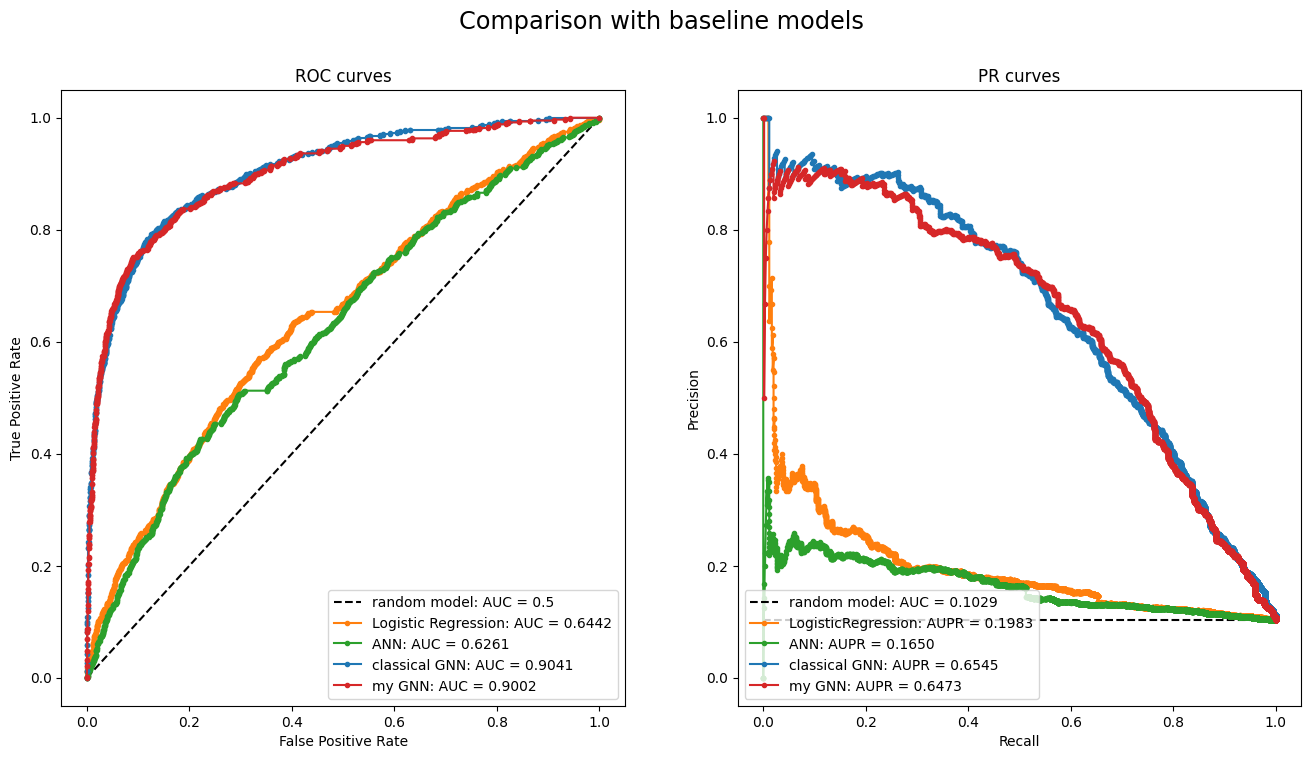

In [97]:
# target
targets = nodes.loc[nodes[nodes['mask']=='test'].index, 'y'].values
# preds
lr_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'lr_pred'].values
ann_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'ANN_pred'].values
gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'classical_GNN_pred'].values
my_gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'my_GNN_pred'].values

## curves
# random model
random_preds = [0 for _ in range(len(targets))]
random_auroc = roc_auc_score(targets, random_preds)
random_fpr, random_tpr, _ = roc_curve(targets, random_preds)   # ROC curves
no_skill_test = len(targets[targets == 1])/len(targets)             # PR curves
# LogisticRegression
lr_auroc = roc_auc_score(targets, lr_preds)
lr_fpr, lr_tpr, _ = roc_curve(targets, lr_preds)
lr_aupr = average_precision_score(targets, lr_preds)
lr_precision, lr_recall, _ = precision_recall_curve(targets, lr_preds)
# ANN
ann_auroc = roc_auc_score(targets, ann_preds)
ann_fpr, ann_tpr, _ = roc_curve(targets, ann_preds)
ann_aupr = average_precision_score(targets, ann_preds)
ann_precision, ann_recall, _ = precision_recall_curve(targets, ann_preds)
# classical_GNN
gnn_auroc = roc_auc_score(targets, gnn_preds)
gnn_fpr, gnn_tpr, _ = roc_curve(targets, gnn_preds)
gnn_aupr = average_precision_score(targets, gnn_preds)
gnn_precision, gnn_recall, _ = precision_recall_curve(targets, gnn_preds)
# my_GNN
my_gnn_auroc = roc_auc_score(targets, my_gnn_preds)
my_gnn_fpr, my_gnn_tpr, _ = roc_curve(targets, my_gnn_preds)
my_gnn_aupr = average_precision_score(targets, my_gnn_preds)
my_gnn_precision, my_gnn_recall, _ = precision_recall_curve(targets, my_gnn_preds)

# fig = plt.figure(figsize = (18, 9), constrained_layout = True)
# 
# # create 1 horizontal subfigures
# subfigs = fig.subfigures(1, 1)
# # create 2 vertical sub-sub-figure for each sub-figure
# ax_roc, ax_pr= subfigs[0].subplots(1, 2)

fig, (ax_roc, ax_pr) = plt.subplots(1,2, figsize = (16,8))#, constrained_layout=True)

fig.suptitle("Comparison with baseline models", fontsize = 'xx-large')

## do the first plot: AUROC
ax_roc.plot(random_fpr, random_tpr, linestyle='--', label=f'random model: AUC = {random_auroc}', color = 'black')
ax_roc.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic Regression: AUC = {lr_auroc:0.4f}', color = 'tab:orange') #'#ff7f0e'
ax_roc.plot(ann_fpr, ann_tpr, marker='.', label=f'ANN: AUC = {ann_auroc:0.4f}', color = 'tab:green')
ax_roc.plot(gnn_fpr, gnn_tpr, marker='.', label=f'classical GNN: AUC = {gnn_auroc:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_roc.plot(my_gnn_fpr, my_gnn_tpr, marker='.', label=f'my GNN: AUC = {my_gnn_auroc:0.4f}', color = 'tab:red') # 
# axis labels
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc = 'lower right')
ax_roc.set_title("ROC curves")
## do the second plot: AUPR
ax_pr.plot([0, 1], [no_skill_test, no_skill_test], linestyle='--', label=f'random model: AUC = {no_skill_test:0.4f}', color = 'black')
ax_pr.plot([0, 1], [0, 0], linestyle='--', label = None, color = 'purple', alpha = 0) # juste pour avoir la même échelle, tracer une ligne invisible, y = 0
ax_pr.plot(lr_recall, lr_precision, marker='.', label=f'LogisticRegression: AUPR = {lr_aupr:0.4f}', color = 'tab:orange') # '#ff7f0e'
ax_pr.plot(ann_recall, ann_precision, marker='.', label=f'ANN: AUPR = {ann_aupr:0.4f}', color = 'tab:green')
ax_pr.plot(gnn_recall, gnn_precision, marker='.', label=f'classical GNN: AUPR = {gnn_aupr:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_pr.plot(my_gnn_recall, my_gnn_precision, marker = '.', label=f'my GNN: AUPR = {my_gnn_aupr:0.4f}', color = 'tab:red') # '#1f77b4'
# axis labels
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc = 'lower left')
ax_pr.set_title("PR curves")

In [100]:
path_to_save = current_path + '/results/humans/baseline/'
fig_name = '20251010_humans_ML_ANN_GNN_split_seed_1_baseline_comparison.png'
fig.savefig(path_to_save+fig_name)

## metapath2vec

In [1]:
# there is a specific script for that

In [ ]:
# https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.models.MetaPath2Vec.html#torch_geometric.nn.models.MetaPath2Vec
# https://github.com/pyg-team/pytorch_geometric/blob/master/examples/hetero/metapath2vec.py

In [ ]:
# https://github.com/pyg-team/pytorch_geometric/discussions/4052
# only 1 metapath !!

#### split_seed = 1

In [262]:
# split_seed = 1, j = 1

split_seed = 1
j = 1
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

nodes = nodes2id['GENE']
gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = my_target, remove_sex_chrom = False, features_to_use = features)
nodes = pd.concat((nodes, feat), axis=1)

col_to_use = list(feat.columns)
col_to_use.remove('y')
target_col = ['y']

nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
# nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
new_test_mask = (data['GENE'].val_mask)
del data['GENE'].train_mask
del data['GENE'].val_mask
del data['GENE'].test_mask
data['GENE'].train_mask = new_train_mask
data['GENE'].test_mask = new_test_mask

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)


In [265]:
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
data['GENE'].num_nodes = len(data['GENE'].x)

In [266]:
from typing import Dict, List, Optional, Tuple

import torch
from torch import Tensor
from torch.nn import Embedding
from torch.utils.data import DataLoader

from torch_geometric.typing import EdgeType, NodeType, OptTensor
from torch_geometric.utils import sort_edge_index
from torch_geometric.utils.sparse import index2ptr

EPS = 1e-15


class my_MetaPath2Vec(torch.nn.Module):
    r"""The MetaPath2Vec model from the `"metapath2vec: Scalable Representation
    Learning for Heterogeneous Networks"
    <https://ericdongyx.github.io/papers/
    KDD17-dong-chawla-swami-metapath2vec.pdf>`_ paper where random walks based
    on a given :obj:`metapath` are sampled in a heterogeneous graph, and node
    embeddings are learned via negative sampling optimization.

    .. note::

        For an example of using MetaPath2Vec, see
        `examples/hetero/metapath2vec.py
        <https://github.com/pyg-team/pytorch_geometric/blob/master/examples/
        hetero/metapath2vec.py>`_.

    Args:
        edge_index_dict (Dict[Tuple[str, str, str], torch.Tensor]): Dictionary
            holding edge indices for each
            :obj:`(src_node_type, rel_type, dst_node_type)` edge type present
            in the heterogeneous graph.
        embedding_dim (int): The size of each embedding vector.
        metapath (List[Tuple[str, str, str]]): The metapath described as a list
            of :obj:`(src_node_type, rel_type, dst_node_type)` tuples.
        walk_length (int): The walk length.
        context_size (int): The actual context size which is considered for
            positive samples. This parameter increases the effective sampling
            rate by reusing samples across different source nodes.
        walks_per_node (int, optional): The number of walks to sample for each
            node. (default: :obj:`1`)
        num_negative_samples (int, optional): The number of negative samples to
            use for each positive sample. (default: :obj:`1`)
        num_nodes_dict (Dict[str, int], optional): Dictionary holding the
            number of nodes for each node type. (default: :obj:`None`)
        sparse (bool, optional): If set to :obj:`True`, gradients w.r.t. to the
            weight matrix will be sparse. (default: :obj:`False`)
    """
    def __init__(
        self,
        edge_index_dict: Dict[EdgeType, Tensor],
        embedding_dim: int,
        metapath: List[EdgeType],
        walk_length: int,
        context_size: int,
        walks_per_node: int = 1,
        num_negative_samples: int = 1,
        num_nodes_dict: Optional[Dict[NodeType, int]] = None,
        sparse: bool = False,
    ):
        super().__init__()

        if num_nodes_dict is None:
            num_nodes_dict = {}
            for keys, edge_index in edge_index_dict.items():
                key = keys[0]
                N = int(edge_index[0].max() + 1)
                num_nodes_dict[key] = max(N, num_nodes_dict.get(key, N))

                key = keys[-1]
                N = int(edge_index[1].max() + 1)
                num_nodes_dict[key] = max(N, num_nodes_dict.get(key, N))

        self.rowptr_dict, self.col_dict, self.rowcount_dict = {}, {}, {}
        for keys, edge_index in edge_index_dict.items():
            sizes = (num_nodes_dict[keys[0]], num_nodes_dict[keys[-1]])
            row, col = sort_edge_index(edge_index, num_nodes=max(sizes)).cpu()
            rowptr = index2ptr(row, size=sizes[0])
            self.rowptr_dict[keys] = rowptr
            self.col_dict[keys] = col
            self.rowcount_dict[keys] = rowptr[1:] - rowptr[:-1]

        for edge_type1, edge_type2 in zip(metapath[:-1], metapath[1:]):
            if edge_type1[-1] != edge_type2[0]:
                raise ValueError(
                    "Found invalid metapath. Ensure that the destination node "
                    "type matches with the source node type across all "
                    "consecutive edge types.")

        assert walk_length + 1 >= context_size
        if walk_length > len(metapath) and metapath[0][0] != metapath[-1][-1]:
            raise AttributeError(
                "The 'walk_length' is longer than the given 'metapath', but "
                "the 'metapath' does not denote a cycle")

        self.embedding_dim = embedding_dim
        self.metapath = metapath
        self.walk_length = walk_length
        self.context_size = context_size
        self.walks_per_node = walks_per_node
        self.num_negative_samples = num_negative_samples
        self.num_nodes_dict = num_nodes_dict

        types = set([x[0] for x in metapath]) | set([x[-1] for x in metapath])
        types = sorted(list(types))

        count = 0
        self.start, self.end = {}, {}
        for key in types:
            self.start[key] = count
            count += num_nodes_dict[key]
            self.end[key] = count

        offset = [self.start[metapath[0][0]]]
        offset += [self.start[keys[-1]] for keys in metapath
                   ] * int((walk_length / len(metapath)) + 1)
        offset = offset[:walk_length + 1]
        assert len(offset) == walk_length + 1
        self.offset = torch.tensor(offset)

        # + 1 denotes a dummy node used to link to for isolated nodes.
        self.embedding = Embedding(count + 1, embedding_dim, sparse=sparse)
        self.dummy_idx = count

        self.reset_parameters()

    def reset_parameters(self):
        r"""Resets all learnable parameters of the module."""
        self.embedding.reset_parameters()

    def forward(self, node_type: str, batch: OptTensor = None) -> Tensor:
        r"""Returns the embeddings for the nodes in :obj:`batch` of type
        :obj:`node_type`.
        """
        emb = self.embedding.weight[self.start[node_type]:self.end[node_type]]
        return emb if batch is None else emb.index_select(0, batch)

    def loader(self, **kwargs):
        r"""Returns the data loader that creates both positive and negative
        random walks on the heterogeneous graph.

        Args:
            **kwargs (optional): Arguments of
                :class:`torch.utils.data.DataLoader`, such as
                :obj:`batch_size`, :obj:`shuffle`, :obj:`drop_last` or
                :obj:`num_workers`.
        """
        return DataLoader(range(self.num_nodes_dict[self.metapath[0][0]]),
                          collate_fn=self._sample, **kwargs)

    def _pos_sample(self, batch: Tensor) -> Tensor:
        batch = batch.repeat(self.walks_per_node)

        rws = [batch]
        for i in range(self.walk_length):
            edge_type = self.metapath[i % len(self.metapath)]
            batch = sample(
                self.rowptr_dict[edge_type],
                self.col_dict[edge_type],
                self.rowcount_dict[edge_type],
                batch,
                num_neighbors=1,
                dummy_idx=self.dummy_idx,
            ).view(-1)
            rws.append(batch)

        rw = torch.stack(rws, dim=-1)
        rw.add_(self.offset.view(1, -1))
        rw[rw > self.dummy_idx] = self.dummy_idx

        walks = []
        num_walks_per_rw = 1 + self.walk_length + 1 - self.context_size
        for j in range(num_walks_per_rw):
            walks.append(rw[:, j:j + self.context_size])
        return torch.cat(walks, dim=0)

    def _neg_sample(self, batch: Tensor) -> Tensor:
        batch = batch.repeat(self.walks_per_node * self.num_negative_samples)

        rws = [batch]
        for i in range(self.walk_length):
            keys = self.metapath[i % len(self.metapath)]
            batch = torch.randint(0, self.num_nodes_dict[keys[-1]],
                                  (batch.size(0), ), dtype=torch.long)
            rws.append(batch)

        rw = torch.stack(rws, dim=-1)
        rw.add_(self.offset.view(1, -1))

        walks = []
        num_walks_per_rw = 1 + self.walk_length + 1 - self.context_size
        for j in range(num_walks_per_rw):
            walks.append(rw[:, j:j + self.context_size])
        return torch.cat(walks, dim=0)

    def _sample(self, batch: List[int]) -> Tuple[Tensor, Tensor]:
        if not isinstance(batch, Tensor):
            batch = torch.tensor(batch, dtype=torch.long)
        return self._pos_sample(batch), self._neg_sample(batch)

    def loss(self, pos_rw: Tensor, neg_rw: Tensor) -> Tensor:
        r"""Computes the loss given positive and negative random walks."""
        # Positive loss.
        start, rest = pos_rw[:, 0], pos_rw[:, 1:].contiguous()

        h_start = self.embedding(start).view(pos_rw.size(0), 1,
                                             self.embedding_dim)
        h_rest = self.embedding(rest.view(-1)).view(pos_rw.size(0), -1,
                                                    self.embedding_dim)

        out = (h_start * h_rest).sum(dim=-1).view(-1)
        pos_loss = -torch.log(torch.sigmoid(out) + EPS).mean()

        # Negative loss.
        start, rest = neg_rw[:, 0], neg_rw[:, 1:].contiguous()

        h_start = self.embedding(start).view(neg_rw.size(0), 1,
                                             self.embedding_dim)
        h_rest = self.embedding(rest.view(-1)).view(neg_rw.size(0), -1,
                                                    self.embedding_dim)

        out = (h_start * h_rest).sum(dim=-1).view(-1)
        neg_loss = -torch.log(1 - torch.sigmoid(out) + EPS).mean()

        return pos_loss + neg_loss

    def test(self, train_z: Tensor, train_y: Tensor, test_z: Tensor,
             test_y: Tensor, solver: str = "lbfgs", multi_class: str = "auto",
             *args, **kwargs) -> float:
        r"""Evaluates latent space quality via a logistic regression downstream
        task.
        """
        from sklearn.linear_model import LogisticRegression

        clf = LogisticRegression(solver=solver, multi_class=multi_class, *args,
                                 **kwargs).fit(train_z.detach().cpu().numpy(),
                                               train_y.detach().cpu().numpy())
        return (
            clf.score(test_z.detach().cpu().numpy(), test_y.detach().cpu().numpy()), 
            clf.predict_proba(train_z.detach().cpu().numpy()), 
            train_y.detach().cpu(),
            clf.predict_proba(test_z.detach().cpu().numpy()), 
            test_y.detach().cpu(),
            )

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}('
                f'{self.embedding.weight.size(0) - 1}, '
                f'{self.embedding.weight.size(1)})')


def sample(rowptr: Tensor, col: Tensor, rowcount: Tensor, subset: Tensor,
           num_neighbors: int, dummy_idx: int) -> Tensor:

    mask = subset >= dummy_idx
    subset = subset.clamp(min=0, max=rowptr.numel() - 2)
    count = rowcount[subset]

    rand = torch.rand((subset.size(0), num_neighbors), device=subset.device)
    rand *= count.to(rand.dtype).view(-1, 1)
    rand = rand.to(torch.long) + rowptr[subset].view(-1, 1)
    # based on the 2.6.1 release of pyg ? released on Sep. 26, 2024
    # https://github.com/pyg-team/pytorch_geometric/blob/master/torch_geometric/nn/models/metapath2vec.py
    rand = rand.clamp(max=col.numel() - 1)  # If last node is isolated.

    col = col[rand] if col.numel() > 0 else rand
    # col = col[rand-1] if col.numel() > 0 else rand
    col[mask | (count == 0)] = dummy_idx
    return col

In [267]:
from torch_geometric.utils import sort_edge_index
from torch_geometric.utils.sparse import index2ptr

rowptr_dict, col_dict, rowcount_dict = {}, {}, {}
for keys, edge_index in data.edge_index_dict.items():
    sizes = (data.num_nodes_dict[keys[0]], data.num_nodes_dict[keys[-1]])
    row, col = sort_edge_index(edge_index, num_nodes=max(sizes)).cpu()
    rowptr = index2ptr(row, size=sizes[0])
    rowptr_dict[keys] = rowptr
    col_dict[keys] = col
    rowcount_dict[keys] = rowptr[1:] - rowptr[:-1]

In [268]:
rowcount = rowcount_dict['GENE', 'paralog', 'GENE']
col = col_dict['GENE', 'paralog', 'GENE']
row = rowptr_dict['GENE', 'paralog', 'GENE']

In [259]:
data['GENE'].y_index = torch.from_numpy(pd.RangeIndex(19330).values)

In [269]:
metapath = [
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'paralog', 'GENE'),
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_BP', 'BP'), ('BP', 'biological_process', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBBBG
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_CC', 'CC'), ('CC', 'cellular_component', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCCCG
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE'), # GMMG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_MF', 'MF'), ('MF', 'molecular_function', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE') # GMMMMG
    ('GENE', 'expressed_in', 'ANATOMY'), ('ANATOMY', 'rev_expressed_in', 'GENE'), # GAAG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'expressed_in', 'ANATOMY'), ('ANATOMY', 'ana_ana', 'ANATOMY'), ('ANATOMY', 'rev_expressed_in', 'GENE'), # GAAAAG
]

model = my_MetaPath2Vec(
    data.edge_index_dict, embedding_dim=64,
    metapath = metapath, walk_length = 100, context_size = 10,
    walks_per_node = 20, num_negative_samples = 5,
    num_nodes_dict = {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19330, 'MF': 11271},
    sparse = True).to(device)

loader = model.loader(batch_size=64, shuffle=True, num_workers=6)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

def train(epoch, log_steps=100, eval_steps=2000):
    model.train()

    total_loss = 0
    for i, (pos_rw, neg_rw) in enumerate(loader):
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (i + 1) % log_steps == 0:
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Loss: {total_loss / log_steps:.4f}')
            total_loss = 0

        if (i + 1) % eval_steps == 0:
            acc = test()
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Acc: {acc:.4f}')


@torch.no_grad()
def test(train_ratio=0.1):
    model.eval()

    z = model('GENE', batch=data['GENE'].y_index.to(device))
    y = data['GENE'].y

    perm = torch.randperm(z.size(0))
    # train_perm = perm[:int(z.size(0) * train_ratio)]
    # test_perm = perm[int(z.size(0) * train_ratio):]
    train_perm = data['GENE'].train_mask #perm[:int(z.size(0) * train_ratio)]
    test_perm = data['GENE'].test_mask # perm[int(z.size(0) * train_ratio):]

    return model.test(z[train_perm], y[train_perm], z[test_perm], y[test_perm],max_iter=150) 


for epoch in range(1, 8):
    train(epoch)
    acc, train_preds, train_targets, test_preds, test_targets = test()
    print(f'Epoch: {epoch}, Accuracy: {acc:.4f}')

Epoch: 1, Step: 00100/303, Loss: 2.2336
Epoch: 1, Step: 00200/303, Loss: 1.0266
Epoch: 1, Step: 00300/303, Loss: 0.8076
Epoch: 1, Accuracy: 0.8969
Epoch: 2, Step: 00100/303, Loss: 0.7520
Epoch: 2, Step: 00200/303, Loss: 0.7232
Epoch: 2, Step: 00300/303, Loss: 0.7018
Epoch: 2, Accuracy: 0.8948
Epoch: 3, Step: 00100/303, Loss: 0.6776
Epoch: 3, Step: 00200/303, Loss: 0.6471
Epoch: 3, Step: 00300/303, Loss: 0.6124
Epoch: 3, Accuracy: 0.9040
Epoch: 4, Step: 00100/303, Loss: 0.5822
Epoch: 4, Step: 00200/303, Loss: 0.5581
Epoch: 4, Step: 00300/303, Loss: 0.5369
Epoch: 4, Accuracy: 0.9126
Epoch: 5, Step: 00100/303, Loss: 0.5212
Epoch: 5, Step: 00200/303, Loss: 0.5094
Epoch: 5, Step: 00300/303, Loss: 0.5005
Epoch: 5, Accuracy: 0.9136
Epoch: 6, Step: 00100/303, Loss: 0.4925
Epoch: 6, Step: 00200/303, Loss: 0.4864
Epoch: 6, Step: 00300/303, Loss: 0.4820
Epoch: 6, Accuracy: 0.9157
Epoch: 7, Step: 00100/303, Loss: 0.4770
Epoch: 7, Step: 00200/303, Loss: 0.4728
Epoch: 7, Step: 00300/303, Loss: 0.469

In [270]:
acc, train_preds, train_targets, test_preds, test_targets = test()
print(roc_auc_score(train_targets, train_preds[:,1]))
print(roc_auc_score(test_targets, test_preds[:,1]))

0.892763689316159
0.884385409654461


In [272]:
AUROC_test_metapath = roc_auc_score(test_targets, test_preds[:,1])
AUPR_test_metapath = average_precision_score(test_targets, test_preds[:,1])

In [273]:
metapath_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_metapath, 'AUPR_test': AUPR_test_metapath, 'model': 'Metapath', 'random_seed':1}, index=[split_seed]) 

In [274]:
metapath_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.884385,0.581445,Metapath,1


In [279]:
model

my_MetaPath2Vec(76970, 64)

In [280]:
print("Saving the model.")
model_path = "/data-tmp/rnicolle/models/baseline/"
# wl = walk_length, cs = context_size, wpn = walk_per_node, nns = num_nnegative_sample
model_name = "humans_baseline_metapath2vec_n2n_wl_100_cs_10_wpn_20_nns_5" f'_split_seed_{split_seed}_epoch_7.pyg'
torch.save(model.state_dict(), model_path+model_name)

Saving the model.


#### for loop 2,31

In [ ]:
for split_seed in range(2,31):
    print(f"split_seed: {split_seed}")
    j = 1
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

    nodes = nodes2id['GENE']
    gene_strict_tensor, target_tensor, feat = get_strict_target_tensors(target_to_use = target_of_script, remove_sex_chrom = False, features_to_use = features)
    nodes = pd.concat((nodes, feat), axis=1)

    col_to_use = list(feat.columns)
    col_to_use.remove('y')
    target_col = ['y']

    nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
    # I know 
    nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
    nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

    nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
    # nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
    new_test_mask = (data['GENE'].val_mask)
    del data['GENE'].train_mask
    del data['GENE'].val_mask
    del data['GENE'].test_mask
    data['GENE'].train_mask = new_train_mask
    data['GENE'].test_mask = new_test_mask

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    metapath = [
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'paralog', 'GENE'),
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_BP', 'BP'), ('BP', 'biological_process', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBBBG
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_CC', 'CC'), ('CC', 'cellular_component', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCCCG
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE'), # GMMG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_MF', 'MF'), ('MF', 'molecular_function', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE') # GMMMMG
    ('GENE', 'expressed_in', 'ANATOMY'), ('ANATOMY', 'rev_expressed_in', 'GENE'), # GAAG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'expressed_in', 'ANATOMY'), ('ANATOMY', 'ana_ana', 'ANATOMY'), ('ANATOMY', 'rev_expressed_in', 'GENE'), # GAAAAG
    ]

    model = my_MetaPath2Vec(
        data.edge_index_dict, embedding_dim=64,
        metapath = metapath, walk_length = 100, context_size = 10,
        walks_per_node = 20, num_negative_samples = 5,
        num_nodes_dict = {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19330, 'MF': 11271},
        sparse = True).to(device)

    loader = model.loader(batch_size=64, shuffle=True, num_workers=6)
    optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

    def train(epoch, log_steps=100, eval_steps=2000):
        model.train()

        total_loss = 0
        for i, (pos_rw, neg_rw) in enumerate(loader):
            optimizer.zero_grad()
            loss = model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            if (i + 1) % log_steps == 0:
                print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                    f'Loss: {total_loss / log_steps:.4f}')
                total_loss = 0

            if (i + 1) % eval_steps == 0:
                acc = test()
                print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                    f'Acc: {acc:.4f}')


    @torch.no_grad()
    def test(train_ratio=0.1):
        model.eval()

        z = model('GENE', batch=data['GENE'].y_index.to(device))
        y = data['GENE'].y

        perm = torch.randperm(z.size(0))
        # train_perm = perm[:int(z.size(0) * train_ratio)]
        # test_perm = perm[int(z.size(0) * train_ratio):]
        train_perm = data['GENE'].train_mask #perm[:int(z.size(0) * train_ratio)]
        test_perm = data['GENE'].test_mask # perm[int(z.size(0) * train_ratio):]

        return model.test(z[train_perm], y[train_perm], z[test_perm], y[test_perm],max_iter=150) 


    for epoch in range(1, 8):
        train(epoch)
        acc, train_preds, train_targets, test_preds, test_targets = test()
        print(f'Epoch: {epoch}, Accuracy: {acc:.4f}')

    print("Saving the model.")
    model_path = "/data-tmp/rnicolle/models/baseline/"
    # wl = walk_length, cs = context_size, wpn = walk_per_node, nns = num_nnegative_sample
    model_name = "humans_baseline_metapath2vec_n2n_wl_100_cs_10_wpn_20_nns_5" f'_split_seed_{split_seed}_epoch_7.pyg'
    torch.save(model.state_dict(), model_path+model_name)

    AUROC_test_metapath = roc_auc_score(test_targets, test_preds[:,1])
    AUPR_test_metapath = average_precision_score(test_targets, test_preds[:,1])
    metapath_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_metapath, 'AUPR_test': AUPR_test_metapath, 'model': 'Metapath', 'random_seed':1}, index=[split_seed]) 
    metapath_tot = pd.concat([metapath_tot, metapath_tmp], axis=0)
    print("xxx")

split_seed: 2
tensor(12176)
tensor(1354)
tensor(13530)
tensor(5800)
Epoch: 1, Step: 00100/303, Loss: 2.2233


In [ ]:
metapath_tot

In [ ]:
path = current_path + '/results/humans/baseline/'
df_name = 'humans_baseline_metapath2vec_30_seeds.tsv'
metapath_tot.to_csv(path+df_name, header=True, index=False, sep='\t')

### old replot now

In [83]:
train_df = pd.DataFrame(np.concatenate([train_preds[:,1].reshape(-1,1), train_targets.reshape(-1,1)], axis=1), columns = ['pred', 'target'])
test_df = pd.DataFrame(np.concatenate([test_preds[:,1].reshape(-1,1), test_targets.reshape(-1,1)], axis=1), columns = ['pred', 'target'])

In [84]:
path_to_save = '/data-tmp/rnicolle/'
df_name = '20251010_humans_ML_ANN_GNN_split_seed_1.tsv'
nodes = pd.read_csv(path_to_save+df_name, header=0, sep='\t')

In [85]:
nodes

,GENE_id,mapped_id,zscore_mis,zscore_syn,f_parameter,GDI,y,train,val,test,mask,lr_pred,ANN_pred,classical_GNN_pred,my_GNN_pred
0,ENSG00000000003,0,-0.165279,-0.227964,-0.691348,-0.267739,0,0.0,1.0,0.0,val,0.114461,0.140085,0.023189,0.000733
1,ENSG00000000005,1,0.048602,-0.220098,-1.245063,-0.459383,0,0.0,0.0,1.0,test,0.128028,0.129523,0.158608,0.004104
2,ENSG00000000419,2,-0.331631,-1.242591,-0.148785,-0.428285,1,0.0,0.0,1.0,test,0.130987,0.141591,0.490302,0.037919
3,ENSG00000000457,3,0.143660,0.700145,0.400692,-0.169516,0,0.0,0.0,1.0,test,0.097200,0.116716,0.045333,0.034163
4,ENSG00000000460,4,-0.181122,0.841721,-0.315230,-0.116321,0,1.0,0.0,0.0,train,0.087928,0.095535,0.076387,0.067051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,-0.133593,0.125976,-0.045295,-0.362680,0,0.0,0.0,1.0,test,0.104082,0.133961,0.043036,0.011574
19326,ENSG00000291237,19326,0.222876,0.007996,0.369782,0.606246,1,1.0,0.0,0.0,train,0.109881,0.163128,0.907278,0.681371
19327,ENSG00000291307,19327,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.133961,0.309800,0.096073
19328,ENSG00000291317,19328,-0.133593,0.125976,-0.045295,-0.362680,0,1.0,0.0,0.0,train,0.104082,0.133961,0.007523,0.001830


In [86]:
train_idx = nodes[nodes['mask'].isin(['train', 'val'])].index
test_idx = nodes[nodes['mask']=='test'].index

In [87]:
print(sum(nodes.loc[train_idx,'y'] == train_targets.detach().cpu().numpy().astype(int)))
print(sum(nodes.loc[test_idx,'y'] == test_targets.detach().cpu().numpy().astype(int)))

13530
5800


In [88]:
nodes.loc[train_idx,['metapath_pred']] = train_preds[:,1]
nodes.loc[test_idx,['metapath_pred']] = test_preds[:,1]

Text(0.5, 1.0, 'PR curves')

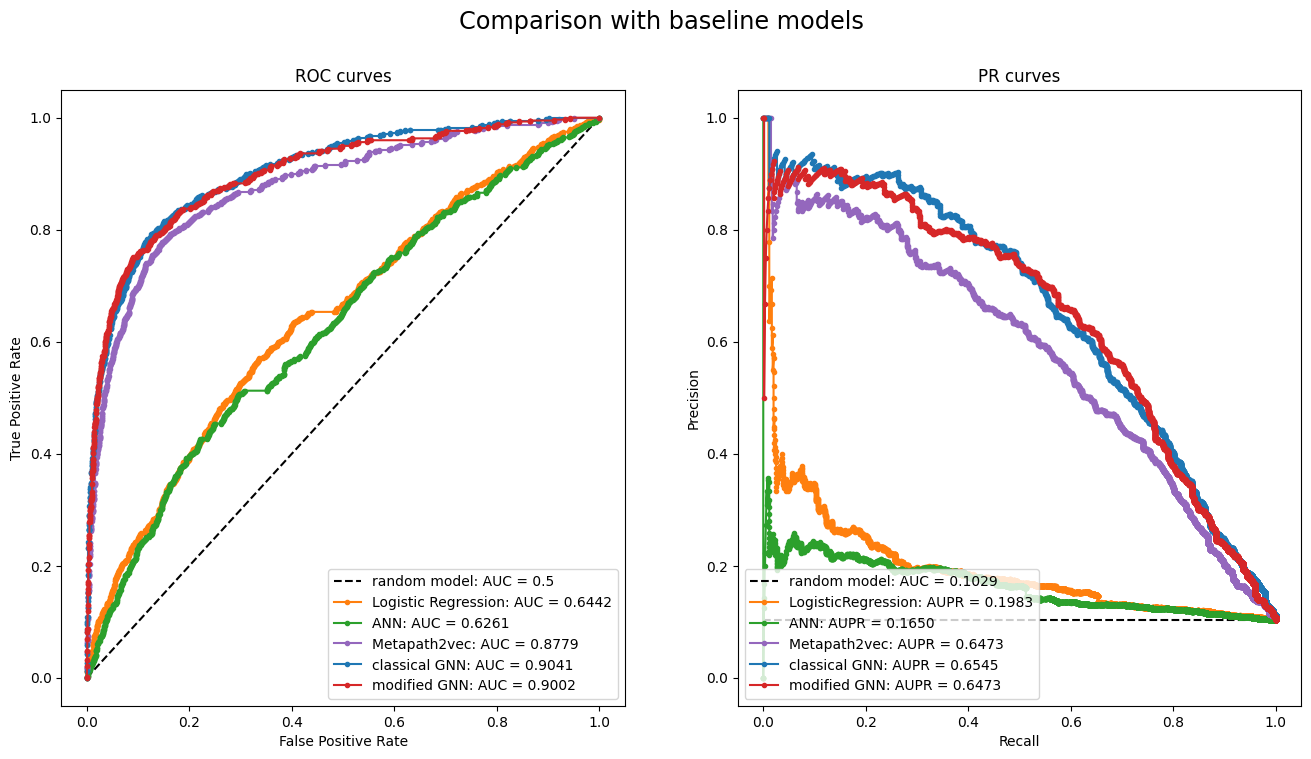

In [89]:
# target
targets = nodes.loc[nodes[nodes['mask']=='test'].index, 'y'].values
# preds
lr_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'lr_pred'].values
ann_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'ANN_pred'].values
gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'classical_GNN_pred'].values
my_gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'my_GNN_pred'].values
metapath2vec_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'metapath_pred'].values

## curves
# random model
random_preds = [0 for _ in range(len(targets))]
random_auroc = roc_auc_score(targets, random_preds)
random_fpr, random_tpr, _ = roc_curve(targets, random_preds)   # ROC curves
no_skill_test = len(targets[targets == 1])/len(targets)             # PR curves
# LogisticRegression
lr_auroc = roc_auc_score(targets, lr_preds)
lr_fpr, lr_tpr, _ = roc_curve(targets, lr_preds)
lr_aupr = average_precision_score(targets, lr_preds)
lr_precision, lr_recall, _ = precision_recall_curve(targets, lr_preds)
# ANN
ann_auroc = roc_auc_score(targets, ann_preds)
ann_fpr, ann_tpr, _ = roc_curve(targets, ann_preds)
ann_aupr = average_precision_score(targets, ann_preds)
ann_precision, ann_recall, _ = precision_recall_curve(targets, ann_preds)
# classical_GNN
gnn_auroc = roc_auc_score(targets, gnn_preds)
gnn_fpr, gnn_tpr, _ = roc_curve(targets, gnn_preds)
gnn_aupr = average_precision_score(targets, gnn_preds)
gnn_precision, gnn_recall, _ = precision_recall_curve(targets, gnn_preds)
# my_GNN
my_gnn_auroc = roc_auc_score(targets, my_gnn_preds)
my_gnn_fpr, my_gnn_tpr, _ = roc_curve(targets, my_gnn_preds)
my_gnn_aupr = average_precision_score(targets, my_gnn_preds)
my_gnn_precision, my_gnn_recall, _ = precision_recall_curve(targets, my_gnn_preds)
# metapath2vec
metapath2vec_auroc = roc_auc_score(targets, metapath2vec_preds)
metapath2vec_fpr, metapath2vec_tpr, _ = roc_curve(targets, metapath2vec_preds)
metapath2vec_aupr = average_precision_score(targets, metapath2vec_preds)
metapath2vec_precision, metapath2vec_recall, _ = precision_recall_curve(targets, metapath2vec_preds)

# fig = plt.figure(figsize = (18, 9), constrained_layout = True)
# 
# # create 1 horizontal subfigures
# subfigs = fig.subfigures(1, 1)
# # create 2 vertical sub-sub-figure for each sub-figure
# ax_roc, ax_pr= subfigs[0].subplots(1, 2)

fig, (ax_roc, ax_pr) = plt.subplots(1,2, figsize = (16,8))#, constrained_layout=True)

fig.suptitle("Comparison with baseline models", fontsize = 'xx-large')

## do the first plot: AUROC
ax_roc.plot(random_fpr, random_tpr, linestyle='--', label=f'random model: AUC = {random_auroc}', color = 'black')
ax_roc.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic Regression: AUC = {lr_auroc:0.4f}', color = 'tab:orange') #'#ff7f0e'
ax_roc.plot(ann_fpr, ann_tpr, marker='.', label=f'ANN: AUC = {ann_auroc:0.4f}', color = 'tab:green')
ax_roc.plot(metapath2vec_fpr, metapath2vec_tpr, marker='.', label=f'Metapath2vec: AUC = {metapath2vec_auroc:0.4f}', color = 'tab:purple') # 
ax_roc.plot(gnn_fpr, gnn_tpr, marker='.', label=f'classical GNN: AUC = {gnn_auroc:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_roc.plot(my_gnn_fpr, my_gnn_tpr, marker='.', label=f'modified GNN: AUC = {my_gnn_auroc:0.4f}', color = 'tab:red') # 

# axis labels
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc = 'lower right')
ax_roc.set_title("ROC curves")
## do the second plot: AUPR
ax_pr.plot([0, 1], [no_skill_test, no_skill_test], linestyle='--', label=f'random model: AUC = {no_skill_test:0.4f}', color = 'black')
ax_pr.plot([0, 1], [0, 0], linestyle='--', label = None, color = 'purple', alpha = 0) # juste pour avoir la même échelle, tracer une ligne invisible, y = 0
ax_pr.plot(lr_recall, lr_precision, marker='.', label=f'LogisticRegression: AUPR = {lr_aupr:0.4f}', color = 'tab:orange') # '#ff7f0e'
ax_pr.plot(ann_recall, ann_precision, marker='.', label=f'ANN: AUPR = {ann_aupr:0.4f}', color = 'tab:green')
ax_pr.plot(metapath2vec_recall, metapath2vec_precision, marker = '.', label=f'Metapath2vec: AUPR = {my_gnn_aupr:0.4f}', color = 'tab:purple') # '#1f77b4'
ax_pr.plot(gnn_recall, gnn_precision, marker='.', label=f'classical GNN: AUPR = {gnn_aupr:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_pr.plot(my_gnn_recall, my_gnn_precision, marker = '.', label=f'modified GNN: AUPR = {my_gnn_aupr:0.4f}', color = 'tab:red') # '#1f77b4'

# axis labels
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc = 'lower left')
ax_pr.set_title("PR curves")

In [90]:
path_to_save = '/data-tmp/rnicolle/'
fig_name = '20251010_humans_ML_ANN_M2V_GNN_split_seed_1_baseline_comparison_v2.png'
fig.savefig(path_to_save+fig_name)

In [91]:
path_to_save = '/data-tmp/rnicolle/'
df_name = '20251010_humans_ML_ANN_M2V_GNN_split_seed_1.tsv'
nodes.to_csv(path_to_save+df_name, header=True, index=False, sep='\t')

#### metapath_next

In [26]:
metapath_2 = [
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'paralog', 'GENE'),
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_MF', 'MF'), ('MF', 'molecular_function', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE') # GMMMMG
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCG
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_BP', 'BP'), ('BP', 'biological_process', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBBBG
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE'), # GMMG
    ('GENE', 'PPI', 'GENE'),

    # ('GENE', 'gene_to_CC', 'CC'), ('CC', 'cellular_component', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCCCG
    ('GENE', 'expressed_in', 'ANATOMY'), ('ANATOMY', 'rev_expressed_in', 'GENE'), # GAAG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'expressed_in', 'ANATOMY'), ('ANATOMY', 'ana_ana', 'ANATOMY'), ('ANATOMY', 'rev_expressed_in', 'GENE'), # GAAAAG
]

model = my_MetaPath2Vec(
    data.edge_index_dict, embedding_dim=64,
    metapath = metapath_2, walk_length = 100, context_size = 10,
    walks_per_node = 20, num_negative_samples = 5,
    num_nodes_dict = {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19330, 'MF': 11271},
    sparse = True).to(device)

loader = model.loader(batch_size=64, shuffle=True, num_workers=6)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

def train(epoch, log_steps=100, eval_steps=2000):
    model.train()

    total_loss = 0
    for i, (pos_rw, neg_rw) in enumerate(loader):
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (i + 1) % log_steps == 0:
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Loss: {total_loss / log_steps:.4f}')
            total_loss = 0

        if (i + 1) % eval_steps == 0:
            acc = test()
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Acc: {acc:.4f}')


@torch.no_grad()
def test(train_ratio=0.1):
    model.eval()

    z = model('GENE', batch=data['GENE'].y_index.to(device))
    y = data['GENE'].y

    perm = torch.randperm(z.size(0))
    # train_perm = perm[:int(z.size(0) * train_ratio)]
    # test_perm = perm[int(z.size(0) * train_ratio):]
    train_perm = data['GENE'].train_mask #perm[:int(z.size(0) * train_ratio)]
    test_perm = data['GENE'].test_mask # perm[int(z.size(0) * train_ratio):]

    return model.test(z[train_perm], y[train_perm], z[test_perm], y[test_perm],max_iter=150) 


for epoch in range(1, 8):
    train(epoch)
    acc, preds, targets = test()
    print(f'Epoch: {epoch}, Accuracy: {acc:.4f}')

acc, preds, targets = test()
print(roc_auc_score(targets, preds))
print(average_precision_score(targets, preds))

Epoch: 1, Step: 00100/303, Loss: 2.2326
Epoch: 1, Step: 00200/303, Loss: 1.0259
Epoch: 1, Step: 00300/303, Loss: 0.8070
Epoch: 1, Accuracy: 0.8966
Epoch: 2, Step: 00100/303, Loss: 0.7513
Epoch: 2, Step: 00200/303, Loss: 0.7248
Epoch: 2, Step: 00300/303, Loss: 0.7029
Epoch: 2, Accuracy: 0.8931
Epoch: 3, Step: 00100/303, Loss: 0.6699
Epoch: 3, Step: 00200/303, Loss: 0.6369
Epoch: 3, Step: 00300/303, Loss: 0.6077
Epoch: 3, Accuracy: 0.9060
Epoch: 4, Step: 00100/303, Loss: 0.5836
Epoch: 4, Step: 00200/303, Loss: 0.5619
Epoch: 4, Step: 00300/303, Loss: 0.5417
Epoch: 4, Accuracy: 0.9128
Epoch: 5, Step: 00100/303, Loss: 0.5244
Epoch: 5, Step: 00200/303, Loss: 0.5117
Epoch: 5, Step: 00300/303, Loss: 0.5034
Epoch: 5, Accuracy: 0.9181
Epoch: 6, Step: 00100/303, Loss: 0.4947
Epoch: 6, Step: 00200/303, Loss: 0.4886
Epoch: 6, Step: 00300/303, Loss: 0.4839
Epoch: 6, Accuracy: 0.9219
Epoch: 7, Step: 00100/303, Loss: 0.4785
Epoch: 7, Step: 00200/303, Loss: 0.4751
Epoch: 7, Step: 00300/303, Loss: 0.472

In [ ]:
metapath_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 'model': 'GNN_classic_relu_16', 'random_seed':1}, index=[split_seed]) 

# Humans_cross_val best

In [97]:
path = current_path + '/results/humans/baseline/'
name = 'humans_n2n_inner_cross_validation_results.tsv'
df = pd.read_csv(path+name, header=0, sep='\t')

In [98]:
df = df[df['parameters'].str.contains('mean')]

In [99]:
df

,parameters,AUROC_train,AUROC_val,AUROC_test,AUPR_train,AUPR_val,AUPR_test,best_MCC_train,best_MCC_train_threshold,best_MCC_train_cm,...,heteroconv_aggr_2,conv_type,sage_aggr,sage_norm,GATv2_heads,neighbors,batch_size,activation,split_seed,val_set_fold
10,seed_1_cv_mean_relu_16,NaN,NaN,0.907300,NaN,NaN,0.644050,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
22,seed_1_cv_mean_relu_32,NaN,NaN,0.908769,NaN,NaN,0.647559,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
34,seed_1_cv_mean_relu_64,NaN,NaN,0.904552,NaN,NaN,0.635660,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
46,seed_1_cv_mean_tanh_16,NaN,NaN,0.903104,NaN,NaN,0.641622,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
58,seed_1_cv_mean_tanh_32,NaN,NaN,0.902723,NaN,NaN,0.637776,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2110,seed_30_cv_mean_relu_32,NaN,NaN,0.904802,NaN,NaN,0.640602,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,NaN
2122,seed_30_cv_mean_relu_64,NaN,NaN,0.903164,NaN,NaN,0.635520,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,NaN
2134,seed_30_cv_mean_tanh_16,NaN,NaN,0.901883,NaN,NaN,0.637791,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,NaN
2146,seed_30_cv_mean_tanh_32,NaN,NaN,0.900085,NaN,NaN,0.630436,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,NaN


In [ ]:
my_dict = {}

final_df = pd.DataFrame()

# best model accrding to AUROC

for i in range(1,31):
    tmp_df = df[df['split_seed']==i]
    tmp_df = tmp_df.reset_index(drop=True)
    best_auroc = tmp_df['AUROC_test'].max()
    best_aupr = tmp_df['AUPR_test'].max()
    best_param = tmp_df[tmp_df['AUROC_test'] == best_auroc]['parameters'].iloc[0].split('mean_')[1]
    print(f"for split_seed: {i}, best_params: {best_param}")
    my_dict[i] = best_param
    df_tmp = pd.DataFrame(data = {'AUROC_test': best_auroc, 'AUPR_test': best_aupr, 'split_seed': i, 'parameters':best_param}, index=[i]) 
    if final_df.shape[0] == 0:
        final_df = df_tmp.copy()
    else:
        final_df = pd.concat([final_df, df_tmp], axis=0)


for split_seed: 1, best_params: relu_32
for split_seed: 2, best_params: relu_32
for split_seed: 3, best_params: relu_16
for split_seed: 4, best_params: relu_64
for split_seed: 5, best_params: relu_16
for split_seed: 6, best_params: relu_16
for split_seed: 7, best_params: relu_16
for split_seed: 8, best_params: relu_32
for split_seed: 9, best_params: relu_32
for split_seed: 10, best_params: relu_16
for split_seed: 11, best_params: relu_16
for split_seed: 12, best_params: relu_32
for split_seed: 13, best_params: relu_32
for split_seed: 14, best_params: relu_32
for split_seed: 15, best_params: relu_16
for split_seed: 16, best_params: relu_16
for split_seed: 17, best_params: relu_16
for split_seed: 18, best_params: relu_16
for split_seed: 19, best_params: relu_64
for split_seed: 20, best_params: relu_16
for split_seed: 21, best_params: relu_16
for split_seed: 22, best_params: relu_32
for split_seed: 23, best_params: relu_64
for split_seed: 24, best_params: relu_32
for split_seed: 25, best_

In [101]:
my_dict

{1: 'relu_32',
 2: 'relu_32',
 3: 'relu_16',
 4: 'relu_64',
 5: 'relu_16',
 6: 'relu_16',
 7: 'relu_16',
 8: 'relu_32',
 9: 'relu_32',
 10: 'relu_16',
 11: 'relu_16',
 12: 'relu_32',
 13: 'relu_32',
 14: 'relu_32',
 15: 'relu_16',
 16: 'relu_16',
 17: 'relu_16',
 18: 'relu_16',
 19: 'relu_64',
 20: 'relu_16',
 21: 'relu_16',
 22: 'relu_32',
 23: 'relu_64',
 24: 'relu_32',
 25: 'relu_16',
 26: 'relu_16',
 27: 'relu_32',
 28: 'relu_32',
 29: 'relu_16',
 30: 'relu_32'}

In [ ]:
path = '/data-tmp/rnicolle/results/baseline/'
df_name = "humans_cross_val_best_params.tsv"
final_df.to_csv(path+df_name, header=0, mode='x')

In [102]:
final_df

,AUROC_test,AUPR_test,split_seed,parameters
1,0.908769,0.647559,1,relu_32
2,0.904642,0.635747,2,relu_32
3,0.904454,0.633355,3,relu_16
4,0.904187,0.640707,4,relu_64
5,0.906687,0.649800,5,relu_16
6,0.904301,0.649384,6,relu_16
7,0.903691,0.629764,7,relu_16
8,0.905341,0.642743,8,relu_32
9,0.905909,0.634203,9,relu_32
10,0.902283,0.625756,10,relu_16


In [103]:
print(final_df['AUROC_test'].mean())
print(final_df['AUROC_test'].std())
print(final_df['AUPR_test'].mean())
print(final_df['AUPR_test'].std())

# 0.9049058741819197
# 0.002199817429720591
# 0.6385910230188839
# 0.007575131283891007

0.9049058741819197
0.002199817429720591
0.6385910230188839
0.007575131283891007


# Yeasts Intro

In [ ]:
#!/usr/bin/env python

## intro

import numpy as np 
import pandas as pd
import random 
import os
from typing import Tuple, List
import time

# https://discuss.pytorch.org/t/how-to-enable-torch-use-cuda-dsa/202824/5
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"
# https://discuss.pytorch.org/t/keep-getting-cuda-oom-error-with-pytorch-failing-to-allocate-all-free-memory/133896/10
# https://dev.to/shittu_olumide_/how-can-i-set-maxsplitsizemb-to-avoid-fragmentation-in-pytorch-37h9
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64 "

from tqdm import tqdm
import torch
import copy
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
import torch_geometric
# from torch_geometric import seed_everything
from torch_geometric.data import Data, HeteroData
from torch_geometric.loader import NeighborLoader, ImbalancedSampler
import torch_geometric.transforms as T
import torch_geometric.utils as U
from torch_geometric.utils import coalesce
from torch_geometric.nn import summary, HeteroConv, GATv2Conv, SAGEConv, Linear
import pyg_lib
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, f1_score, auc, precision_recall_fscore_support, matthews_corrcoef 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import tempfile
# edit the line below to specify specify tmp_directory
# tempfile.tempdir = ''

torch.multiprocessing.set_sharing_strategy('file_system')
# https://stackoverflow.com/questions/71642653/how-to-resolve-the-error-runtimeerror-received-0-items-of-ancdata
import resource
rlimit = resource.getrlimit(resource.RLIMIT_NOFILE)
resource.setrlimit(resource.RLIMIT_NOFILE, (4096, rlimit[1]))

print(f"numpy.__version__ = {np.__version__}")
print(f"pandas.__version__ = {pd.__version__}")
print(f"torch.__version__ = {torch.__version__}")
print(f"torch_geometric.__version__ = {torch_geometric.__version__}")
print(f"pyg_lib.__version__ = {pyg_lib.__version__}")

hyperparameters = {
    'gene_mode': 'degree',
    'node_mode' : 'degree', #'id' or 'degree' for abcm nodes_types
    'edge_features' : False, # True = those are the true edge_weights from my network
    'Heads' : 1, #2
    # 'conv_number' : 2, # 
    # 'conv_type': 'SAGE', # 
    'sage_aggr': 'sum', # 'sum', 'var'
    'sage_norm': True, # False
    'sage_project': False,
    'heteroconv_aggr' : 'sum', # 'cat', 'max'
    'heteroconv_aggr_1' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_2' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_3' : 'sum', # 'cat', 'max'
    # 'activation': 'relu', # 'relu', 'tanh'
    'hc_2_q' : 1, # hc_2 = int(i/hc_2_q)
    'hc_3_q': 1, # hc_3_q = int(i/hc_3_q)
    # 'size_of_batch': 32,
    'neighbors': 30, #30, 40, 50
    'disjoint_loader' : True, 
    'zero_out_batch_features': True,
    'epochs_to_train' : 500, #
    'min_epochs_to_train': 3,
    'patience': 10,
    'min_delta': 0.005,
    'auto_loop': False,
    'nodes_pairs_features': 'zeros', #
    'dnds_mode': 'sum',
    'type_to_return': 'torch', # 'numpy'
    'final_type': 'torch', # 'numpy'
    'remove_forbidden_value': True,
    'shuffle_train': True,
    'ana_edges': 'common', # 'all
    'string_threshold': 700, # confidence = {'low': 0.15, 'medium': 0.4, 'high': 0.7, 'highest': 0.9} from STRING doc, * 1000 to have EdgeScore
    'setting': 'nodes_to_nodes',
    'global_loader_neighbors': 'all' # neighbors
}


dict_j = {1:'01', 2:'02', 3:'03', 4:'04', 5:'05', 6:'06', 7:'07', 8:'08', 9:'09', 10:'10'}

sage_aggr = hyperparameters['sage_aggr'] # 'sum'
sage_norm = hyperparameters['sage_norm'] # 'sum'
heteroconv_aggr = hyperparameters['heteroconv_aggr'] #'sum', 'cat'
heteroconv_aggr_1 = hyperparameters['heteroconv_aggr_1'] #'sum', 'cat'
heteroconv_aggr_2 = hyperparameters['heteroconv_aggr_2'] #'sum', 'cat'
heteroconv_aggr_3 = hyperparameters['heteroconv_aggr_3'] #'sum', 'cat'
node_mode = hyperparameters['node_mode'] # 'id' or 'degree'
sage_norm = hyperparameters['sage_norm']
Heads = hyperparameters['Heads']
ana_edges = hyperparameters['ana_edges']
string_threshold = hyperparameters['string_threshold']
# conv_number = hyperparameters['conv_number']
setting = hyperparameters['setting']
# conv_type = hyperparameters['conv_type']
heads = hyperparameters['Heads']
# activation = hyperparameters['activation']
global_loader_neighbors = hyperparameters['global_loader_neighbors']


t0 = time.time()

old_path = os.getcwd()
new_path = old_path + '/../../'
os.chdir(new_path)
current_path = os.getcwd()
data_raw_path = current_path + '/data/raw/'
data_processed_path = current_path + '/data/processed/'

# open the Yeasst_Knowledge_Graph
net = pd.read_csv(data_processed_path + f'yeast_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)

all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
# I could hardcode edges_names, edge_summary eveneutally
edges_names = net['EdgeType'].value_counts().to_dict()
edges_summary = []
for edge_name in edges_names.keys():
    tmp_list = [edge_name, 
                net[net['EdgeType'] == edge_name]['node1_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['node2_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['EdgeDirection'].unique()[0], 
                edges_names[edge_name]]
    # create a special case when there are edge_attributes
    # not currently using edges_attributes, but maybe in a future version 
    if sum(net[net['EdgeType'] == edge_name]['EdgeScore'].isna()) == 0:
        tmp_list.append(1)
    else:
        tmp_list.append(0)
    edges_summary.append(tmp_list) 

edges_types = list(set(net['EdgeType'].unique()))
nodes_types = list(set().union(net['node1_type'].unique(),net['node2_type'].unique()))
nodes_types.sort()
nodes_numbers = {}
for node_type in nodes_types:
    nodes_numbers[node_type] = len(set().union(net[net['node1_type'] == node_type]['node1_ID'].unique(), net[net['node2_type'] == node_type]['node2_ID'].unique()))

print(f"nodes_types: {nodes_types}")
print(f"nodes_numbers: {nodes_numbers}")

list_of_edges = net['EdgeType'].unique().tolist()

def Get_df_for_nodetype_id(df: pd.DataFrame, node_type : str) -> pd.DataFrame:
    node_type_list = list(set().union(df[df['node1_type'] == node_type]['node1_ID'].unique(), df[df['node2_type'] == node_type]['node2_ID'].unique()))
    node_type_list.sort()
    node_type_array = np.asarray(node_type_list)
    new_df = pd.DataFrame(data = {
        f"{node_type}_id": node_type_array,
        "mapped_id": pd.RangeIndex(len(node_type_array))
    })
    return(new_df)

nodes2id = {}
for type_of_node in nodes_types:
    nodes2id[type_of_node] = Get_df_for_nodetype_id(net, type_of_node)

edges_to_nodes = {}
for type_of_edge in edges_summary:
    edges_to_nodes[type_of_edge[0]] = [type_of_edge[1], type_of_edge[2]] 

def Get_df_for_edgetype(df: pd.DataFrame, type_of_edge: str, edge_score: bool = False) -> pd.DataFrame:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = df[df['EdgeType'] == type_of_edge].loc[:,["node1_ID", "node2_ID", "EdgeScore"]]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {f"{node1_type}_id": f"{node1_type}1_id", 'mapped_id': 'node1_mapped_id'})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {f"{node1_type}_id": f"{node1_type}2_id", 'mapped_id': 'node2_mapped_id'})
    if edge_score == False:
        new_df = new_df.drop('EdgeScore', axis = 1)
    return new_df

def Get_tensor_for_edges(df: pd.DataFrame, type_of_edge: str) -> torch.Tensor:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = df[df['EdgeType'] == type_of_edge]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node1_mapped_id"})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node2_mapped_id"})
    return torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)

def Get_tensor_and_rev_for_edges(df: pd.DataFrame, type_of_edge: str) -> torch.Tensor:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = df[df['EdgeType'] == type_of_edge]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node1_mapped_id"})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node2_mapped_id"})
    source, destination = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
    source_tot = torch.cat([source, destination])      
    destination_tot = torch.cat([destination, source])
    edge_index = torch.stack([source_tot, destination_tot], dim = 0)  
    return edge_index

edges2df = {}
for sublist in edges_summary:
    if sublist[5] == 1: 
        edges2df[sublist[0]] = Get_df_for_edgetype(net, sublist[0], True)
    else:
        edges2df[sublist[0]] = Get_df_for_edgetype(net, sublist[0], False)

def get_target_tensor():
    # for nodes, essential vs non_essential
    essential = pd.read_csv('data/processed/yeast_essential_nonessential_20240612.tsv', sep = '\t', header = 0)
    nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
    nodes = nodes2id['GENE'].copy()
    nodes = nodes.merge(essential, how = 'left', left_on = 'GENE_id', right_on = 'gene_id')
    nodes.loc[nodes[nodes['type'] == 'essential'].index, 'target'] = 1
    nodes.loc[nodes[nodes['type'] == 'non_essential'].index, 'target'] = 0
    target_tensor = torch.from_numpy(nodes['target'].values)
    return target_tensor 

def add_strict_nodes(data: HeteroData) -> HeteroData:
    target_tensor = get_target_tensor()
    data['GENE'].num_nodes = len(nodes2id['GENE'])
    data['GENE'].y = target_tensor.type(torch.float32)
    for type_of_node in nodes_types:
        if type_of_node != 'GENE':
            data[type_of_node].num_nodes = len(nodes2id[type_of_node])
    return data

def create_masks_cross_val(data: HeteroData, split_seed: int = 1, cv_fold_to_test: int = 1) -> HeteroData:
    cv_folds = pd.read_csv(
        data_processed_path + 'data/processed/yeasts_n2n_6579_splits_seeds_cv.tsv',
        sep = '\t', header = 0)
    col_to_use = f"cv_seed_{split_seed}"
    folds = cv_folds[[col_to_use]]
    if cv_fold_to_test == 'leave_out_test':
        print("I will be training on the 10-folds and testing on the left-out test set.")
        train_folds = ['cv_1', 'cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6', 'cv_7', 'cv_8', 'cv_9', 'cv_10']
        test_fold = 'leave_out_test'
    else:
        col_to_use = f"cv_seed_{split_seed}"
        folds = cv_folds[[col_to_use]]
        train_folds = ['cv_1', 'cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6', 'cv_7', 'cv_8', 'cv_9', 'cv_10']
        test_fold = f'cv_{cv_fold_to_test}'
        train_folds.remove(test_fold)
        val_fold = 'leave_out_test'
    # get the indexes
    train_idx = folds[folds[col_to_use].isin(train_folds)].index
    test_idx = folds[folds[col_to_use] == test_fold].index
    if cv_fold_to_test == 'leave_out_test':
        pass
    else:
        val_idx = folds[folds[col_to_use].isin(val_fold)].index
    # initialize masks
    train_mask = torch.zeros(data['GENE'].x.shape[0])
    if cv_fold_to_test == 'leave_out_test':
        pass
    else:
        val_mask = torch.zeros(data['GENE'].x.shape[0])
    test_mask = torch.zeros(data['GENE'].x.shape[0])
    # create 1 at the specified index
    train_mask[train_idx] = 1
    if cv_fold_to_test == 'leave_out_test':
        pass
    else:
        val_mask[val_idx] = 1
    test_mask[test_idx] = 1
    # get the boolean tensor
    train_mask = train_mask > 0
    if cv_fold_to_test == 'leave_out_test':
        pass
    else:
        val_mask = val_mask > 0
    test_mask = test_mask > 0
    # create the masks to Data
    data['GENE'].train_mask = train_mask
    if cv_fold_to_test == 'leave_out_test':
        pass
    else:
        data['GENE'].val_mask = val_mask
    data['GENE'].test_mask = test_mask
    # return
    return data

# TODO update function to use 'net' as an input
def get_edges_of_type(data: HeteroData, type_of_edge: str, edge_attr: bool = False) -> HeteroData:
    node1_type = edges_to_nodes[type_of_edge][0]
    node2_type = edges_to_nodes[type_of_edge][1]
    new_df = net[net['EdgeType'] == type_of_edge]
    new_df = pd.merge(new_df, nodes2id[node1_type], left_on = 'node1_ID', right_on = f"{node1_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node1_mapped_id"})
    new_df = pd.merge(new_df, nodes2id[node2_type], left_on = 'node2_ID', right_on = f"{node2_type}_id", how = 'left')
    new_df = new_df.rename(columns = {"mapped_id": "node2_mapped_id"})

## create a special case where I also take the edges attributes = edges scores
    if (edge_attr == True) and (type_of_edge in ['expressed_in', 'not_expressed_in', 'PPI', 'PPI_STRING', 'Neighbour', 'CoExp', 'DIDA']): 
        if type_of_edge in ['expressed_in', 'not_expressed_in']:
        # the edges 'expressed_in' and 'not_expressed_in' are directed because it's a link between different nodes types, I have to use T.ToUndirected() later
            edge_index = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
            #edge_attr = torch.from_numpy(edges2df[type_of_edge].EdgeScore.values).view(-1,1).type('torch.DoubleTensor')
            edge_attr = torch.from_numpy(edges2df[type_of_edge].EdgeScore.values).view(-1,1).type(torch.float32)
            data[node1_type, type_of_edge, node2_type].edge_index = edge_index
            data[node1_type, type_of_edge, node2_type].edge_attr = edge_attr#.view(-1)
        else:
        # the edges 'PPI', 'Neighbour', 'CoExp' and 'DIDA' are symetrical and between the same node type      
            source, destination = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
            source_tot = torch.cat([source, destination])      
            destination_tot = torch.cat([destination, source])  
            edge_index = torch.stack([source_tot, destination_tot], dim = 0)
            edge_attr = torch.from_numpy(edges2df[type_of_edge].EdgeScore.values).view(-1,1).type(torch.float32)
            edge_attr = torch.cat([edge_attr, edge_attr], dim = 0)
            data[node1_type, type_of_edge, node2_type].edge_index = edge_index
            data[node1_type, type_of_edge, node2_type].edge_attr = edge_attr#.view(-1)
## no edge_attr but directed edges, I have to use T.ToUndirected(merge = True) later for 'expressed_in' and 'not_expressed_in'
## use T.ToUndirected(merge = False) for 'ana_ana', 'biological_process', 'cellular_component', 'molecular_function', 'regulatory_proximal', 'regulatory_distal'
    elif (edge_attr == False) and (type_of_edge in ['expressed_in', 'not_expressed_in', 'gene_to_BP', 'gene_to_CC', 'gene_to_MF', 
                                                    'ana_ana', 'biological_process', 'cellular_component', 'molecular_function',
                                                    'regulatory_proximal', 'regulatory_distal'
                                                    ]):
        edge_index = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
        data[node1_type, type_of_edge, node2_type].edge_index = edge_index
## those edges are undirected
    elif (edge_attr == False) and (type_of_edge in ['PPI', 'PPI_STRING', 'paralog', 'Neighbour', 'CoExp', 'synthetic_lethal', 'synthetic_non_lethal', 'DIDA']):
        source, destination = torch.stack([torch.from_numpy(new_df['node1_mapped_id'].values), torch.from_numpy(new_df['node2_mapped_id'].values)], dim = 0)
        source_tot = torch.cat([source, destination])      
        destination_tot = torch.cat([destination, source])  
        edge_index = torch.stack([source_tot, destination_tot], dim = 0)
        data[node1_type, type_of_edge, node2_type].edge_index = edge_index
## if edge_attr is set to True for edges without an EdgeScore    
    else:
        raise Exception(f"the edge of type: {type_of_edge} doesn't have an edge_attribute. Run this function again with edge_attr set to False")
    
    return data

# in this section I will create dummy features for the nodes types that are not 'GENES' based on their node-degree, according to one edge-type
data = HeteroData()
data = add_strict_nodes(data)
data = get_edges_of_type(data, 'PPI')
data = get_edges_of_type(data, 'biological_process')
data = get_edges_of_type(data, 'cellular_component')
data = get_edges_of_type(data, 'molecular_function')
# those are dummy features for node_type == 'GENE', but I will not use it. TODO TOCLEAN
gg = Data()
gg.num_nodes = len(nodes2id['GENE'])
gg.edge_index = data.edge_index_dict[('GENE', 'PPI', 'GENE')]
df_gg = pd.DataFrame(gg.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_gg.dst.value_counts().tolist()[0], df_gg.source.value_counts().tolist()[0])
gg = T.OneHotDegree(max_degree = max_degree)(gg)
gg.x_id = torch.eye(gg.num_nodes, dtype = torch.float32, requires_grad = False)

bp = Data()
bp.num_nodes = len(nodes2id['BP']) 
bp.edge_index = data.edge_index_dict[('BP', 'biological_process', 'BP')]
df_bp = pd.DataFrame(bp.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_bp.dst.value_counts().tolist()[0], df_bp.source.value_counts().tolist()[0])
bp = T.OneHotDegree(max_degree = max_degree)(bp)
bp.x_id = torch.eye(bp.num_nodes, dtype = torch.float32, requires_grad = False)

cc = Data()
cc.num_nodes = len(nodes2id['CC']) 
cc.edge_index = data.edge_index_dict[('CC', 'cellular_component', 'CC')]
df_cc = pd.DataFrame(cc.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_cc.dst.value_counts().tolist()[0], df_cc.source.value_counts().tolist()[0])
cc = T.OneHotDegree(max_degree = max_degree)(cc)
cc.x_id = torch.eye(cc.num_nodes, dtype = torch.float32, requires_grad = False)

mf = Data()
mf.num_nodes = len(nodes2id['MF']) 
mf.edge_index = data.edge_index_dict[('MF', 'molecular_function', 'MF')]
df_mf = pd.DataFrame(mf.edge_index.t(), columns = ['source', 'dst'])
max_degree = max(df_mf.dst.value_counts().tolist()[0], df_mf.source.value_counts().tolist()[0])
mf = T.OneHotDegree(max_degree = max_degree)(mf)
mf.x_id = torch.eye(mf.num_nodes, dtype = torch.float32, requires_grad = False)

def add_features(data: HeteroData, mode: str = 'degree', gene_mode: str = 'id') -> HeteroData:
    '''create features for the nodes types that are not 'GENE', either one-hot-encoding their node_degree or their id'''
    if mode == 'id':
        # data['ANATOMY'].x = ana.x_id
        data['BP'].x = bp.x_id
        data['CC'].x = cc.x_id
        data['MF'].x = mf.x_id        
    elif mode == 'degree':
        # data['ANATOMY'].x = ana.x
        data['BP'].x = bp.x
        data['CC'].x = cc.x
        data['MF'].x = mf.x
    else:
        raise Exception("Please select a mode 'id' or 'degree'")
    if gene_mode == 'id':
        data['GENE'].x = torch.eye(data['GENE'].num_nodes, dtype = torch.float32, requires_grad = False)
    elif gene_mode == 'degree':
        data['GENE'].x = gg.x
    
    return data

def create_bcmg_data(list_of_edges: list, use_edge_attr: bool = False, feature_mode: str = 'id', merge_choice: bool = True):
    edges_names = list_of_edges
    edges_with_attr = ['PPI', 'Neighbour', 'CoExp'] #
    # in data.edge_index_dict.keys(), an edge is a tuple (node1_type, relation, node2_type)
    edges_with_same_node_type = [
        ('GENE', 'PPI', 'GENE'),
        ('GENE', 'paralog', 'GENE'), 
        ('GENE', 'Neighbour', 'GENE'), 
        ('GENE', 'CoExp', 'GENE'), 
        ('BP', 'biological_process', 'BP'), 
        ('CC', 'cellular_component', 'CC'), 
        ('MF', 'molecular_function', 'MF')]
    target_tensor = get_target_tensor()
    bool_attr = use_edge_attr
    data = HeteroData()
    data = add_strict_nodes(data)
    data = add_features(data, mode = feature_mode, gene_mode = gene_mode) # 

    if use_edge_attr == False:
        for edge_type in list_of_edges:   
            data = get_edges_of_type(data, edge_type)
    else: # use_edge_attr == True
    # for the edges in list_of_edges with edge_attr    
        for edge_type in list(set(edges_with_attr).intersection(edges_names)):
            data = get_edges_of_type(data, edge_type, edge_attr = True)
    # for the edges in list_of_edges without edge_attr
        for edge_type in list(set(edges_names) - set(edges_with_attr)):
            data = get_edges_of_type(data, edge_type, edge_attr = False)

    # ne pas remove les self-loops quand il y a des différents nodes types !! 
    # double check the edges concerned
    for key in data.edge_index_dict.keys():
        if key in edges_with_same_node_type:
            if U.contains_self_loops(data.edge_index_dict[key]) == True:
                data[key].edge_index = U.remove_self_loops(data.edge_index_dict[key])[0]
    # if merge = False, will create the reverse edge_type
    data = T.ToUndirected(merge = merge_choice)(data)

    bp_list = ['gene_to_BP', 'biological_process']
    cc_list = ['gene_to_CC', 'cellular_component']
    mf_list = ['gene_to_MF', 'molecular_function']

    if any(edge in edges_names for edge in bp_list):
        pass
    else:
        del data['BP']
    if any(edge in edges_names for edge in cc_list):
        pass
    else:
        del data['CC']    
    if any(edge in edges_names for edge in mf_list):
        pass
    else:
        del data['MF']

    return edges_names, data

# clean edges but do not coalesce
def clean_data(data: HeteroData, edge_attr: bool = False) -> HeteroData:
    
    edges_with_attr = [
        ('GENE', 'PPI', 'GENE'), 
        ('GENE', 'Neighbour', 'GENE'), 
        ('GENE', 'CoExp', 'GENE')]
    edges_with_same_node_type = [
        ('GENE', 'PPI', 'GENE'),
        ('GENE', 'paralog', 'GENE'), 
        ('GENE', 'Neighbour', 'GENE'), 
        ('GENE', 'CoExp', 'GENE'), 
        ('BP', 'biological_process', 'BP'), 
        ('BP', 'rev_biological_process', 'BP'), 
        ('CC', 'cellular_component', 'CC'), 
        ('CC', 'rev_cellular_component', 'CC'), 
        ('MF', 'molecular_function', 'MF'),
        ('MF', 'rev_molecular_function', 'MF')]
    # in data.edge_index_dict.keys(), an edge is a tuple of 3 strings: ('node1_type', 'relation_type', 'node2_type')    
    if edge_attr == False:
        for edge in data.edge_index_dict.keys():
            data[edge].edge_index = data[edge].edge_index.contiguous()
        
            if edge in edges_with_same_node_type:
                if U.contains_self_loops(data.edge_index_dict[edge]) == True:
                    data[edge].edge_index = U.remove_self_loops(data.edge_index_dict[edge])[0]    
    
    elif edge_attr == True:
        for edge in data.edge_index_dict.keys():
            if edge not in edges_with_attr:
                data[edge].edge_index = data[edge].edge_index.contiguous()

                if edge in edges_with_same_node_type:
                    if U.contains_self_loops(data.edge_index_dict[edge]) == True:
                        data[edge].edge_index = U.remove_self_loops(data.edge_index_dict[edge])[0]

            elif edge in edges_with_attr:
                data[edge].edge_index = data[edge].edge_index.contiguous()

                if edge in edges_with_same_node_type:
                    if U.contains_self_loops(data.edge_index_dict[edge]) == True:
                        data[edge].edge_index = U.remove_self_loops(data.edge_index_dict[edge])[0]
    
    return data 

I am running on palourde.
Base_model_param is: yeasts_n2n_essential_split_1_STRING_700_cn_2_aggr1_sum_aggr2_sum_conv_SAGE_sageaggr_sum_sagenorm_True_act_relu.
numpy.__version__ = 1.26.3
pandas.__version__ = 2.2.1
torch.__version__ = 2.1.2+cu118
torch_geometric.__version__ = 2.5.2
pyg_lib.__version__ = 0.3.1+pt21cu118
nodes_types: ['BP', 'CC', 'GENE', 'MF']
nodes_numbers: {'BP': 27995, 'CC': 4040, 'GENE': 6579, 'MF': 11297}


## create data 

In [29]:
# create the data now
gene_mode = hyperparameters['gene_mode']
node_mode = hyperparameters['node_mode'] # 'id' or 'degree'
edge_features = hyperparameters['edge_features'] # True or False

list_of_edges, data = create_bcmg_data([
    'gene_to_BP', 'biological_process', 
    'gene_to_CC', 'cellular_component', 
    'gene_to_MF', 'molecular_function'
    ], feature_mode = node_mode, use_edge_attr = edge_features, merge_choice = False) 
list_of_edges_2, data_2 = create_bcmg_data([
    'PPI', 'paralog' 
    ], use_edge_attr = edge_features, merge_choice = True) 
for key in data_2.edge_index_dict.keys():
    data[key].edge_index = data_2[key].edge_index
if edge_features == True:
    for key in data_2.edge_attr_dict.keys():
        data[key].edge_attr = data_2[key].edge_attr
else:
    pass
list_of_edges = list_of_edges + list_of_edges_2
del data_2
del list_of_edges_2
data = clean_data(data)

# TO DO coalesce at this step, the edges for individual genes 
for edge in data.edge_index_dict.keys():
    data[edge].edge_index = coalesce(data[edge].edge_index)

## create features

In [ ]:
# create the gene features
feat_1000 = pd.read_csv(data_processed_path + 'yeast_features_1000_20240717.tsv', header = 0, sep = '\t')
yeast_features_to_use = [
    'dn_ds', 'chemical_compound_accumulation','chronological_lifespan', 'competitive_fitness',
    'desiccation_resistance', 'haploinsufficient', 'heat_sensitivity', 'metal_resistance', 
    'oxidative_stress_resistance', 'replicative_lifespan', 'resistance_to_chemicals', 'respiratory_growth',
    'stress_resistance', 'toxin_resistance', 'utilization_of_nitrogen_source', 'vacuolar_morphology', 'vegetative_growth']
data['GENE'].x = torch.from_numpy(feat_1000[yeast_features_to_use].astype('float32').values)
target_tensor = get_target_tensor()
data['GENE'].y = target_tensor 

print(f"The gene features have shape: {data['GENE'].x.shape}")

# TODO refaire mieux 
yeast_genes = pd.read_csv(data_processed_path + 'yeast_essential_nonessential_20240612.tsv', header = 0, sep = '\t')
yeast_genes['mapped_id'] = pd.RangeIndex(len(yeast_genes))
yeast_genes.loc[yeast_genes[yeast_genes['type'] == 'essential'].index, 'target'] = 1
yeast_genes.loc[yeast_genes[yeast_genes['type'] == 'non_essential'].index, 'target'] = 0
yeast_genes = yeast_genes.rename(columns = {'gene_id': 'GENE_id'})
fd = yeast_genes.copy()

data['GENE'].num_nodes = len(data['GENE'].x)

for edge in data.edge_types:
    data[edge].edge_index = U.sort_edge_index(data[edge].edge_index)
data = data.to('cpu')

The gene features have shape: torch.Size([6579, 17])


## j = 1

In [31]:
data

HeteroData(
  GENE={
    num_nodes=6579,
    y=[6579],
    x=[6579, 17],
  },
  BP={
    num_nodes=27995,
    x=[27995, 199],
  },
  CC={
    num_nodes=4040,
    x=[4040, 425],
  },
  MF={
    num_nodes=11297,
    x=[11297, 349],
  },
  (GENE, gene_to_BP, BP)={ edge_index=[2, 23294] },
  (BP, biological_process, BP)={ edge_index=[2, 51162] },
  (GENE, gene_to_CC, CC)={ edge_index=[2, 22222] },
  (CC, cellular_component, CC)={ edge_index=[2, 4673] },
  (GENE, gene_to_MF, MF)={ edge_index=[2, 17497] },
  (MF, molecular_function, MF)={ edge_index=[2, 13833] },
  (BP, rev_gene_to_BP, GENE)={ edge_index=[2, 23294] },
  (BP, rev_biological_process, BP)={ edge_index=[2, 51162] },
  (CC, rev_gene_to_CC, GENE)={ edge_index=[2, 22222] },
  (CC, rev_cellular_component, CC)={ edge_index=[2, 4673] },
  (MF, rev_gene_to_MF, GENE)={ edge_index=[2, 17497] },
  (MF, rev_molecular_function, MF)={ edge_index=[2, 13833] },
  (GENE, PPI, GENE)={ edge_index=[2, 121546] },
  (GENE, paralog, GENE)={ edge_inde

In [32]:
j = 1
split_seed = 1
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

In [ ]:
## careful there !!! nested_cross_validation
## split_seed_1: train/test in a 70/30 ratio, the 'left_out_test_set' is attributed the val_mask
## the inner train_set is train_mask, the inner test_set (= validation set) is called test_mask !!

In [ ]:
feat_1000

,gene_id,type,dn_ds,chemical_compound_accumulation,chronological_lifespan,competitive_fitness,desiccation_resistance,haploinsufficient,heat_sensitivity,metal_resistance,oxidative_stress_resistance,replicative_lifespan,resistance_to_chemicals,respiratory_growth,stress_resistance,toxin_resistance,utilization_of_nitrogen_source,vacuolar_morphology,vegetative_growth
0,YAL001C,essential,0.241627,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,YAL002W,non_essential,0.455047,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,YAL003W,essential,0.241627,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,YAL004W,non_essential,1.156736,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,YAL005C,non_essential,0.034369,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,YPR201W,non_essential,0.216415,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
6575,YPR202W,non_essential,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6576,YPR203W,non_essential,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6577,YPR204C-A,non_essential,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
nodes = nodes2id['GENE']
nodes = pd.concat((nodes, feat_1000), axis=1)
nodes = nodes.drop('gene_id', axis=1)
nodes.loc[nodes[nodes['type']=='essential'].index, 'y'] = 1
nodes.loc[nodes[nodes['type']=='non_essential'].index, 'y'] = 0

col_to_use = list(feat_1000.columns)
col_to_use.remove('gene_id')
col_to_use.remove('type')
target_col = ['y']

In [ ]:
nodes

,GENE_id,mapped_id,type,dn_ds,chemical_compound_accumulation,chronological_lifespan,competitive_fitness,desiccation_resistance,haploinsufficient,heat_sensitivity,...,oxidative_stress_resistance,replicative_lifespan,resistance_to_chemicals,respiratory_growth,stress_resistance,toxin_resistance,utilization_of_nitrogen_source,vacuolar_morphology,vegetative_growth,y
0,YAL001C,0,essential,0.241627,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,YAL002W,1,non_essential,0.455047,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,YAL003W,2,essential,0.241627,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,YAL004W,3,non_essential,1.156736,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,YAL005C,4,non_essential,0.034369,0.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,YPR201W,6574,non_essential,0.216415,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
6575,YPR202W,6575,non_essential,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6576,YPR203W,6576,non_essential,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6577,YPR204C-A,6577,non_essential,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

In [37]:
nodes['mask'].value_counts()

mask
train    4143
test     1975
val       461
Name: count, dtype: int64

In [38]:
(4143+461)/(4143+461+1975)

0.6998024015807873

## Betweenness centrality

In [56]:
bc_path = '/data-tmp/rnicolle/'
bc_file = '20251207_yeasts_betweenness_centrality_PPI_only_string_cutoff_700.tsv'
bc = pd.read_csv(bc_path+bc_file, header=0, sep='\t')

In [57]:
bc

,node_id,between,node_type
0,0,0.000000e+00,GENE
1,1,0.000000e+00,GENE
2,2,0.000000e+00,GENE
3,3,0.000000e+00,GENE
4,4,0.000000e+00,GENE
...,...,...,...
19325,19325,0.000000e+00,GENE
19326,19326,2.904807e-06,GENE
19327,19327,0.000000e+00,GENE
19328,19328,0.000000e+00,GENE


In [ ]:
yeasts = nodes[['GENE_id', 'mapped_id', 'type', 'y']]
yeasts = yeasts.merge(bc, how='left', left_on = 'mapped_id', right_on='node_id')

In [51]:
preds = yeasts['between'].values
targets = yeasts['y'].values
auroc_bc = roc_auc_score(targets, preds)
aupr_bc = average_precision_score(targets, preds)
print(f"On Yeasts, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUROC = {100*auroc_bc:0.4f}%")
print(f"On Yeasts, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUPR = {100*aupr_bc:0.4f}%")

On Yeasts, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUROC = 71.4370%
On Yeasts, using the betweenness centrality computed only from PPI edges with threshold > 700, leads to AUPR = 37.1066%


## ML = Lr

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, validation_curve, learning_curve, GridSearchCV, ShuffleSplit, StratifiedKFold 
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

### split_seed = 1, j = 1

In [ ]:
j = 1
split_seed = 1
data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)   

nodes = nodes2id['GENE']
nodes = pd.concat((nodes, feat_1000), axis=1)
nodes = nodes.drop('gene_id', axis=1)
nodes.loc[nodes[nodes['type']=='essential'].index, 'y'] = 1
nodes.loc[nodes[nodes['type']=='non_essential'].index, 'y'] = 0

col_to_use = list(feat_1000.columns)
col_to_use.remove('gene_id')
col_to_use.remove('type')
target_col = ['y']

nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set

nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

In [104]:
X_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, col_to_use].values
y_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, target_col].values
# use the val_set to perform grid_search 
X_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, col_to_use].values
y_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, target_col].values

# the cross-validation will be performed on the fly
X_t = np.concatenate((X_train, X_val), axis=0)
y_t = np.concatenate((y_train, y_val), axis=0).reshape(-1,)

# use the val_set to perform grid_search 
X_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, col_to_use].values
y_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, target_col].values.reshape(-1,)

# full
X_full = np.concatenate((X_t, X_test), axis=0)
y_full = np.concatenate((y_t, y_test), axis=0).reshape(-1,)

In [105]:
param_grid = {
    # 'penalty': ['l1', 'l2', 'elasticnet'],
    'tol': [0.0001, 0.001, 0.01, 0.1],
    'C': [1.0,2.0,3.0],
    'solver': ['lbfgs', 'newton-cholesky']
}
random.seed(42)
lr = GridSearchCV(
    LogisticRegression(penalty = 'l2', max_iter = 200, random_state = 42,  class_weight = 'balanced'),
    param_grid = param_grid, cv = 5, n_jobs = 2
)
cv_results = cross_validate(lr, X_t, y_t, cv = 10, n_jobs = 2, return_train_score = True, return_estimator = True)
cv_results = pd.DataFrame(cv_results)

for estimator in cv_results['estimator']:
    print(estimator.best_params_)

{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.1}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.01}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.01}
{'C': 3.0, 'solver': 'lbfgs', 'tol': 0.01}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.1}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.1}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.1}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.1}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.1}
{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.1}


In [106]:
cv_results

,fit_time,score_time,estimator,test_score,train_score
0,5.850991,0.001642,"GridSearchCV(cv=5,\n estimator=Log...",0.863341,0.873763
1,4.858235,0.001661,"GridSearchCV(cv=5,\n estimator=Log...",0.835141,0.820420
2,5.773929,0.001552,"GridSearchCV(cv=5,\n estimator=Log...",0.800434,0.825247
3,5.924210,0.001622,"GridSearchCV(cv=5,\n estimator=Log...",0.848156,0.819455
4,5.786816,0.001494,"GridSearchCV(cv=5,\n estimator=Log...",0.802174,0.800676
5,4.375473,0.001223,"GridSearchCV(cv=5,\n estimator=Log...",0.802174,0.800676
6,3.940686,0.001665,"GridSearchCV(cv=5,\n estimator=Log...",0.854348,0.873793
7,5.185758,0.001515,"GridSearchCV(cv=5,\n estimator=Log...",0.800000,0.800917
8,4.740149,0.001578,"GridSearchCV(cv=5,\n estimator=Log...",0.800000,0.800917
9,3.902409,0.000832,"GridSearchCV(cv=5,\n estimator=Log...",0.800000,0.800917


In [ ]:
lr = LogisticRegression(penalty='l2', max_iter=200, random_state=42, C=1.0, solver='lbfgs', tol=0.1)
lr.fit(X_t, y_t)

X_full= nodes.loc[:, col_to_use].values
y_full = nodes.loc[:, target_col].values
pred = lr.predict_proba(X_full)[:,1]
nodes.loc[:,[f'pred_{split_seed}']] = pred

trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])][f'pred_{split_seed}'].values
trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_lr = roc_auc_score(trainval_target, trainval_pred)
print(AUROC_trainval_lr)

test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUPR_test_lr = average_precision_score(test_target, test_pred)
AUROC_test_lr = roc_auc_score(test_target, test_pred)
print(AUROC_test_lr)
print(AUPR_test_lr)

AUROC_full = roc_auc_score(nodes['y'].values, nodes[f'pred_{split_seed}'].values)
print(AUROC_full)

0.7079856160005726
0.7099728052347515
0.2963719110522684
0.7086477542110534


In [108]:
nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
pred_df_tot = nodes[['GENE_id', 'mapped_id', 'type', 'y', f'mask_{split_seed}', f'pred_{split_seed}']]

In [110]:
pred_df_tot

,GENE_id,mapped_id,type,y,mask_1,pred_1
0,YAL001C,0,essential,1.0,train,0.154325
1,YAL002W,1,non_essential,0.0,test,0.028892
2,YAL003W,2,essential,1.0,test,0.194651
3,YAL004W,3,non_essential,0.0,test,0.172588
4,YAL005C,4,non_essential,0.0,train,0.118742
...,...,...,...,...,...,...
6574,YPR201W,6574,non_essential,0.0,train,0.094781
6575,YPR202W,6575,non_essential,0.0,train,0.373341
6576,YPR203W,6576,non_essential,0.0,train,0.373341
6577,YPR204C-A,6577,non_essential,0.0,train,0.373341


In [111]:
lr_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_lr, 'AUPR_test': AUPR_test_lr, 'model': 'lr', 'random_seed':1}, index=[split_seed]) 

In [112]:
lr_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.709973,0.296372,lr,1


### for loop 2,30

In [113]:
for split_seed in range(2,31):
    print(f"Now split_seed is: {split_seed}")
    # change the split seed
    # j = 1, then use train and val set to create a "complete train set" with 70% of genes, test set is remaining 30%
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = 1)

    nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
    # I know 
    nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set = test_mask
    nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set = val_mask

    nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
    # nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

    X_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, col_to_use].values
    y_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, target_col].values
    # use the val_set to perform grid_search 
    X_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, col_to_use].values
    y_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, target_col].values

    # the cross-validation will be performed on the fly
    X_t = np.concatenate((X_train, X_val), axis=0)
    y_t = np.concatenate((y_train, y_val), axis=0).reshape(-1,)

    # use the val_set to perform grid_search 
    X_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, col_to_use].values
    y_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, target_col].values.reshape(-1,)
    # instantiate and train LR
    random.seed(42)
    lr = LogisticRegression(penalty='l2', max_iter=200, random_state=42, C=1.0, solver='lbfgs', tol=0.1)
    lr.fit(X_t, y_t)

    X_full= nodes.loc[:, col_to_use].values
    y_full = nodes.loc[:, target_col].values
    pred = lr.predict_proba(X_full)[:,1]
    nodes.loc[:,[f'pred_{split_seed}']] = pred

    # full train set
    # trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['lr_pred'].values
    # trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
    # AUROC_trainval_lr = roc_auc_score(trainval_target, trainval_pred)
    # print(AUROC_trainval_lr)
    # 
    test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
    test_target = nodes[nodes['mask'] == 'test']['y'].values
    AUPR_test_lr = average_precision_score(test_target, test_pred)
    AUROC_test_lr = roc_auc_score(test_target, test_pred)

    nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
    nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
    pred_df_tmp = nodes[[f'mask_{split_seed}', f'pred_{split_seed}']]
    pred_df_tot = pd.concat([pred_df_tot, pred_df_tmp], axis=1)

    lr_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_lr, 'AUPR_test': AUPR_test_lr, 'model': 'lr', 'random_seed':split_seed}, index=[split_seed]) 
    lr_tot = pd.concat([lr_tot, lr_tmp], axis=0)
    print("xxx"*20)


Now split_seed is: 2
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 3
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 4
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 5
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 6
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 7
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 8
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 9
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 10
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 11
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 12
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_seed is: 13
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Now split_se

In [118]:
lr_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.709973,0.296372,lr,1
2,0.708656,0.287927,lr,2
3,0.708693,0.294910,lr,3
4,0.707128,0.289882,lr,4
5,0.713819,0.296319,lr,5
6,0.709448,0.300451,lr,6
7,0.709864,0.292771,lr,7
8,0.728930,0.307123,lr,8
9,0.685742,0.277395,lr,9
10,0.702485,0.287598,lr,10


In [119]:
pred_df_tot

,GENE_id,mapped_id,type,y,mask_1,pred_1,mask_2,pred_2,mask_3,pred_3,...,mask_26,pred_26,mask_27,pred_27,mask_28,pred_28,mask_29,pred_29,mask_30,pred_30
0,YAL001C,0,essential,1.0,train,0.154325,test,0.153873,test,0.154427,...,train,0.153357,train,0.154889,train,0.153870,train,0.154255,train,0.154085
1,YAL002W,1,non_essential,0.0,test,0.028892,train,0.029271,train,0.029000,...,test,0.028973,train,0.029060,train,0.028939,test,0.029061,train,0.028748
2,YAL003W,2,essential,1.0,test,0.194651,train,0.194050,train,0.194204,...,test,0.193842,train,0.194750,train,0.195010,train,0.194270,train,0.194351
3,YAL004W,3,non_essential,0.0,test,0.172588,test,0.171823,train,0.171659,...,train,0.171343,train,0.172386,test,0.172542,train,0.171917,train,0.171985
4,YAL005C,4,non_essential,0.0,train,0.118742,train,0.118547,train,0.119332,...,train,0.118735,train,0.119241,test,0.118608,train,0.118925,test,0.118071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,YPR201W,6574,non_essential,0.0,train,0.094781,test,0.094478,train,0.093657,...,train,0.094004,train,0.094035,train,0.094314,train,0.094472,train,0.093666
6575,YPR202W,6575,non_essential,0.0,train,0.373341,test,0.372912,train,0.372836,...,test,0.373115,test,0.372747,train,0.373085,train,0.372573,test,0.372882
6576,YPR203W,6576,non_essential,0.0,train,0.373341,train,0.372912,train,0.372836,...,train,0.373115,train,0.372747,test,0.373085,train,0.372573,train,0.372882
6577,YPR204C-A,6577,non_essential,0.0,train,0.373341,train,0.372912,train,0.372836,...,train,0.373115,test,0.372747,test,0.373085,train,0.372573,train,0.372882


In [ ]:
path = current_path + '/results/yeasts/baseline/'
df_name = 'yeasts_baseline_lr_30_seeds.tsv'
lr_tot.to_csv(path+df_name, header=True, index=False, sep='\t', mode='x')
pred_df_name = 'yeasts_baseline_lr_30_seeds_preds.tsv'
pred_df_tot.to_csv(path+pred_df_name, header=True, index=False, sep='\t', mode='x')

## DL 

### split_seed = 1

In [174]:
split_seed = 1
j = 1

data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = 1)

nodes = nodes2id['GENE']
nodes = pd.concat((nodes, feat_1000), axis=1)
nodes = nodes.drop('gene_id', axis=1)
nodes.loc[nodes[nodes['type']=='essential'].index, 'y'] = 1
nodes.loc[nodes[nodes['type']=='non_essential'].index, 'y'] = 0

col_to_use = list(feat_1000.columns)
col_to_use.remove('gene_id')
col_to_use.remove('type')
target_col = ['y']

nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
# I know 
nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set = test_mask
nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set = val_mask

nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
# nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

X_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, col_to_use].values
y_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, target_col].values
# use the val_set to perform grid_search 
X_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, col_to_use].values
y_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, target_col].values

# the cross-validation will be performed on the fly
X_t = np.concatenate((X_train, X_val), axis=0)
y_t = np.concatenate((y_train, y_val), axis=0).reshape(-1,)

# use the val_set to perform grid_search 
X_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, col_to_use].values
y_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, target_col].values.reshape(-1,)

# full
X_full = np.concatenate((X_t, X_test), axis=0)
y_full = np.concatenate((y_t, y_test), axis=0).reshape(-1,)

In [175]:
x_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, col_to_use].values)
y_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, 'y'].values)
print(x_train.shape)
print(y_test.shape)

torch.Size([13530, 17])
(5800,)


In [176]:
class MLP_1(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(17, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        return torch.sigmoid(x)

class MLP_2(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(17, hidden_channels)
        self.lin2 = Linear(hidden_channels, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return torch.sigmoid(x)

class MLP_3(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(17, hidden_channels)
        self.lin2 = Linear(hidden_channels, hidden_channels)
        self.lin3 = Linear(hidden_channels, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin3(x)
        return torch.sigmoid(x)

class MLP_4(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(17, hidden_channels)
        self.lin2 = Linear(hidden_channels, hidden_channels)
        self.lin3 = Linear(hidden_channels, hidden_channels)
        self.lin4 = Linear(hidden_channels, 1)
        
    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin3(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin4(x)
        return torch.sigmoid(x)

my_model = MLP_2(hidden_channels=16)
print(my_model)

# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

my_model = my_model.to(device)
my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCELoss()

x_train, y_train = x_train.to(torch.float32).to(device), y_train.to(torch.float32).to(device)

class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0, criterion_type: str = 'decreasing'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.criterion_type = criterion_type
        self.min_criterion = 1000000000 # for values that are supposed to decrease during training, e.g. loss
        self.max_criterion = 0 # for value that are supposed to increase during training, e.g. AUROC, AUPR, accuracy
    # Return True when the loss doesn't decrease by the min_delta for at least 'patience' epochs
    # or return True when the AUROC  doesn't increase by at least min_delta for at least 'patience' epochs
    def early_stop_check(self, current_value):
        if self.criterion_type == 'decreasing':
            if (current_value + self.min_delta) <= self.min_criterion:
                self.min_criterion = current_value # current_loss becomes the new "min_test_loss"
                self.counter = 0 # reset counter when test_loss decreases by at least min_delta
            elif (current_value + self.min_delta) > self.min_criterion:
                self.counter = self.counter + 1 # increase counter if test_loss is not decreased by at least min_delta
                if self.counter >= self.patience:
                    return True
            return False
        elif self.criterion_type == 'increasing':
            if current_value >= self.max_criterion + self.min_delta:
                self.max_criterion = current_value
                self.counter = 0
            elif current_value < self.max_criterion + self.min_delta:
                self.counter = self.counter + 1
                if self.counter >= self.patience:
                    return True
            return False
        else:
            raise Exception("Please select a criterion_type: 'decreasing' or 'increasing'.")
        
early_stopping = EarlyStopping(patience = 10, min_delta = 0.05, criterion_type = 'decreasing')
# early_stopping = EarlyStopping(patience = patience, min_delta = min_delta, criterion_type = 'increasing')

def train(model, optimizer = my_optimizer):
    model.train()
    optimizer.zero_grad()
    # Perform a single forward pass.
    out = model(x_train)
    train_loss = criterion(out, y_train.view(-1,1).float()) 
    train_loss.backward()
    optimizer.step()
    ground_truth = y_train.detach().cpu().numpy()
    pred = out.detach().cpu().numpy()
    auroc_train = roc_auc_score(ground_truth, pred)
    
    return train_loss, auroc_train

def do_complete_training_loader_ann(model_to_train, optimizer_to_use, criterion_to_stop, 
                                   max_number_of_epochs: int = 100, min_epochs_to_train: int = 1):
    best_epoch = 0
    AUROC_df = pd.DataFrame(
        {'epoch': int(), 'AUROC_train': float(), 'train_loss': float(), 
         }, index = [])
    for epoch in range(1, max_number_of_epochs + 1):
        train_loss, auroc_train = train(model_to_train, optimizer = optimizer_to_use)
        tmp_df = pd.DataFrame(
            {'epoch':epoch, 'AUROC_train': auroc_train, 'train_loss': train_loss
             }, index = [f'epoch_{epoch}'])
        AUROC_df = pd.concat([AUROC_df, tmp_df], axis = 0)
        print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}')

        # early stopping if the criterion is met, begins checking it after at min_epochs_to_train
        if epoch > min_epochs_to_train:
            if criterion_to_stop == 'train_loss':
                if early_stopping.early_stop_check(train_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_train':
                if early_stopping.early_stop_check(auroc_train):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
    print(f"I am restoring the model_parameters from those of best_model_state_dict at epoch: {best_epoch}.")
    model_to_train.load_state_dict(best_model_state_dict)
    return model_to_train, best_epoch, AUROC_df

MLP_2(
  (lin1): Linear(17, 16, bias=True)
  (lin2): Linear(16, 1, bias=True)
)


In [177]:
my_model, best_epoch, AUROC_df = do_complete_training_loader_ann(my_model, optimizer_to_use=my_optimizer, criterion_to_stop='train_loss')

../aten/src/ATen/native/cuda/Loss.cu:94: operator(): block: [8,0,0], thread: [121,0,0] Assertion `input_val >= zero && input_val <= one` failed.
../aten/src/ATen/native/cuda/Loss.cu:94: operator(): block: [8,0,0], thread: [122,0,0] Assertion `input_val >= zero && input_val <= one` failed.
../aten/src/ATen/native/cuda/Loss.cu:94: operator(): block: [8,0,0], thread: [123,0,0] Assertion `input_val >= zero && input_val <= one` failed.
../aten/src/ATen/native/cuda/Loss.cu:94: operator(): block: [8,0,0], thread: [124,0,0] Assertion `input_val >= zero && input_val <= one` failed.
../aten/src/ATen/native/cuda/Loss.cu:94: operator(): block: [8,0,0], thread: [125,0,0] Assertion `input_val >= zero && input_val <= one` failed.
../aten/src/ATen/native/cuda/Loss.cu:94: operator(): block: [8,0,0], thread: [126,0,0] Assertion `input_val >= zero && input_val <= one` failed.
../aten/src/ATen/native/cuda/Loss.cu:94: operator(): block: [8,0,0], thread: [127,0,0] Assertion `input_val >= zero && input_val <

RuntimeError: CUDA error: device-side assert triggered
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [137]:
X_full= nodes.loc[:, col_to_use].values
y_full = nodes.loc[:, target_col].values
t_full = torch.from_numpy(X_full)
t_full = t_full.to(torch.float32).to(device)

my_model.eval()
pred = my_model(t_full)
nodes.loc[:,[f'pred_{split_seed}']] = pred.detach().cpu().numpy()

# ann_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['ANN_pred'].values
ann_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])][f'pred_{split_seed}'].values
ann_trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_ann = roc_auc_score(ann_trainval_target, ann_trainval_pred)
print(AUROC_trainval_ann)

# ann_test_pred = nodes[nodes['mask'] == 'test']['ANN_pred'].values
ann_test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_ann = roc_auc_score(test_target, ann_test_pred)
AUPR_test_ann = average_precision_score(test_target, ann_test_pred)
print(AUROC_test_ann)

# AUROC_full_ann = roc_auc_score(nodes['y'].values, nodes['ANN_pred'].values)
AUROC_full_ann = roc_auc_score(nodes['y'].values, nodes[f'pred_{split_seed}'].values)
print(AUROC_full_ann)

0.6928459182976292
0.6954234452910032
0.6935940673710621


In [138]:
nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
pred_df_tot = nodes[['GENE_id', 'mapped_id', 'type', 'y', f'mask_{split_seed}', f'pred_{split_seed}']]

In [140]:
ann_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_ann, 'AUPR_test': AUPR_test_ann, 'model': 'ANN', 'random_seed':split_seed}, index=[split_seed]) 

### for loop 2,31

In [142]:
for split_seed in range(2,31):
    print(f"Now split_seed is: {split_seed}")
    # change the split seed
    # j = 1, then use train and val set to create a "complete train set" with 70% of genes, test set is remaining 30%
    j = 1
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

    nodes = nodes2id['GENE']
    nodes = pd.concat((nodes, feat_1000), axis=1)
    nodes = nodes.drop('gene_id', axis=1)
    nodes.loc[nodes[nodes['type']=='essential'].index, 'y'] = 1
    nodes.loc[nodes[nodes['type']=='non_essential'].index, 'y'] = 0

    col_to_use = list(feat_1000.columns)
    col_to_use.remove('gene_id')
    col_to_use.remove('type')
    target_col = ['y']

    nodes.loc[:, ['train']] = data['GENE'].train_mask.numpy().astype(float)
    # I know 
    nodes.loc[:, ['val']] = data['GENE'].test_mask.numpy().astype(float) # inner cross-val test set = test_mask
    nodes.loc[:, ['test']] = data['GENE'].val_mask.numpy().astype(float) # outter cross-val test set = val_mask

    nodes.loc[nodes[nodes['train']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'val'
    # nodes.loc[nodes[nodes['val']==1].index, ['mask']] = 'train'
    nodes.loc[nodes[nodes['test']==1].index, ['mask']] = 'test'

    X_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, col_to_use].values
    y_train = nodes.loc[nodes[nodes['mask'] == 'train'].index, target_col].values
    # use the val_set to perform grid_search 
    X_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, col_to_use].values
    y_val = nodes.loc[nodes[nodes['mask'] == 'val'].index, target_col].values

    # use the full train set of the split seed = 70% of genes
    x_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, col_to_use].values)
    y_train = torch.from_numpy(nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, 'y'].values)

    # use the val_set to perform grid_search 
    X_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, col_to_use].values
    y_test = nodes.loc[nodes[nodes['mask'] == 'test'].index, target_col].values.reshape(-1,)

    # full
    X_full = np.concatenate((X_t, X_test), axis=0)
    y_full = np.concatenate((y_t, y_test), axis=0).reshape(-1,)

    assert x_train.shape[0] == 4604
    assert X_test.shape[0] == 1975

    my_model = MLP_2(hidden_channels=16)
    print(my_model)

    # device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

    my_model = my_model.to(device)
    my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.BCELoss()

    x_train, y_train = x_train.to(torch.float32).to(device), y_train.to(torch.float32).to(device)

    early_stopping = EarlyStopping(patience = 10, min_delta = 0.05, criterion_type = 'decreasing')

    my_model, best_epoch, AUROC_df = do_complete_training_loader_ann(my_model, optimizer_to_use=my_optimizer, criterion_to_stop='train_loss')
    ## get results
    X_full= nodes.loc[:, col_to_use].values
    y_full = nodes.loc[:, target_col].values
    t_full = torch.from_numpy(X_full)
    t_full = t_full.to(torch.float32).to(device)

    my_model.eval()
    pred = my_model(t_full)
    # nodes.loc[:,['ANN_pred']] = pred.detach().cpu().numpy()
    nodes.loc[:,[f'pred_{split_seed}']] = pred.detach().cpu().numpy()

    # ann_test_pred = nodes[nodes['mask'] == 'test']['ANN_pred'].values
    ann_test_pred = nodes[nodes['mask'] == 'test'][f'pred_{split_seed}'].values
    test_target = nodes[nodes['mask'] == 'test']['y'].values
    AUROC_test_ann = roc_auc_score(test_target, ann_test_pred)
    AUPR_test_ann = average_precision_score(test_target, ann_test_pred)

    nodes.loc[nodes[nodes['mask'].isin(['train', 'val'])].index, f'mask_{split_seed}'] = 'train'
    nodes.loc[nodes[nodes['mask'].isin(['test'])].index, f'mask_{split_seed}'] = 'test'
    pred_df_tmp = nodes[[f'mask_{split_seed}', f'pred_{split_seed}']]
    pred_df_tot = pd.concat([pred_df_tot, pred_df_tmp],axis=1)

    ann_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_ann, 'AUPR_test': AUPR_test_ann, 'model': 'ANN', 'random_seed':split_seed}, index=[split_seed]) 
    ann_tot = pd.concat([ann_tot, ann_tmp], axis=0)

Now split_seed is: 2
MLP_2(
  (lin1): Linear(17, 16, bias=True)
  (lin2): Linear(16, 1, bias=True)
)
Epoch: 001, Train_loss: 0.6874, AUROC_train: 0.3660
Epoch: 002, Train_loss: 0.6678, AUROC_train: 0.4222
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.
Epoch: 003, Train_loss: 0.6501, AUROC_train: 0.4518
My current patience_counter is: 1.
Epoch: 004, Train_loss: 0.6295, AUROC_train: 0.4961
My current patience_counter is: 2.
Epoch: 005, Train_loss: 0.6077, AUROC_train: 0.5267
I am updating the best_model_state_dict with the parameters of epoch: 5.
My current patience_counter is: 0.
Epoch: 006, Train_loss: 0.5889, AUROC_train: 0.5321
My current patience_counter is: 1.
Epoch: 007, Train_loss: 0.5670, AUROC_train: 0.5553
My current patience_counter is: 2.
Epoch: 008, Train_loss: 0.5453, AUROC_train: 0.5782
I am updating the best_model_state_dict with the parameters of epoch: 8.
My current patience_counter is: 0.
Epoch: 009, Train_l

In [143]:
ann_tot = ann_tot.sort_values(by='random_seed')

In [144]:
ann_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.695423,0.291281,ANN,1
2,0.690152,0.279854,ANN,2
3,0.678965,0.275348,ANN,3
4,0.698095,0.286713,ANN,4
5,0.715168,0.305223,ANN,5
6,0.691128,0.290402,ANN,6
7,0.692755,0.282318,ANN,7
8,0.713702,0.299020,ANN,8
9,0.669544,0.270556,ANN,9
10,0.691646,0.285843,ANN,10


In [146]:
path = current_path + '/results/yeasts/baseline/'
df_name = 'yeasts_baseline_ANN_30_seeds.tsv'
ann_tot.to_csv(path+df_name, header=True, index=False, sep='\t', mode='x')
pred_df_name = 'yeasts_baseline_ANN_30_seeds_preds.tsv'
pred_df_tot.to_csv(path+pred_df_name, header=True, index=False, sep='\t', mode='x')

## GNN = mine and classic 

### mine 

In [61]:
activation = 'relu'
hc_1 = hc_2 = 16
loops = False

if loops == False:
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
else: # loops = True
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  


my_model = my_model.to(device)
my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCELoss()

# let's plant some seeds to collect reproducibility
random.seed(31415)
np.random.seed(31415)
# torch.manual_seed(31415926535)
torch.manual_seed(31415)
torch.cuda.manual_seed(31415)
torch.cuda.manual_seed_all(31415)
torch.backends.cudnn.deterministic = True

# put these lines again BEFORE the loader, why ? idk 
# I do not want to coalesce = keep the edges_doublons
for edge in data.edge_index_dict.keys():
    data[edge].edge_index = data[edge].edge_index.contiguous()
    data[edge].edge_index = U.sort_edge_index(data[edge].edge_index)

In [62]:
print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(4143)
tensor(461)


In [33]:
new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
new_test_mask = data['GENE'].val_mask
del data['GENE'].train_mask
del data['GENE'].val_mask
del data['GENE'].test_mask
data['GENE'].train_mask = new_train_mask
data['GENE'].test_mask = new_test_mask

In [34]:
print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(4604)
tensor(1975)


In [35]:
neighbors = 30
num_workers = 6
data = data.to(device, 'x', 'y')

sampler = ImbalancedSampler(data['GENE'].y[data['GENE'].train_mask].long())
train_loader = NeighborLoader(data, 
        num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
        batch_size = 128,
        input_nodes=('GENE', data['GENE'].train_mask.to("cpu")),
        sampler = sampler, 
        disjoint = True,
        num_workers = 0, 
        filter_per_worker = None 
        )

test_loader = NeighborLoader(data, 
                num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
                batch_size = 128, 
                input_nodes=('GENE', data['GENE'].test_mask.to("cpu")),

                disjoint = True, #
                num_workers = 0, #
                shuffle = False,
                replace = False, 
                filter_per_worker = None
                )

global_loader = NeighborLoader(data, 
                num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                batch_size = 1,
                input_nodes=('GENE', None),
                disjoint = False, 
                num_workers = 0,
                replace = False, 
                filter_per_worker = None 
                )

In [36]:
print("Initializing model.")
@torch.no_grad()
def init_params(loader):
    # Initialize lazy parameters via forwarding a single batch to the model:
    batch = next(iter(loader))
    batch = batch.to(device, 'edge_index')
    # my_model(batch.x_dict, batch.edge_index_dict)
    out = my_model(batch.x_dict, batch.edge_index_dict)[:batch['GENE'].batch_size]
    # print(out.t())
    print(out.shape)

init_params(loader=train_loader)
print("Initialization complete.")

data = data.to(device, 'x', 'y')

my_model.eval()

Initializing model.
torch.Size([128, 1])
Initialization complete.


HeteroConv_2SAGE_relu(
  (conv1): HeteroConv(num_relations=22)
  (conv2): HeteroConv(num_relations=22)
  (lin): Linear(16, 1, bias=True)
)

In [37]:
batch = next(iter(train_loader))
batch_size = batch['GENE'].batch_size
assert sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size]) == batch_size

batch = next(iter(test_loader))
batch_size = batch['GENE'].batch_size
assert sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size]) == batch_size

In [38]:
## create train/val/test functions

def train(model, optimizer = my_optimizer, use_edge_attr:bool = False, zero_out_batch: bool = True):
    model.train()
    optimizer.zero_grad()
    # Perform a single forward pass.
    all_train_pred = np.array([])
    all_train_target = np.array([])
    train_loss_total = total_examples = 0
    for batch in tqdm(train_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)
        if use_edge_attr == True:
            for edge in batch.edge_attr_dict.keys():
                batch[edge].edge_attr = batch[edge].edge_attr.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            print("I am zero-ing features.")
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass

        if use_edge_attr == False:
            out = model(batch.x_dict, batch.edge_index_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)
        elif use_edge_attr == True: 
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch.normalization_dict)

        train_loss = criterion(out[:batch_size], batch['GENE'].y[:batch_size].view(-1,1).float()) 
        train_loss.backward()
        optimizer.step()

        total_examples += batch_size
        train_loss_total += float(train_loss) * batch_size
        all_train_pred = np.concatenate([all_train_pred, out[:batch_size].view(-1,).cpu().detach().numpy()], axis = 0)
        all_train_target = np.concatenate([all_train_target, batch['GENE'].y[:batch_size].view(-1,).int().cpu().detach().numpy()], axis = 0)

    auroc_train = roc_auc_score(all_train_target, all_train_pred)
    
    return train_loss_total / total_examples, auroc_train

def val(model, use_edge_attr:bool = False, zero_out_batch: bool = True):
    model.eval()
    # Perform a single forward pass.
    all_val_pred = np.array([])
    all_val_target = np.array([])
    val_loss_total = total_examples = 0
    for batch in tqdm(val_loader):
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)

        if use_edge_attr == True:
            for edge in batch.edge_attr_dict.keys():
                batch[edge].edge_attr = batch[edge].edge_attr.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass

        if use_edge_attr == False:
            out = model(batch.x_dict, batch.edge_index_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)
        elif use_edge_attr == True: 
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch.normalization_dict)

        val_loss = criterion(out[:batch_size], batch['GENE'].y[:batch_size].view(-1,1).float()) 
        total_examples += batch_size
        val_loss_total += float(val_loss) * batch_size
        
        all_val_pred = np.concatenate([all_val_pred, out[:batch_size].view(-1,).cpu().detach().numpy()], axis = 0)
        all_val_target = np.concatenate([all_val_target, batch['GENE'].y[:batch_size].view(-1,).int().cpu().detach().numpy()], axis = 0)
        
    auroc_val = roc_auc_score(all_val_target, all_val_pred)
    
    return val_loss_total / total_examples, auroc_val

def test(model, use_edge_attr:bool = False, zero_out_batch: bool = True):
    model.eval()
    # Perform a single forward pass.
    all_test_pred = np.array([])
    all_test_target = np.array([])
    test_loss_total = total_examples = 0
    for batch in tqdm(test_loader):
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)
        if use_edge_attr == True:
            for edge in batch.edge_attr_dict.keys():
                batch[edge].edge_attr = batch[edge].edge_attr.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            print("I am zero-ing features.")
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass
        
        if use_edge_attr == False:
            out = model(batch.x_dict, batch.edge_index_dict)
            # out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)
        elif use_edge_attr == True: 
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch.normalization_dict)
        
        test_loss = criterion(out[:batch_size], batch['GENE'].y[:batch_size].view(-1,1).float()) 
        total_examples += batch_size
        test_loss_total += float(test_loss) * batch_size
        all_test_pred = np.concatenate([all_test_pred, out[:batch_size].view(-1,).cpu().detach().numpy()], axis = 0)
        all_test_target = np.concatenate([all_test_target, batch['GENE'].y[:batch_size].view(-1,).int().cpu().detach().numpy()], axis = 0)
        
    auroc_test = roc_auc_score(all_test_target, all_test_pred)
    
    return test_loss_total / total_examples, auroc_test

class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0, criterion_type: str = 'decreasing'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.criterion_type = criterion_type
        self.min_criterion = 1000000000 # for values that are supposed to decrease during training, e.g. loss
        self.max_criterion = 0 # for value that are supposed to increase during training, e.g. AUROC, AUPR, accuracy
    # Return True when the loss doesn't decrease by the min_delta for at least 'patience' epochs
    # or return True when the AUROC  doesn't increase by at least min_delta for at least 'patience' epochs
    def early_stop_check(self, current_value):
        if self.criterion_type == 'decreasing':
            if (current_value + self.min_delta) <= self.min_criterion:
                self.min_criterion = current_value # current_loss becomes the new "min_test_loss"
                self.counter = 0 # reset counter when test_loss decreases by at least min_delta
            elif (current_value + self.min_delta) > self.min_criterion:
                self.counter = self.counter + 1 # increase counter if test_loss is not decreased by at least min_delta
                if self.counter >= self.patience:
                    return True
            return False
        elif self.criterion_type == 'increasing':
            if current_value >= self.max_criterion + self.min_delta:
                self.max_criterion = current_value
                self.counter = 0
            elif current_value < self.max_criterion + self.min_delta:
                self.counter = self.counter + 1
                if self.counter >= self.patience:
                    return True
            return False
        else:
            raise Exception("Please select a criterion_type: 'decreasing' or 'increasing'.")
        
# early_stopping = EarlyStopping(patience = patience, min_delta = min_delta, criterion_type = 'decreasing')
early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')
# early_stopping = EarlyStopping(patience = patience, min_delta = min_delta, criterion_type = 'increasing')

def do_complete_training_loader_gnn(model_to_train, optimizer_to_use, criterion_to_stop, val_set: bool = True, test_set: bool = True,
                                remove_self_features: bool = True, max_number_of_epochs: int = 100, min_epochs_to_train: int = 1):
    best_epoch = 0
    AUROC_df = pd.DataFrame(
        {'epoch': int(), 'AUROC_train': float(), 'train_loss': float(), 
        'AUROC_val': float(), 'val_loss': float(), 'AUROC_test': float(), 'test_loss': float()}, index = [])
    for epoch in range(1, max_number_of_epochs + 1):
        train_loss, auroc_train = train(model_to_train, optimizer = optimizer_to_use, use_edge_attr = edge_features, zero_out_batch = remove_self_features)
        if val_set:
            val_loss, auroc_val = val(model_to_train, use_edge_attr = edge_features, zero_out_batch = remove_self_features)
        else:
            auroc_val = 'not_concerned'
            val_loss = 'not_concerned'
        if test_set:
            test_loss, auroc_test = test(model_to_train, use_edge_attr = edge_features, zero_out_batch = remove_self_features)
        else:
            auroc_test = 'not_concerned'
            test_loss = 'not_concerned'
        tmp_df = pd.DataFrame(
            {'epoch':epoch, 'AUROC_train': auroc_train, 'train_loss': train_loss, 
            'AUROC_val': auroc_val, 'val_loss': val_loss, 'AUROC_test':auroc_test, 'test_loss': test_loss}, index = [f'sampler_epoch_{epoch}'])#[f'mask_{j}_epoch_{epoch}'])
        AUROC_df = pd.concat([AUROC_df, tmp_df], axis = 0)
        if val_set and test_set:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}, Val_loss: {val_loss:.4f}, AUROC_val: {auroc_val:.4f}, Test_loss: {test_loss:.4f} and AUROC_test: {auroc_test:.4f}')
        elif val_set and not test_set:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}, Val_loss: {val_loss:.4f}, AUROC_val: {auroc_val:.4f}')
        elif not val_set and test_set:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}, Test_loss: {test_loss:.4f} and AUROC_test: {auroc_test:.4f}')
        else:
            print(f'Epoch: {epoch:03d}, Train_loss: {train_loss:.4f}, AUROC_train: {auroc_train:.4f}')

        # early stopping if the criterion is met, begins checking it after at min_epochs_to_train
        if epoch > min_epochs_to_train:
            if criterion_to_stop == 'train_loss':
                if early_stopping.early_stop_check(train_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'val_loss':
                if early_stopping.early_stop_check(val_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0: 
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'test_loss':
                if early_stopping.early_stop_check(test_loss):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0: 
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_train':
                if early_stopping.early_stop_check(auroc_train):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_val':
                if early_stopping.early_stop_check(auroc_val):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
            elif criterion_to_stop == 'auroc_test':
                if early_stopping.early_stop_check(auroc_test):
                    print(f"We stop at epoch: {epoch}.")
                    break
                else:
                    if early_stopping.counter == 0:
                        print(f"I am updating the best_model_state_dict with the parameters of epoch: {epoch}.")
                        best_model_state_dict = copy.deepcopy(model_to_train.state_dict())
                        best_epoch = epoch
                    print(f"My current patience_counter is: {early_stopping.counter}.")
    final_epoch = epoch # final_epoch = best_epoch + 10
    print(f"I am restoring the model_parameters from those of best_model_state_dict at epoch: {best_epoch}.")
    model_to_train.load_state_dict(best_model_state_dict)
    return model_to_train, best_epoch, AUROC_df



In [ ]:
## train the model

print("Begin training.")
zero_out_batch = True
my_model, best_epoch, AUROC_df = do_complete_training_loader_gnn(my_model, optimizer_to_use = my_optimizer, criterion_to_stop = 'train_loss', 
                                                            val_set = False, test_set = True, remove_self_features = True,
                                                            max_number_of_epochs = 100, min_epochs_to_train = 0)  

In [40]:
zero_out_batch = True
my_model.eval()
print("I am getting the output of everything, it will take some time.")
# https://stackoverflow.com/questions/64398900/how-to-concatenate-like-list-comprehension
total_out = torch.tensor([], dtype = torch.float64)
for batch in tqdm(global_loader):
    batch = batch.to(device)
    for edge in batch.edge_index_dict.keys():
        batch[edge].edge_index = batch[edge].edge_index.to(device)
    batch_size = batch['GENE'].batch_size
    assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
    if zero_out_batch == True:
        batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
    else:
        pass
    tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
    # tmp_out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)[:batch_size]
    tmp_out = tmp_out.cpu().detach()
    total_out = torch.cat((total_out, tmp_out), axis = 0)  

I am getting the output of everything, it will take some time.


100%|██████████| 6579/6579 [02:24<00:00, 45.46it/s]


In [41]:
nodes.loc[:, ['my_GNN_pred']] = total_out.numpy()

In [42]:
my_gnn_trainval_pred = nodes[nodes['mask'].isin(['train', 'val'])]['my_GNN_pred'].values
trainval_target = nodes[nodes['mask'].isin(['train', 'val'])]['y'].values
AUROC_trainval_my_gnn = roc_auc_score(trainval_target, my_gnn_trainval_pred)
print(AUROC_trainval_my_gnn)

my_gnn_test_pred = nodes[nodes['mask'] == 'test']['my_GNN_pred'].values
test_target = nodes[nodes['mask'] == 'test']['y'].values
AUROC_test_my_gnn = roc_auc_score(test_target, my_gnn_test_pred)
print(AUROC_test_my_gnn)

AUROC_full_my_gnn = roc_auc_score(nodes['y'].values, nodes['my_GNN_pred'].values)
print(AUROC_full_my_gnn)

0.9446632173698801
0.8403688149567999
0.9132271498627059


### classic GNN

In [81]:
class HeteroConv_2SAGE_tanh_loops(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.tanh(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)
    
class HeteroConv_2SAGE_relu_loops(torch.nn.Module):
    def __init__(self, hidden_channels_1, hidden_channels_2, out_channels, sage_aggr = 'sum', sage_norm = True, sage_project = False, hetero_aggr_1 = 'sum', hetero_aggr_2 = 'sum'): # num_layers, hidden_linear_2
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_1, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_1)
        self.conv2 = HeteroConv({ 
                ('GENE', 'expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'not_expressed_in', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_not_expressed_in', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'PPI', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'CoExp', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'paralog', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'Neighbour', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_BP', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_gene_to_BP', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_CC', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_gene_to_CC', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('GENE', 'gene_to_MF', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_gene_to_MF', 'GENE'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('ANATOMY', 'rev_ana_ana', 'ANATOMY'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('BP', 'rev_biological_process', 'BP'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('CC', 'rev_cellular_component', 'CC'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project), 
                ('MF', 'rev_molecular_function', 'MF'): SAGEConv(-1, hidden_channels_2, aggr = sage_aggr, normalize = sage_norm, root_weight = True, project = sage_project)
            }, aggr=hetero_aggr_2)
# 'add_self_loops' attribute set to 'True' on module 'GATv2Conv(-1, 32, heads=2)' for use with edge type(s) '[('GENE', 'expressed_in', 'ANATOMY')]'. 
# This will lead to incorrect message passing results.
# add_self_loops = False when using HeteroConv on different node types 
        self.lin = Linear(hidden_channels_2, out_channels)
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: torch.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p = 0.5, training = self.training) for key, x in x_dict.items()}
        x = x_dict['GENE']
        x = self.lin(x)         
        return torch.sigmoid(x)

#### split_seed = 1

In [86]:
split_seed = 1
j = 1

data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = 1)

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
new_test_mask = data['GENE'].val_mask
del data['GENE'].train_mask
del data['GENE'].val_mask
del data['GENE'].test_mask
data['GENE'].train_mask = new_train_mask
data['GENE'].test_mask = new_test_mask

print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(4143)
tensor(461)
tensor(4604)
tensor(1975)


In [87]:
nodes = nodes[['GENE_id', 'mapped_id', 'type', 'y']]

In [95]:
nodes.loc[data['GENE'].train_mask.numpy(), [f'mask_{split_seed}']] = 'train'
nodes.loc[data['GENE'].test_mask.numpy(), [f'mask_{split_seed}']] = 'test'

In [97]:
nodes['mask_1'].value_counts()

mask_1
train    4604
test     1975
Name: count, dtype: int64

In [88]:
activation = 'relu'
hc_1 = hc_2 = 16
loops = True

if loops == False:
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
else: # loops = True
    if activation == 'tanh':
        my_model = HeteroConv_2SAGE_tanh_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    elif activation == 'relu': 
        my_model = HeteroConv_2SAGE_relu_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  


my_model = my_model.to(device)
my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCELoss()

In [89]:
neighbors = 30
num_workers = 6
data = data.to(device, 'x', 'y')

sampler = ImbalancedSampler(data['GENE'].y[data['GENE'].train_mask].long())
train_loader = NeighborLoader(data, 
        num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
        batch_size = 128,
        input_nodes=('GENE', data['GENE'].train_mask.to("cpu")),
        sampler = sampler, 
        # subgraph_type = 'directional',
        disjoint = False,
        num_workers = 0, #6,
        # shuffle = shuffle_train, #True, #False,
        # replace = False, 
        filter_per_worker = None 
        # persistent_workers = True # to test ? 
        )

test_loader = NeighborLoader(data, 
                num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
                # num_neighbors = {key: [2*neighbors] * conv_number for key in data.edge_types},
                # num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                # batch_size = size_of_batch, #32,
                batch_size = 128, #32,
                input_nodes=('GENE', data['GENE'].test_mask.to("cpu")),
                # subgraph_type = 'directional',
                # disjoint = False, # disjoint_loader, no need to disjoint loader for test set = pairs
                disjoint = False, # disjoint_loader, no need to disjoint loader for test set = pairs
                num_workers = 0, # 6
                shuffle = False,
                replace = False, 
                filter_per_worker = None#, is_sorted = True, #pin_memory = True
                # persistent_workers = True # to test ? 
                )

test_loader_pred = NeighborLoader(data, 
                num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                # num_neighbors = {key: [2*neighbors] * conv_number for key in data.edge_types},
                # num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                # batch_size = size_of_batch, #32,
                batch_size = 128, #32,
                input_nodes=('GENE', data['GENE'].test_mask.to("cpu")),
                # subgraph_type = 'directional',
                # disjoint = False, # disjoint_loader, no need to disjoint loader for test set = pairs
                disjoint = False, # disjoint_loader, no need to disjoint loader for test set = pairs
                num_workers = 0, # 6
                shuffle = False,
                replace = False, 
                filter_per_worker = None#, is_sorted = True, #pin_memory = True
                # persistent_workers = True # to test ? 
                )

global_loader = NeighborLoader(data, 
                num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                batch_size = 32,
                input_nodes=('GENE', None),
                disjoint = False, 
                num_workers = 0,
                replace = False, 
                filter_per_worker = None 
                )

In [90]:
print("Initializing model.")
@torch.no_grad()
def init_params(loader):
    # Initialize lazy parameters via forwarding a single batch to the model:
    batch = next(iter(loader))
    batch = batch.to(device, 'edge_index')
    # my_model(batch.x_dict, batch.edge_index_dict)
    out = my_model(batch.x_dict, batch.edge_index_dict)[:batch['GENE'].batch_size]
    # print(out.t())
    print(out.shape)

init_params(loader=train_loader)
print("Initialization complete.")

data = data.to(device, 'x', 'y')

my_model.eval()

early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')

Initializing model.
torch.Size([128, 1])
Initialization complete.


In [91]:
print(data['GENE'].train_mask.sum())
print(data['GENE'].test_mask.sum())

tensor(4604)
tensor(1975)


In [74]:
print("Begin training.")
zero_out_batch = False
my_model, best_epoch, AUROC_df = do_complete_training_loader_gnn(my_model, optimizer_to_use = my_optimizer, criterion_to_stop = 'train_loss', 
                                                            val_set = False, test_set = False, remove_self_features = False,
                                                            max_number_of_epochs = 100, min_epochs_to_train = 0)  

Begin training.


100%|██████████| 36/36 [00:01<00:00, 20.65it/s]


Epoch: 001, Train_loss: 0.5197, AUROC_train: 0.8283
I am updating the best_model_state_dict with the parameters of epoch: 1.
My current patience_counter is: 0.


100%|██████████| 36/36 [00:01<00:00, 20.32it/s]


Epoch: 002, Train_loss: 0.4089, AUROC_train: 0.8957
I am updating the best_model_state_dict with the parameters of epoch: 2.
My current patience_counter is: 0.


...

Epoch: 021, Train_loss: 0.2837, AUROC_train: 0.9512
My current patience_counter is: 8.


100%|██████████| 36/36 [00:01<00:00, 21.74it/s]


Epoch: 022, Train_loss: 0.2860, AUROC_train: 0.9502
My current patience_counter is: 9.


100%|██████████| 36/36 [00:01<00:00, 21.54it/s]

Epoch: 023, Train_loss: 0.2783, AUROC_train: 0.9532
We stop at epoch: 23.
I am restoring the model_parameters from those of best_model_state_dict at epoch: 13.


In [79]:
print("Saving the model.")
model_path = "/data-tmp/rnicolle/models/baseline/"
model_name = "yeasts_baseline_GNN_n2n_relu_16_features_basic" f'_split_seed_{split_seed}_epoch_final_{best_epoch}.pyg'
torch.save(my_model.state_dict(), model_path+model_name)

Saving the model.


In [75]:
zero_out_batch = False
my_model.eval()
print("I am getting the output of everything, it will take some time.")
# https://stackoverflow.com/questions/64398900/how-to-concatenate-like-list-comprehension
total_out = torch.tensor([], dtype = torch.float64)
for batch in tqdm(global_loader):
    batch = batch.to(device)
    for edge in batch.edge_index_dict.keys():
        batch[edge].edge_index = batch[edge].edge_index.to(device)
    batch_size = batch['GENE'].batch_size
    assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
    if zero_out_batch == True:
        batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
    else:
        pass
    tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
    # tmp_out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)[:batch_size]
    tmp_out = tmp_out.cpu().detach()
    total_out = torch.cat((total_out, tmp_out), axis = 0)  

I am getting the output of everything, it will take some time.


100%|██████████| 206/206 [00:07<00:00, 28.36it/s]


In [98]:
nodes.loc[:, [f'pred_{split_seed}']] = total_out.numpy()

In [99]:
nodes

,GENE_id,mapped_id,type,y,mask_1,pred_1
0,YAL001C,0,essential,1.0,train,0.998151
1,YAL002W,1,non_essential,0.0,test,0.241818
2,YAL003W,2,essential,1.0,test,0.993877
3,YAL004W,3,non_essential,0.0,test,0.151182
4,YAL005C,4,non_essential,0.0,train,0.960772
...,...,...,...,...,...,...
6574,YPR201W,6574,non_essential,0.0,train,0.062823
6575,YPR202W,6575,non_essential,0.0,train,0.013421
6576,YPR203W,6576,non_essential,0.0,train,0.013318
6577,YPR204C-A,6577,non_essential,0.0,train,0.015037


In [101]:
gnn_trainval_pred = nodes[nodes[f'mask_{split_seed}'].isin(['train', 'val'])][f'pred_{split_seed}'].values
trainval_target = nodes[nodes[f'mask_{split_seed}'].isin(['train', 'val'])]['y'].values
AUROC_trainval_gnn = roc_auc_score(trainval_target, gnn_trainval_pred)
print(AUROC_trainval_gnn)

gnn_test_pred = nodes[nodes[f'mask_{split_seed}'] == 'test'][f'pred_{split_seed}'].values
test_target = nodes[nodes[f'mask_{split_seed}'] == 'test']['y'].values
AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)
print(AUROC_test_gnn)
print(AUPR_test_gnn)

0.9665472633814052
0.9337805860841144
0.8805760435451411


In [102]:
gnn_tot = pd.DataFrame(data = {'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 'model': 'GNN_classic_relu_16', 'random_seed':split_seed}, index=[split_seed]) 

#### for_loop 2,31

In [ ]:
for split_seed in range(2,31):
    print(f"Now split_seed is: {split_seed}")
    # change the split seed
    # j = 1, then use train and val set to create a "complete train set" with 70% of genes, test set is remaining 30%
    j = 1
    data = create_masks_cross_val(data = data, split_seed = split_seed, cv_fold_to_test = j)

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    new_train_mask = (data['GENE'].train_mask + data['GENE'].test_mask)
    new_test_mask = data['GENE'].val_mask
    del data['GENE'].train_mask
    del data['GENE'].val_mask
    del data['GENE'].test_mask
    data['GENE'].train_mask = new_train_mask
    data['GENE'].test_mask = new_test_mask

    print(data['GENE'].train_mask.sum())
    print(data['GENE'].test_mask.sum())

    nodes.loc[data['GENE'].train_mask.numpy(), [f'mask_{split_seed}']] = 'train'
    nodes.loc[data['GENE'].test_mask.numpy(), [f'mask_{split_seed}']] = 'test'

    activation = 'relu'
    hc_1 = hc_2 = 16
    loops = True

    if loops == False:
        if activation == 'tanh':
            my_model = HeteroConv_2SAGE_tanh(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
        elif activation == 'relu': 
            my_model = HeteroConv_2SAGE_relu(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
    else: # loops = True
        if activation == 'tanh':
            my_model = HeteroConv_2SAGE_tanh_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  
        elif activation == 'relu': 
            my_model = HeteroConv_2SAGE_relu_loops(hidden_channels_1 = hc_1, hidden_channels_2 = hc_2, out_channels = 1, sage_aggr = sage_aggr, sage_norm = sage_norm, sage_project = False, hetero_aggr_1 = heteroconv_aggr_1, hetero_aggr_2 = heteroconv_aggr_2)  


    my_model = my_model.to(device)
    my_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.BCELoss()

    neighbors = 30
    num_workers = 6
    data = data.to(device, 'x', 'y')

    sampler = ImbalancedSampler(data['GENE'].y[data['GENE'].train_mask].long())
    train_loader = NeighborLoader(data, 
            num_neighbors = {key: [neighbors] * conv_number for key in data.edge_types},
            batch_size = 128,
            input_nodes=('GENE', data['GENE'].train_mask.to("cpu")),
            sampler = sampler, 
            disjoint = False,
            num_workers = 0, 
            filter_per_worker = None 
            )

    global_loader = NeighborLoader(data, 
                    num_neighbors = {key: [-1] * conv_number for key in data.edge_types},
                    batch_size = 32,
                    input_nodes=('GENE', None),
                    disjoint = False, 
                    num_workers = 0,
                    replace = False, 
                    filter_per_worker = None 
                    )
    
    print("Initializing model.")
    @torch.no_grad()
    def init_params(loader):
        # Initialize lazy parameters via forwarding a single batch to the model:
        batch = next(iter(loader))
        batch = batch.to(device, 'edge_index')
        # my_model(batch.x_dict, batch.edge_index_dict)
        out = my_model(batch.x_dict, batch.edge_index_dict)[:batch['GENE'].batch_size]
        # print(out.t())
        print(out.shape)

    init_params(loader=train_loader)
    print("Initialization complete.")

    data = data.to(device, 'x', 'y')

    my_model.eval()

    early_stopping = EarlyStopping(patience = 10, min_delta = 0.005, criterion_type = 'decreasing')

    print("Begin training.")
    zero_out_batch = False
    my_model, best_epoch, AUROC_df = do_complete_training_loader_gnn(my_model, optimizer_to_use = my_optimizer, criterion_to_stop = 'train_loss', 
                                                                val_set = False, test_set = False, remove_self_features = False,
                                                                max_number_of_epochs = 100, min_epochs_to_train = 0) 

    print("Saving the model.")
    model_path = "/data-tmp/rnicolle/models/baseline/"
    model_name = "yeasts_baseline_GNN_n2n_relu_16_features_basic" f'_split_seed_{split_seed}_epoch_final_{best_epoch}.pyg'
    torch.save(my_model.state_dict(), model_path+model_name)

    zero_out_batch = False
    my_model.eval()
    print("I am getting the output of everything, it will take some time.")
    # https://stackoverflow.com/questions/64398900/how-to-concatenate-like-list-comprehension
    total_out = torch.tensor([], dtype = torch.float64)
    for batch in tqdm(global_loader):
        batch = batch.to(device)
        for edge in batch.edge_index_dict.keys():
            batch[edge].edge_index = batch[edge].edge_index.to(device)
        batch_size = batch['GENE'].batch_size
        assert int(sum(batch['GENE'].input_id == batch['GENE'].n_id[:batch_size])) == batch_size
        if zero_out_batch == True:
            batch['GENE'].x[:batch['GENE'].batch_size] = batch['GENE'].x[:batch['GENE'].batch_size].zero_()
        else:
            pass
        tmp_out = my_model(batch.x_dict, batch.edge_index_dict)[:batch_size]
        # tmp_out = model(batch.x_dict, batch.edge_index_dict, batch.normalization_dict)[:batch_size]
        tmp_out = tmp_out.cpu().detach()
        total_out = torch.cat((total_out, tmp_out), axis = 0)  

    nodes.loc[:, [f'pred_{split_seed}']] = total_out.numpy()

    gnn_test_pred = nodes[nodes[f'mask_{split_seed}'] == 'test'][f'pred_{split_seed}'].values
    test_target = nodes[nodes[f'mask_{split_seed}'] == 'test']['y'].values
    AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
    AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)
    gnn_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 'model': 'GNN_classic_relu_16', 'random_seed':split_seed}, index=[split_seed]) 
    gnn_tot = pd.concat([gnn_tot, gnn_tmp], axis=0)

In [1]:
# there

In [105]:
path = '/data-tmp/rnicolle/results/baseline/'
df_name = 'yeasts_baseline_GNN_classic_30_seeds.tsv'
gnn_tot.to_csv(path+df_name, header=True, index=False, sep='\t')
nodes_name = 'yeasts_baseline_GNN_classic_30_seeds_preds.tsv'
nodes.to_csv(path+nodes_name, header=True, index=False, sep='\t')

## recompute results

In [5]:
path = '/data-tmp/rnicolle/results/baseline/'
nodes_name = 'yeasts_baseline_GNN_classic_30_seeds_preds_backup.tsv'
nodes = pd.read_csv(path+nodes_name, header=0, sep='\t')

In [6]:
nodes

,GENE_id,mapped_id,type,y,mask_1,pred_1,mask_2,pred_2,mask_3,pred_3,...,mask_26,pred_26,mask_27,pred_27,mask_28,pred_28,mask_29,pred_29,mask_30,pred_30
0,YAL001C,0,essential,1.0,train,0.998151,test,0.998257,test,0.998826,...,train,0.998348,train,0.999359,train,0.998970,train,0.998587,train,0.999065
1,YAL002W,1,non_essential,0.0,test,0.241818,train,0.245892,train,0.162894,...,test,0.213428,train,0.462667,train,0.205772,test,0.094291,train,0.192244
2,YAL003W,2,essential,1.0,test,0.993877,train,0.991870,train,0.956847,...,test,0.994399,train,0.996621,train,0.991095,train,0.990404,train,0.992048
3,YAL004W,3,non_essential,0.0,test,0.151182,test,0.044942,train,0.092633,...,train,0.139149,train,0.121280,test,0.227241,train,0.054214,train,0.054817
4,YAL005C,4,non_essential,0.0,train,0.960772,train,0.965545,train,0.379244,...,train,0.903079,train,0.992187,test,0.895306,train,0.947259,test,0.914842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,YPR201W,6574,non_essential,0.0,train,0.062823,test,0.057889,train,0.070878,...,train,0.050930,train,0.039420,train,0.123134,train,0.097206,train,0.104251
6575,YPR202W,6575,non_essential,0.0,train,0.013421,test,0.005458,train,0.006815,...,test,0.023059,test,0.005560,train,0.010489,train,0.004188,test,0.009194
6576,YPR203W,6576,non_essential,0.0,train,0.013318,train,0.005887,train,0.007689,...,train,0.021218,train,0.004669,test,0.010169,train,0.007196,train,0.009540
6577,YPR204C-A,6577,non_essential,0.0,train,0.015037,train,0.008165,train,0.011432,...,train,0.026910,test,0.007517,test,0.010489,train,0.014166,train,0.010615


In [9]:
gnn_tot = pd.DataFrame()

for split_seed in range(1,31):
    gnn_test_pred = nodes[nodes[f'mask_{split_seed}'] == 'test'][f'pred_{split_seed}'].values
    test_target = nodes[nodes[f'mask_{split_seed}'] == 'test']['y'].values
    AUROC_test_gnn = roc_auc_score(test_target, gnn_test_pred)
    AUPR_test_gnn = average_precision_score(test_target, gnn_test_pred)
    gnn_tmp = pd.DataFrame(data = {'AUROC_test': AUROC_test_gnn, 'AUPR_test': AUPR_test_gnn, 'model': 'GNN_classic_relu_16', 'random_seed':split_seed}, index=[split_seed]) 
    if gnn_tot.shape[0] == 0:
        gnn_tot = gnn_tmp.copy()
    else:
        gnn_tot = pd.concat([gnn_tot, gnn_tmp], axis=0)

In [10]:
gnn_tot

,AUROC_test,AUPR_test,model,random_seed
1,0.933781,0.880576,GNN_classic_relu_16,1
2,0.938969,0.884470,GNN_classic_relu_16,2
3,0.931595,0.853495,GNN_classic_relu_16,3
4,0.935335,0.884295,GNN_classic_relu_16,4
5,0.934650,0.871005,GNN_classic_relu_16,5
6,0.927508,0.861490,GNN_classic_relu_16,6
7,0.940072,0.882501,GNN_classic_relu_16,7
8,0.945793,0.893552,GNN_classic_relu_16,8
9,0.939459,0.866807,GNN_classic_relu_16,9
10,0.924739,0.858743,GNN_classic_relu_16,10


In [11]:
path = current_path + '/results/yeasts/baseline/'
df_name = 'yeasts_baseline_GNN_classic_30_seeds.tsv'
gnn_tot.to_csv(path+df_name, header=True, index=False, sep='\t')

### save and plot 

In [52]:
path = current_path + '/results/yeasts/baseline/'
df_name = '20251010_yeasts_ML_ANN_GNN_split_seed_1.tsv'
nodes.to_csv(path_to_save+df_name, header=True, index=False, sep='\t', mode='x')

Text(0.5, 1.0, 'PR curves')

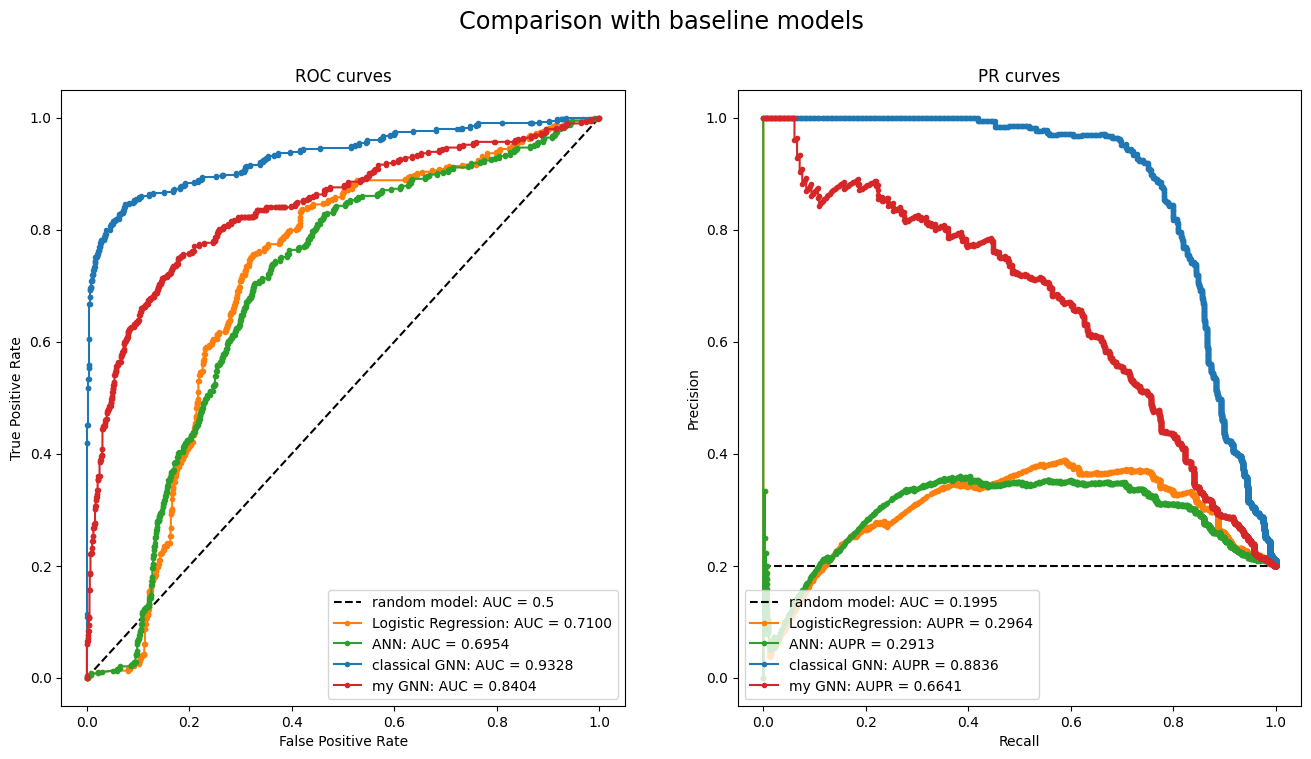

In [53]:
# target
targets = nodes.loc[nodes[nodes['mask']=='test'].index, 'y'].values
# preds
lr_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'lr_pred'].values
ann_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'ANN_pred'].values
gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'classical_GNN_pred'].values
my_gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'my_GNN_pred'].values

## curves
# random model
random_preds = [0 for _ in range(len(targets))]
random_auroc = roc_auc_score(targets, random_preds)
random_fpr, random_tpr, _ = roc_curve(targets, random_preds)   # ROC curves
no_skill_test = len(targets[targets == 1])/len(targets)             # PR curves
# LogisticRegression
lr_auroc = roc_auc_score(targets, lr_preds)
lr_fpr, lr_tpr, _ = roc_curve(targets, lr_preds)
lr_aupr = average_precision_score(targets, lr_preds)
lr_precision, lr_recall, _ = precision_recall_curve(targets, lr_preds)
# ANN
ann_auroc = roc_auc_score(targets, ann_preds)
ann_fpr, ann_tpr, _ = roc_curve(targets, ann_preds)
ann_aupr = average_precision_score(targets, ann_preds)
ann_precision, ann_recall, _ = precision_recall_curve(targets, ann_preds)
# classical_GNN
gnn_auroc = roc_auc_score(targets, gnn_preds)
gnn_fpr, gnn_tpr, _ = roc_curve(targets, gnn_preds)
gnn_aupr = average_precision_score(targets, gnn_preds)
gnn_precision, gnn_recall, _ = precision_recall_curve(targets, gnn_preds)
# my_GNN
my_gnn_auroc = roc_auc_score(targets, my_gnn_preds)
my_gnn_fpr, my_gnn_tpr, _ = roc_curve(targets, my_gnn_preds)
my_gnn_aupr = average_precision_score(targets, my_gnn_preds)
my_gnn_precision, my_gnn_recall, _ = precision_recall_curve(targets, my_gnn_preds)

# fig = plt.figure(figsize = (18, 9), constrained_layout = True)
# 
# # create 1 horizontal subfigures
# subfigs = fig.subfigures(1, 1)
# # create 2 vertical sub-sub-figure for each sub-figure
# ax_roc, ax_pr= subfigs[0].subplots(1, 2)

fig, (ax_roc, ax_pr) = plt.subplots(1,2, figsize = (16,8))#, constrained_layout=True)

fig.suptitle("Comparison with baseline models", fontsize = 'xx-large')

## do the first plot: AUROC
ax_roc.plot(random_fpr, random_tpr, linestyle='--', label=f'random model: AUC = {random_auroc}', color = 'black')
ax_roc.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic Regression: AUC = {lr_auroc:0.4f}', color = 'tab:orange') #'#ff7f0e'
ax_roc.plot(ann_fpr, ann_tpr, marker='.', label=f'ANN: AUC = {ann_auroc:0.4f}', color = 'tab:green')
ax_roc.plot(gnn_fpr, gnn_tpr, marker='.', label=f'classical GNN: AUC = {gnn_auroc:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_roc.plot(my_gnn_fpr, my_gnn_tpr, marker='.', label=f'my GNN: AUC = {my_gnn_auroc:0.4f}', color = 'tab:red') # 
# axis labels
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc = 'lower right')
ax_roc.set_title("ROC curves")
## do the second plot: AUPR
ax_pr.plot([0, 1], [no_skill_test, no_skill_test], linestyle='--', label=f'random model: AUC = {no_skill_test:0.4f}', color = 'black')
ax_pr.plot([0, 1], [0, 0], linestyle='--', label = None, color = 'purple', alpha = 0) # juste pour avoir la même échelle, tracer une ligne invisible, y = 0
ax_pr.plot(lr_recall, lr_precision, marker='.', label=f'LogisticRegression: AUPR = {lr_aupr:0.4f}', color = 'tab:orange') # '#ff7f0e'
ax_pr.plot(ann_recall, ann_precision, marker='.', label=f'ANN: AUPR = {ann_aupr:0.4f}', color = 'tab:green')
ax_pr.plot(gnn_recall, gnn_precision, marker='.', label=f'classical GNN: AUPR = {gnn_aupr:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_pr.plot(my_gnn_recall, my_gnn_precision, marker = '.', label=f'my GNN: AUPR = {my_gnn_aupr:0.4f}', color = 'tab:red') # '#1f77b4'
# axis labels
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc = 'lower left')
ax_pr.set_title("PR curves")

In [54]:
path = current_path + '/results/yeasts/baseline/'
fig_name = '20251010_yeasts_ML_ANN_GNN_split_seed_1_baseline_comparison.png'
fig.savefig(path_to_save+fig_name)

## metapath2vec

In [2]:
## specific script

In [49]:
# new_test_mask = data['GENE'].val_mask
# new_train_mask = data['GENE'].train_mask + data['GENE'].test_mask

# del data['GENE'].val_mask
# data['GENE'].train_mask = new_train_mask
# data['GENE'].test_mask = new_test_mask

In [12]:
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
data['GENE'].num_nodes = len(data['GENE'].x)
data['GENE'].y_index = torch.from_numpy(pd.RangeIndex(len(data['GENE'].x)).values)

In [13]:
from typing import Dict, List, Optional, Tuple

import torch
from torch import Tensor
from torch.nn import Embedding
from torch.utils.data import DataLoader

from torch_geometric.typing import EdgeType, NodeType, OptTensor
from torch_geometric.utils import sort_edge_index
from torch_geometric.utils.sparse import index2ptr

EPS = 1e-15


class my_MetaPath2Vec(torch.nn.Module):
    r"""The MetaPath2Vec model from the `"metapath2vec: Scalable Representation
    Learning for Heterogeneous Networks"
    <https://ericdongyx.github.io/papers/
    KDD17-dong-chawla-swami-metapath2vec.pdf>`_ paper where random walks based
    on a given :obj:`metapath` are sampled in a heterogeneous graph, and node
    embeddings are learned via negative sampling optimization.

    .. note::

        For an example of using MetaPath2Vec, see
        `examples/hetero/metapath2vec.py
        <https://github.com/pyg-team/pytorch_geometric/blob/master/examples/
        hetero/metapath2vec.py>`_.

    Args:
        edge_index_dict (Dict[Tuple[str, str, str], torch.Tensor]): Dictionary
            holding edge indices for each
            :obj:`(src_node_type, rel_type, dst_node_type)` edge type present
            in the heterogeneous graph.
        embedding_dim (int): The size of each embedding vector.
        metapath (List[Tuple[str, str, str]]): The metapath described as a list
            of :obj:`(src_node_type, rel_type, dst_node_type)` tuples.
        walk_length (int): The walk length.
        context_size (int): The actual context size which is considered for
            positive samples. This parameter increases the effective sampling
            rate by reusing samples across different source nodes.
        walks_per_node (int, optional): The number of walks to sample for each
            node. (default: :obj:`1`)
        num_negative_samples (int, optional): The number of negative samples to
            use for each positive sample. (default: :obj:`1`)
        num_nodes_dict (Dict[str, int], optional): Dictionary holding the
            number of nodes for each node type. (default: :obj:`None`)
        sparse (bool, optional): If set to :obj:`True`, gradients w.r.t. to the
            weight matrix will be sparse. (default: :obj:`False`)
    """
    def __init__(
        self,
        edge_index_dict: Dict[EdgeType, Tensor],
        embedding_dim: int,
        metapath: List[EdgeType],
        walk_length: int,
        context_size: int,
        walks_per_node: int = 1,
        num_negative_samples: int = 1,
        num_nodes_dict: Optional[Dict[NodeType, int]] = None,
        sparse: bool = False,
    ):
        super().__init__()

        if num_nodes_dict is None:
            num_nodes_dict = {}
            for keys, edge_index in edge_index_dict.items():
                key = keys[0]
                N = int(edge_index[0].max() + 1)
                num_nodes_dict[key] = max(N, num_nodes_dict.get(key, N))

                key = keys[-1]
                N = int(edge_index[1].max() + 1)
                num_nodes_dict[key] = max(N, num_nodes_dict.get(key, N))

        self.rowptr_dict, self.col_dict, self.rowcount_dict = {}, {}, {}
        for keys, edge_index in edge_index_dict.items():
            sizes = (num_nodes_dict[keys[0]], num_nodes_dict[keys[-1]])
            row, col = sort_edge_index(edge_index, num_nodes=max(sizes)).cpu()
            rowptr = index2ptr(row, size=sizes[0])
            self.rowptr_dict[keys] = rowptr
            self.col_dict[keys] = col
            self.rowcount_dict[keys] = rowptr[1:] - rowptr[:-1]

        for edge_type1, edge_type2 in zip(metapath[:-1], metapath[1:]):
            if edge_type1[-1] != edge_type2[0]:
                raise ValueError(
                    "Found invalid metapath. Ensure that the destination node "
                    "type matches with the source node type across all "
                    "consecutive edge types.")

        assert walk_length + 1 >= context_size
        if walk_length > len(metapath) and metapath[0][0] != metapath[-1][-1]:
            raise AttributeError(
                "The 'walk_length' is longer than the given 'metapath', but "
                "the 'metapath' does not denote a cycle")

        self.embedding_dim = embedding_dim
        self.metapath = metapath
        self.walk_length = walk_length
        self.context_size = context_size
        self.walks_per_node = walks_per_node
        self.num_negative_samples = num_negative_samples
        self.num_nodes_dict = num_nodes_dict

        types = set([x[0] for x in metapath]) | set([x[-1] for x in metapath])
        types = sorted(list(types))

        count = 0
        self.start, self.end = {}, {}
        for key in types:
            self.start[key] = count
            count += num_nodes_dict[key]
            self.end[key] = count

        offset = [self.start[metapath[0][0]]]
        offset += [self.start[keys[-1]] for keys in metapath
                   ] * int((walk_length / len(metapath)) + 1)
        offset = offset[:walk_length + 1]
        assert len(offset) == walk_length + 1
        self.offset = torch.tensor(offset)

        # + 1 denotes a dummy node used to link to for isolated nodes.
        self.embedding = Embedding(count + 1, embedding_dim, sparse=sparse)
        self.dummy_idx = count

        self.reset_parameters()

    def reset_parameters(self):
        r"""Resets all learnable parameters of the module."""
        self.embedding.reset_parameters()

    def forward(self, node_type: str, batch: OptTensor = None) -> Tensor:
        r"""Returns the embeddings for the nodes in :obj:`batch` of type
        :obj:`node_type`.
        """
        emb = self.embedding.weight[self.start[node_type]:self.end[node_type]]
        return emb if batch is None else emb.index_select(0, batch)

    def loader(self, **kwargs):
        r"""Returns the data loader that creates both positive and negative
        random walks on the heterogeneous graph.

        Args:
            **kwargs (optional): Arguments of
                :class:`torch.utils.data.DataLoader`, such as
                :obj:`batch_size`, :obj:`shuffle`, :obj:`drop_last` or
                :obj:`num_workers`.
        """
        return DataLoader(range(self.num_nodes_dict[self.metapath[0][0]]),
                          collate_fn=self._sample, **kwargs)

    def _pos_sample(self, batch: Tensor) -> Tensor:
        batch = batch.repeat(self.walks_per_node)

        rws = [batch]
        for i in range(self.walk_length):
            edge_type = self.metapath[i % len(self.metapath)]
            batch = sample(
                self.rowptr_dict[edge_type],
                self.col_dict[edge_type],
                self.rowcount_dict[edge_type],
                batch,
                num_neighbors=1,
                dummy_idx=self.dummy_idx,
            ).view(-1)
            rws.append(batch)

        rw = torch.stack(rws, dim=-1)
        rw.add_(self.offset.view(1, -1))
        rw[rw > self.dummy_idx] = self.dummy_idx

        walks = []
        num_walks_per_rw = 1 + self.walk_length + 1 - self.context_size
        for j in range(num_walks_per_rw):
            walks.append(rw[:, j:j + self.context_size])
        return torch.cat(walks, dim=0)

    def _neg_sample(self, batch: Tensor) -> Tensor:
        batch = batch.repeat(self.walks_per_node * self.num_negative_samples)

        rws = [batch]
        for i in range(self.walk_length):
            keys = self.metapath[i % len(self.metapath)]
            batch = torch.randint(0, self.num_nodes_dict[keys[-1]],
                                  (batch.size(0), ), dtype=torch.long)
            rws.append(batch)

        rw = torch.stack(rws, dim=-1)
        rw.add_(self.offset.view(1, -1))

        walks = []
        num_walks_per_rw = 1 + self.walk_length + 1 - self.context_size
        for j in range(num_walks_per_rw):
            walks.append(rw[:, j:j + self.context_size])
        return torch.cat(walks, dim=0)

    def _sample(self, batch: List[int]) -> Tuple[Tensor, Tensor]:
        if not isinstance(batch, Tensor):
            batch = torch.tensor(batch, dtype=torch.long)
        return self._pos_sample(batch), self._neg_sample(batch)

    def loss(self, pos_rw: Tensor, neg_rw: Tensor) -> Tensor:
        r"""Computes the loss given positive and negative random walks."""
        # Positive loss.
        start, rest = pos_rw[:, 0], pos_rw[:, 1:].contiguous()

        h_start = self.embedding(start).view(pos_rw.size(0), 1,
                                             self.embedding_dim)
        h_rest = self.embedding(rest.view(-1)).view(pos_rw.size(0), -1,
                                                    self.embedding_dim)

        out = (h_start * h_rest).sum(dim=-1).view(-1)
        pos_loss = -torch.log(torch.sigmoid(out) + EPS).mean()

        # Negative loss.
        start, rest = neg_rw[:, 0], neg_rw[:, 1:].contiguous()

        h_start = self.embedding(start).view(neg_rw.size(0), 1,
                                             self.embedding_dim)
        h_rest = self.embedding(rest.view(-1)).view(neg_rw.size(0), -1,
                                                    self.embedding_dim)

        out = (h_start * h_rest).sum(dim=-1).view(-1)
        neg_loss = -torch.log(1 - torch.sigmoid(out) + EPS).mean()

        return pos_loss + neg_loss

    def test(self, train_z: Tensor, train_y: Tensor, test_z: Tensor,
             test_y: Tensor, solver: str = "lbfgs", multi_class: str = "auto",
             *args, **kwargs) -> float:
        r"""Evaluates latent space quality via a logistic regression downstream
        task.
        """
        from sklearn.linear_model import LogisticRegression

        clf = LogisticRegression(solver=solver, multi_class=multi_class, *args,
                                 **kwargs).fit(train_z.detach().cpu().numpy(),
                                               train_y.detach().cpu().numpy())
        return (
            clf.score(test_z.detach().cpu().numpy(), test_y.detach().cpu().numpy()), 
            clf.predict_proba(train_z.detach().cpu().numpy()), 
            train_y.detach().cpu(),
            clf.predict_proba(test_z.detach().cpu().numpy()), 
            test_y.detach().cpu(),
            )

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}('
                f'{self.embedding.weight.size(0) - 1}, '
                f'{self.embedding.weight.size(1)})')


def sample(rowptr: Tensor, col: Tensor, rowcount: Tensor, subset: Tensor,
           num_neighbors: int, dummy_idx: int) -> Tensor:

    mask = subset >= dummy_idx
    subset = subset.clamp(min=0, max=rowptr.numel() - 2)
    count = rowcount[subset]

    rand = torch.rand((subset.size(0), num_neighbors), device=subset.device)
    rand *= count.to(rand.dtype).view(-1, 1)
    rand = rand.to(torch.long) + rowptr[subset].view(-1, 1)
    # based on the 2.6.1 release of pyg ? released on Sep. 26, 2024
    # https://github.com/pyg-team/pytorch_geometric/blob/master/torch_geometric/nn/models/metapath2vec.py
    rand = rand.clamp(max=col.numel() - 1)  # If last node is isolated.

    col = col[rand] if col.numel() > 0 else rand
    # col = col[rand-1] if col.numel() > 0 else rand
    col[mask | (count == 0)] = dummy_idx
    return col

In [14]:
from torch_geometric.nn import MetaPath2Vec

all_metapaths = [
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'paralog', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBG
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'biological_process', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBBBG
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCG
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'cellular_component', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCCCG
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE'), # GMMG
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'molecular_function', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE') # GMMMMG
]

In [15]:
data.num_nodes_dict

{'GENE': 6579, 'BP': 27995, 'CC': 4040, 'MF': 11297}

In [16]:
metapath_2 = [
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'paralog', 'GENE'),
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_BP', 'BP'), ('BP', 'biological_process', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBBBG
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_CC', 'CC'), ('CC', 'cellular_component', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCCCG
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE'), # GMMG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_MF', 'MF'), ('MF', 'molecular_function', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE') # GMMMMG
]

model = my_MetaPath2Vec(
    data.edge_index_dict, embedding_dim=64,
    metapath = metapath_2, walk_length = 100, context_size = 10,
    walks_per_node = 20, num_negative_samples = 5,
    num_nodes_dict = {'BP': 27995, 'CC': 4040, 'GENE': 6579, 'MF': 11297},
    sparse = True).to(device)

loader = model.loader(batch_size=64, shuffle=True, num_workers=6)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

def train(epoch, log_steps=100, eval_steps=2000):
    model.train()

    total_loss = 0
    for i, (pos_rw, neg_rw) in enumerate(loader):
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (i + 1) % log_steps == 0:
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Loss: {total_loss / log_steps:.4f}')
            total_loss = 0

        if (i + 1) % eval_steps == 0:
            acc = test()
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Acc: {acc:.4f}')


@torch.no_grad()
def test(train_ratio=0.1):
    model.eval()

    z = model('GENE', batch=data['GENE'].y_index.to(device))
    y = data['GENE'].y

    perm = torch.randperm(z.size(0))
    # train_perm = perm[:int(z.size(0) * train_ratio)]
    # test_perm = perm[int(z.size(0) * train_ratio):]
    train_perm = data['GENE'].train_mask #perm[:int(z.size(0) * train_ratio)]
    test_perm = data['GENE'].test_mask # perm[int(z.size(0) * train_ratio):]

    return model.test(z[train_perm], y[train_perm], z[test_perm], y[test_perm],max_iter=150) 


for epoch in range(1, 8):
    train(epoch)
    acc, train_preds, train_targets, test_preds, test_targets = test()
    print(f'Epoch: {epoch}, Accuracy: {acc:.4f}')

Epoch: 1, Step: 00100/103, Loss: 2.1243
Epoch: 1, Accuracy: 0.8004
Epoch: 2, Step: 00100/103, Loss: 0.9511
Epoch: 2, Accuracy: 0.7939


KeyboardInterrupt: 

In [33]:
acc, train_preds, train_targets, test_preds, test_targets = test()
print(roc_auc_score(train_targets, train_preds[:,1]))
print(roc_auc_score(test_targets, test_preds[:,1]))

0.7683657552011982
0.7654353717450217


### metapath_3

In [50]:
metapath_3 = [
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'paralog', 'GENE'),
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE'), # GMMG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_MF', 'MF'), ('MF', 'molecular_function', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE') # GMMMMG
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCG
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBG
    ('GENE', 'PPI', 'GENE'),
    # ('GENE', 'gene_to_BP', 'BP'), ('BP', 'biological_process', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBBBG

    # ('GENE', 'gene_to_CC', 'CC'), ('CC', 'cellular_component', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCCCG
]

model = my_MetaPath2Vec(
    data.edge_index_dict, embedding_dim=64,
    metapath = metapath_3, walk_length = 100, context_size = 10,
    walks_per_node = 20, num_negative_samples = 5,
    num_nodes_dict = {'BP': 27995, 'CC': 4040, 'GENE': 6579, 'MF': 11297},
    sparse = True).to(device)

loader = model.loader(batch_size=64, shuffle=True, num_workers=6)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

def train(epoch, log_steps=100, eval_steps=2000):
    model.train()

    total_loss = 0
    for i, (pos_rw, neg_rw) in enumerate(loader):
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (i + 1) % log_steps == 0:
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Loss: {total_loss / log_steps:.4f}')
            total_loss = 0

        if (i + 1) % eval_steps == 0:
            acc = test()
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Acc: {acc:.4f}')


@torch.no_grad()
def test(train_ratio=0.1):
    model.eval()

    z = model('GENE', batch=data['GENE'].y_index.to(device))
    y = data['GENE'].y

    perm = torch.randperm(z.size(0))
    # train_perm = perm[:int(z.size(0) * train_ratio)]
    # test_perm = perm[int(z.size(0) * train_ratio):]
    train_perm = data['GENE'].train_mask #perm[:int(z.size(0) * train_ratio)]
    test_perm = data['GENE'].test_mask # perm[int(z.size(0) * train_ratio):]

    return model.test(z[train_perm], y[train_perm], z[test_perm], y[test_perm],max_iter=150) 


for epoch in range(1, 8):
    train(epoch)
    acc, train_preds, train_targets, test_preds, test_targets = test()
    print(f'Epoch: {epoch}, Accuracy: {acc:.4f}')

Epoch: 1, Step: 00100/103, Loss: 2.1310
Epoch: 1, Accuracy: 0.8005
Epoch: 2, Step: 00100/103, Loss: 0.9527
Epoch: 2, Accuracy: 0.7949
Epoch: 3, Step: 00100/103, Loss: 0.7766
Epoch: 3, Accuracy: 0.7959
Epoch: 4, Step: 00100/103, Loss: 0.7224
Epoch: 4, Accuracy: 0.8005
Epoch: 5, Step: 00100/103, Loss: 0.6691
Epoch: 5, Accuracy: 0.8061
Epoch: 6, Step: 00100/103, Loss: 0.6223
Epoch: 6, Accuracy: 0.8051
Epoch: 7, Step: 00100/103, Loss: 0.5857
Epoch: 7, Accuracy: 0.8122


In [51]:
acc, train_preds, train_targets, test_preds, test_targets = test()
print(roc_auc_score(train_targets, train_preds[:,1]))
print(roc_auc_score(test_targets, test_preds[:,1]))

0.78362480216529
0.7522434878650985


In [52]:
train_df = pd.DataFrame(np.concatenate([train_preds[:,1].reshape(-1,1), train_targets.reshape(-1,1)], axis=1), columns = ['pred', 'target'])
test_df = pd.DataFrame(np.concatenate([test_preds[:,1].reshape(-1,1), test_targets.reshape(-1,1)], axis=1), columns = ['pred', 'target'])

In [53]:
path_to_save = '/data-tmp/rnicolle/'
df_name = '20251010_yeasts_ML_ANN_GNN_split_seed_1.tsv'
nodes = pd.read_csv(path_to_save+df_name, header=0, sep='\t')

In [54]:
train_preds.shape

(4604, 2)

In [55]:
train_idx = nodes[nodes['mask'].isin(['train', 'val'])].index
test_idx = nodes[nodes['mask']=='test'].index

print(sum(nodes.loc[train_idx,'y'] == train_targets.detach().cpu().numpy().astype(int)))
print(sum(nodes.loc[test_idx,'y'] == test_targets.detach().cpu().numpy().astype(int)))

nodes.loc[train_idx,['metapath_pred']] = train_preds[:,1]
nodes.loc[test_idx,['metapath_pred']] = test_preds[:,1]

4604
1975


Text(0.5, 1.0, 'PR curves')

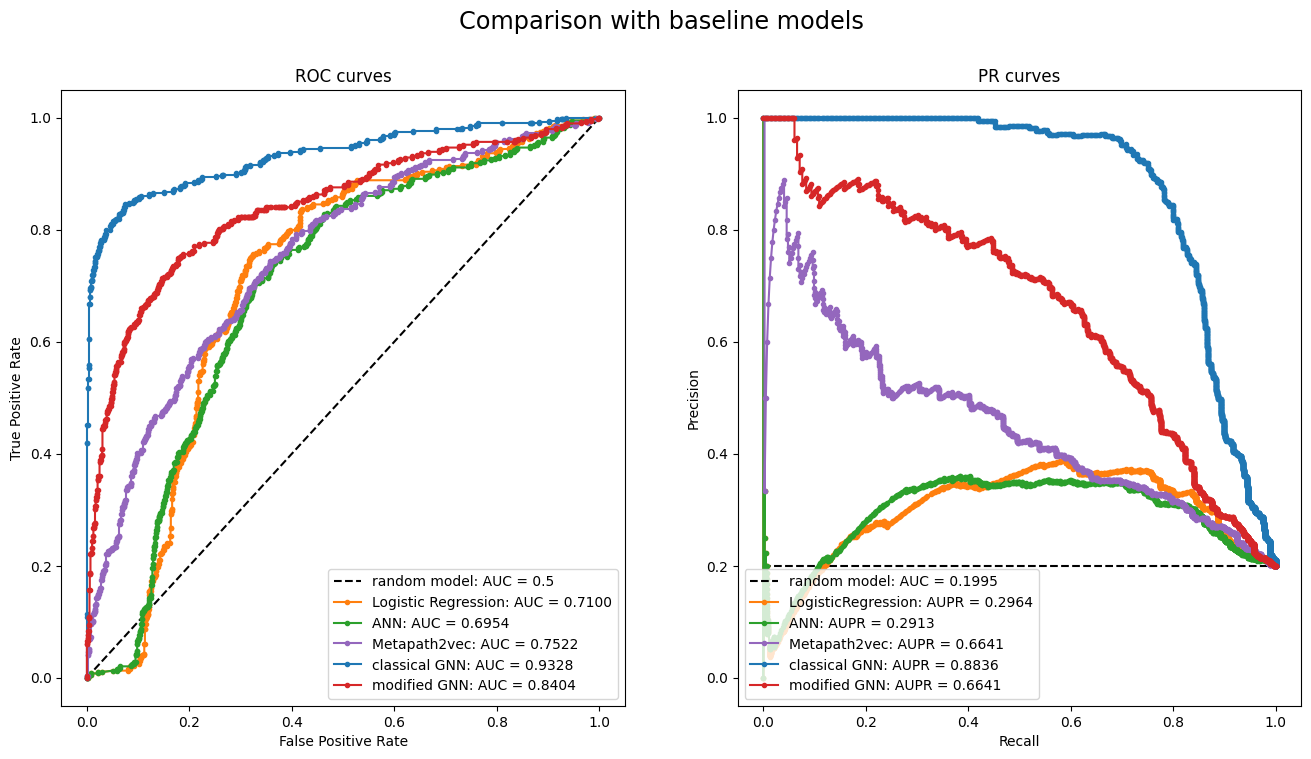

In [56]:
# target
targets = nodes.loc[nodes[nodes['mask']=='test'].index, 'y'].values
# preds
lr_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'lr_pred'].values
ann_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'ANN_pred'].values
gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'classical_GNN_pred'].values
my_gnn_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'my_GNN_pred'].values
metapath2vec_preds = nodes.loc[nodes[nodes['mask']=='test'].index, 'metapath_pred'].values

## curves
# random model
random_preds = [0 for _ in range(len(targets))]
random_auroc = roc_auc_score(targets, random_preds)
random_fpr, random_tpr, _ = roc_curve(targets, random_preds)   # ROC curves
no_skill_test = len(targets[targets == 1])/len(targets)             # PR curves
# LogisticRegression
lr_auroc = roc_auc_score(targets, lr_preds)
lr_fpr, lr_tpr, _ = roc_curve(targets, lr_preds)
lr_aupr = average_precision_score(targets, lr_preds)
lr_precision, lr_recall, _ = precision_recall_curve(targets, lr_preds)
# ANN
ann_auroc = roc_auc_score(targets, ann_preds)
ann_fpr, ann_tpr, _ = roc_curve(targets, ann_preds)
ann_aupr = average_precision_score(targets, ann_preds)
ann_precision, ann_recall, _ = precision_recall_curve(targets, ann_preds)
# classical_GNN
gnn_auroc = roc_auc_score(targets, gnn_preds)
gnn_fpr, gnn_tpr, _ = roc_curve(targets, gnn_preds)
gnn_aupr = average_precision_score(targets, gnn_preds)
gnn_precision, gnn_recall, _ = precision_recall_curve(targets, gnn_preds)
# my_GNN
my_gnn_auroc = roc_auc_score(targets, my_gnn_preds)
my_gnn_fpr, my_gnn_tpr, _ = roc_curve(targets, my_gnn_preds)
my_gnn_aupr = average_precision_score(targets, my_gnn_preds)
my_gnn_precision, my_gnn_recall, _ = precision_recall_curve(targets, my_gnn_preds)
# metapath2vec
metapath2vec_auroc = roc_auc_score(targets, metapath2vec_preds)
metapath2vec_fpr, metapath2vec_tpr, _ = roc_curve(targets, metapath2vec_preds)
metapath2vec_aupr = average_precision_score(targets, metapath2vec_preds)
metapath2vec_precision, metapath2vec_recall, _ = precision_recall_curve(targets, metapath2vec_preds)

# fig = plt.figure(figsize = (18, 9), constrained_layout = True)
# 
# # create 1 horizontal subfigures
# subfigs = fig.subfigures(1, 1)
# # create 2 vertical sub-sub-figure for each sub-figure
# ax_roc, ax_pr= subfigs[0].subplots(1, 2)

fig, (ax_roc, ax_pr) = plt.subplots(1,2, figsize = (16,8))#, constrained_layout=True)

fig.suptitle("Comparison with baseline models", fontsize = 'xx-large')

## do the first plot: AUROC
ax_roc.plot(random_fpr, random_tpr, linestyle='--', label=f'random model: AUC = {random_auroc}', color = 'black')
ax_roc.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic Regression: AUC = {lr_auroc:0.4f}', color = 'tab:orange') #'#ff7f0e'
ax_roc.plot(ann_fpr, ann_tpr, marker='.', label=f'ANN: AUC = {ann_auroc:0.4f}', color = 'tab:green')
ax_roc.plot(metapath2vec_fpr, metapath2vec_tpr, marker='.', label=f'Metapath2vec: AUC = {metapath2vec_auroc:0.4f}', color = 'tab:purple') # 
ax_roc.plot(gnn_fpr, gnn_tpr, marker='.', label=f'classical GNN: AUC = {gnn_auroc:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_roc.plot(my_gnn_fpr, my_gnn_tpr, marker='.', label=f'modified GNN: AUC = {my_gnn_auroc:0.4f}', color = 'tab:red') # 

# axis labels
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc = 'lower right')
ax_roc.set_title("ROC curves")
## do the second plot: AUPR
ax_pr.plot([0, 1], [no_skill_test, no_skill_test], linestyle='--', label=f'random model: AUC = {no_skill_test:0.4f}', color = 'black')
ax_pr.plot([0, 1], [0, 0], linestyle='--', label = None, color = 'purple', alpha = 0) # juste pour avoir la même échelle, tracer une ligne invisible, y = 0
ax_pr.plot(lr_recall, lr_precision, marker='.', label=f'LogisticRegression: AUPR = {lr_aupr:0.4f}', color = 'tab:orange') # '#ff7f0e'
ax_pr.plot(ann_recall, ann_precision, marker='.', label=f'ANN: AUPR = {ann_aupr:0.4f}', color = 'tab:green')
ax_pr.plot(metapath2vec_recall, metapath2vec_precision, marker = '.', label=f'Metapath2vec: AUPR = {my_gnn_aupr:0.4f}', color = 'tab:purple') # '#1f77b4'
ax_pr.plot(gnn_recall, gnn_precision, marker='.', label=f'classical GNN: AUPR = {gnn_aupr:0.4f}', color = 'tab:blue') # '#1f77b4'
ax_pr.plot(my_gnn_recall, my_gnn_precision, marker = '.', label=f'modified GNN: AUPR = {my_gnn_aupr:0.4f}', color = 'tab:red') # '#1f77b4'

# axis labels
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc = 'lower left')
ax_pr.set_title("PR curves")

In [57]:
path = current_path + '/results/yeasts/baseline/'
fig_name = '20251010_yeasts_ML_ANN_M2V_GNN_split_seed_1_baseline_comparison.png'
fig.savefig(path_to_save+fig_name)

In [58]:
path = current_path + '/results/yeasts/baseline/'path_to_save = '/data-tmp/rnicolle/'
df_name = '20251010_yeasts_ML_ANN_M2V_GNN_split_seed_1.tsv'
nodes.to_csv(path_to_save+df_name, header=True, index=False, sep='\t')

## metapath_next

In [59]:
metapath_4 = [
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'paralog', 'GENE'),
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBG
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_BP', 'BP'), ('BP', 'biological_process', 'BP'), ('BP', 'rev_gene_to_BP', 'GENE'), # GBBBBG
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCG
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_CC', 'CC'), ('CC', 'cellular_component', 'CC'), ('CC', 'rev_gene_to_CC', 'GENE'), # GCCCCG
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE'), # GMMG
    ('GENE', 'PPI', 'GENE'),
    ('GENE', 'gene_to_MF', 'MF'), ('MF', 'molecular_function', 'MF'), ('MF', 'rev_gene_to_MF', 'GENE') # GMMMMG
]

model = my_MetaPath2Vec(
    data.edge_index_dict, embedding_dim=64,
    metapath = metapath_4, walk_length = 100, context_size = 10,
    walks_per_node = 20, num_negative_samples = 5,
    num_nodes_dict = {'BP': 27995, 'CC': 4040, 'GENE': 6579, 'MF': 11297},
    sparse = True).to(device)

loader = model.loader(batch_size=64, shuffle=True, num_workers=6)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

def train(epoch, log_steps=100, eval_steps=2000):
    model.train()

    total_loss = 0
    for i, (pos_rw, neg_rw) in enumerate(loader):
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (i + 1) % log_steps == 0:
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Loss: {total_loss / log_steps:.4f}')
            total_loss = 0

        if (i + 1) % eval_steps == 0:
            acc = test()
            print(f'Epoch: {epoch}, Step: {i + 1:05d}/{len(loader)}, '
                  f'Acc: {acc:.4f}')


@torch.no_grad()
def test(train_ratio=0.1):
    model.eval()

    z = model('GENE', batch=data['GENE'].y_index.to(device))
    y = data['GENE'].y

    perm = torch.randperm(z.size(0))
    # train_perm = perm[:int(z.size(0) * train_ratio)]
    # test_perm = perm[int(z.size(0) * train_ratio):]
    train_perm = data['GENE'].train_mask #perm[:int(z.size(0) * train_ratio)]
    test_perm = data['GENE'].test_mask # perm[int(z.size(0) * train_ratio):]

    return model.test(z[train_perm], y[train_perm], z[test_perm], y[test_perm],max_iter=150) 


for epoch in range(1, 8):
    train(epoch)
    acc, train_preds, train_targets, test_preds, test_targets = test()
    print(f'Epoch: {epoch}, Accuracy: {acc:.4f}')

Epoch: 1, Step: 00100/103, Loss: 2.1102
Epoch: 1, Accuracy: 0.8000
Epoch: 2, Step: 00100/103, Loss: 0.9440
Epoch: 2, Accuracy: 0.7990
Epoch: 3, Step: 00100/103, Loss: 0.7649
Epoch: 3, Accuracy: 0.8000
Epoch: 4, Step: 00100/103, Loss: 0.7272
Epoch: 4, Accuracy: 0.7990
Epoch: 5, Step: 00100/103, Loss: 0.7151
Epoch: 5, Accuracy: 0.8046
Epoch: 6, Step: 00100/103, Loss: 0.7100
Epoch: 6, Accuracy: 0.8056
Epoch: 7, Step: 00100/103, Loss: 0.7071
Epoch: 7, Accuracy: 0.8086


In [61]:
acc, train_preds, train_targets, test_preds, test_targets = test()
print(roc_auc_score(train_targets, train_preds[:,1]))
print(roc_auc_score(test_targets, test_preds[:,1]))

0.7455689609429695
0.7366329862549243


# Yeasts_cross_val best

In [87]:
path = current_path + '/results/yeasts/baseline/'
name = 'yeasts_n2n_inner_cross_validation_results.tsv'
df = pd.read_csv(path+name, header=0, sep='\t')

df = df[df['parameters'].str.contains('mean')]

In [ ]:
my_dict = {}

final_df = pd.DataFrame()

# best model accrding to AUROC

for i in range(1,31):
    tmp_df = df[df['split_seed']==i]
    tmp_df = tmp_df.reset_index(drop=True)
    best_auroc = tmp_df['AUROC_test'].max()
    best_aupr = tmp_df['AUPR_test'].max()
    best_param = tmp_df[tmp_df['AUROC_test'] == best_auroc]['parameters'].iloc[0].split('mean_')[1]
    print(f"for split_seed: {i}, best_params: {best_param}")
    my_dict[i] = best_param
    df_tmp = pd.DataFrame(data = {'AUROC_test': best_auroc, 'AUPR_test': best_aupr, 'split_seed': i, 'parameters':best_param}, index=[i]) 
    if final_df.shape[0] == 0:
        final_df = df_tmp.copy()
    else:
        final_df = pd.concat([final_df, df_tmp], axis=0)

for split_seed: 1, best_params: relu_16
for split_seed: 2, best_params: relu_64
for split_seed: 3, best_params: relu_32
for split_seed: 4, best_params: relu_32
for split_seed: 5, best_params: relu_16
for split_seed: 6, best_params: relu_32
for split_seed: 7, best_params: relu_64
for split_seed: 8, best_params: relu_32
for split_seed: 9, best_params: relu_16
for split_seed: 10, best_params: relu_64
for split_seed: 11, best_params: relu_64
for split_seed: 12, best_params: relu_16
for split_seed: 13, best_params: relu_32
for split_seed: 14, best_params: relu_64
for split_seed: 15, best_params: relu_16
for split_seed: 16, best_params: relu_64
for split_seed: 17, best_params: relu_64
for split_seed: 18, best_params: relu_64
for split_seed: 19, best_params: relu_32
for split_seed: 20, best_params: relu_32
for split_seed: 21, best_params: relu_64
for split_seed: 22, best_params: tanh_16
for split_seed: 23, best_params: relu_32
for split_seed: 24, best_params: relu_64
for split_seed: 25, best_

In [89]:
my_dict

{1: 'relu_16',
 2: 'relu_64',
 3: 'relu_32',
 4: 'relu_32',
 5: 'relu_16',
 6: 'relu_32',
 7: 'relu_64',
 8: 'relu_32',
 9: 'relu_16',
 10: 'relu_64',
 11: 'relu_64',
 12: 'relu_16',
 13: 'relu_32',
 14: 'relu_64',
 15: 'relu_16',
 16: 'relu_64',
 17: 'relu_64',
 18: 'relu_64',
 19: 'relu_32',
 20: 'relu_32',
 21: 'relu_64',
 22: 'tanh_16',
 23: 'relu_32',
 24: 'relu_64',
 25: 'relu_32',
 26: 'relu_64',
 27: 'relu_64',
 28: 'relu_32',
 29: 'relu_32',
 30: 'relu_64'}

In [91]:
path = current_path + '/results/yeasts/baseline/'
df_name = "yeasts_cross_val_best_params.tsv"
final_df.to_csv(path+df_name, header=0, mode='x')

In [96]:
print(final_df['AUROC_test'].mean())
print(final_df['AUROC_test'].std())
print(final_df['AUPR_test'].mean())
print(final_df['AUPR_test'].std())

# 0.8595187556027297
# 0.005752432978408333
# 0.692372196203417
# 0.009011269949853084

0.8595187556027297
0.005752432978408333
0.692372196203417
0.009011269949853084
